In [ ]:
# This will be very clean and neat with saved figures for all relevant plots

In [177]:
# Import necessary libraries
import marimo as mo
import pandas as pd
import numpy as np
import os
import ast

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, confusion_matrix, classification_report, r2_score
from sklearn.model_selection import cross_val_score

from scipy.stats import f

from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Concatenate

import seaborn as sns
import matplotlib.pyplot as plt


import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt


# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt



In [120]:
# Begin by importing raw data
load_path = 'data/slf/mayer2022/df_raw_weak_layers_exist.csv'

# Load the DataFrame from the CSV file as df_raw
df_raw = pd.read_csv(load_path)

In [121]:
# Second data file has the coupled criterion applied to all data points
# Define the path to the saved files
load_path_2 = 'data/analysed_layers/'

# Load the DataFrames from the CSV files - the updated version
df_analysed = pd.read_csv(load_path_2 + 'applying_criterion_ALL_rows_vZ.csv')

In [99]:
# Method to ensure we evaluate all inputs as python lists
def safely_convert_to_list_and_float(x):
    if isinstance(x, str):
        try: 
            # Convert string to actual Python structure (list or tuple)
            x = ast.literal_eval(x)
        except (ValueError, SyntaxError):  # Handle both ValueError and SyntaxError
            return np.nan  # If there's an error, return NaN
    # If it's a list, process each item
    if isinstance(x, list):
        return [
            tuple(float(i) for i in tup) if isinstance(tup, tuple) else float(tup) 
            for tup in x
        ]
    # If it's a tuple, convert its elements to floats
    if isinstance(x, tuple):
        return tuple(float(i) for i in x)
    # If it's a single value, convert to float, handling NaN
    return float(x) if x is not None and x != 'nan' else np.nan

In [122]:
# Applying method to both dataframes
df_raw = df_raw.applymap(safely_convert_to_list_and_float)
df_analysed = df_analysed.applymap(safely_convert_to_list_and_float)

In [15]:
# Having importent all relevant datasets, we now proceed to try and model the data

# The methods follow the following logic

### Using all raw_data, without padding as zeros ###

# 1: Use snow_profiles to predict RB_score

In [101]:
# For this forst step of modelling, the saved path for all plots is:

os.makedirs(output_dir, exist_ok=True)
output_dir = os.path.join(os.getcwd(), "CN_thesis_plots", "1_raw_padded")

Root Mean Squared Error: 1.5811255477807287
R^2: 0.036831250830300366


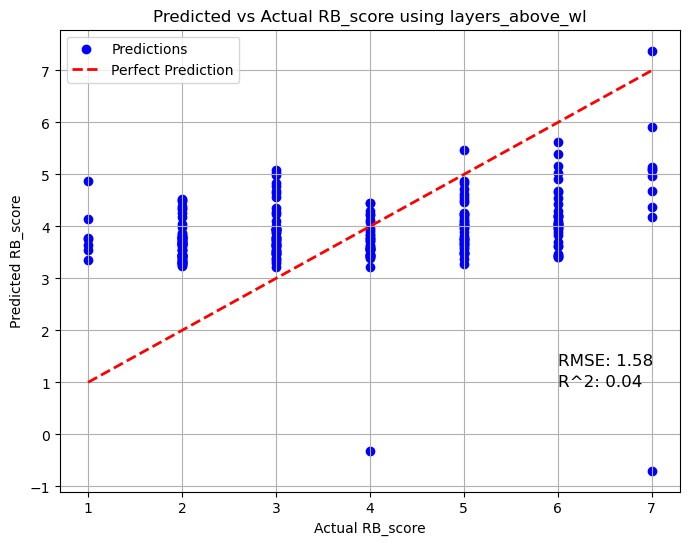

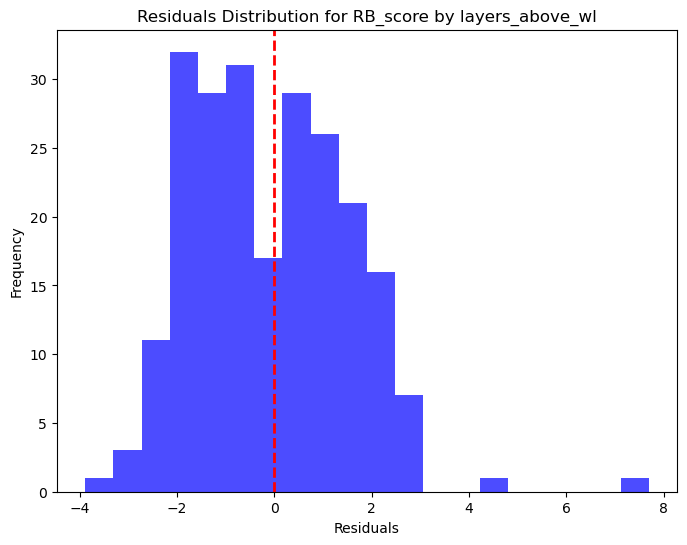

In [184]:
# Variable names for inclusion in filenames and plot titles
predictor_var = "layers_above_wl"
target_var = "RB_score"

# Step 1: Data Preparation
max_length = max(len(lst) for lst in df_raw[predictor_var])  # Find the maximum length of lists in 'layers_above_wl'
X = np.array([lst + [0] * (max_length - len(lst)) for lst in df_raw[predictor_var]])  # Pad lists with zeros to match max length

y = df_raw[target_var].values  # Target variable

# Step 2: Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=36)

# Step 3: Build and Train the Model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 4: Predict on Test Data
y_pred = model.predict(X_test)

# Step 5: Evaluate the Model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f'Root Mean Squared Error: {rmse}')
print(f'R^2: {r2}')

# Step 6: Plot Predicted vs Actual Values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, c='blue', marker='o', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title(f'Predicted vs Actual {target_var} using {predictor_var}')
plt.xlabel(f'Actual {target_var}')
plt.ylabel(f'Predicted {target_var}')
plt.legend()
plt.grid(True)

# Calculate annotation position
x_pos = y_test.min() + (5 / 6) * (y_test.max() - y_test.min())
y_pos = y_pred.min() + (1 / 4) * (y_pred.max() - y_pred.min())

# Annotate RMSE and R^2 on the plot in lower right corner
plt.text(x_pos, y_pos, f'RMSE: {rmse:.2f}', fontsize=12, color='black')
plt.text(x_pos, y_pos - (y_pred.max() - y_pred.min()) * 0.05, f'R^2: {r2:.2f}', fontsize=12, color='black')

# Save the plot with a descriptive name
plt.savefig(os.path.join(output_dir, f"predicted_vs_actual_{target_var}_by_{predictor_var}.png"))
plt.show()

# Step 7: Residual Plot
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=20, alpha=0.7, color='blue')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title(f'Residuals Distribution for {target_var} by {predictor_var}')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

# Save the residual plot with a descriptive name
plt.savefig(os.path.join(output_dir, f"residuals_distribution_{target_var}_by_{predictor_var}.png"))
plt.show()

Root Mean Squared Error: 1.737023551398477
R^2: -0.16246820903325343


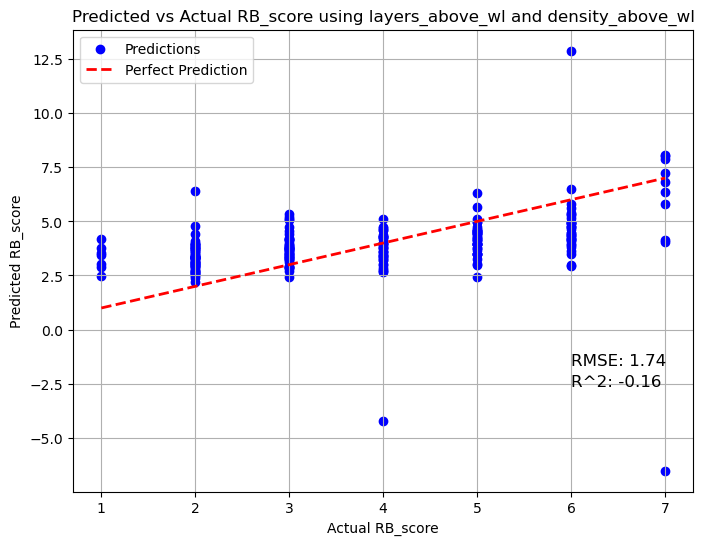

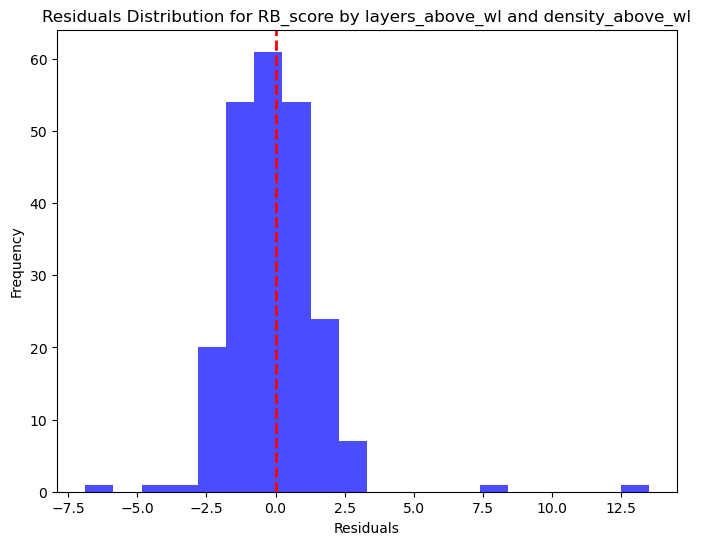

In [192]:
# Variable names for inclusion in filenames and plot titles
predictor_var_1 = "layers_above_wl"
predictor_var_2 = "density_above_wl"
target_var = "RB_score"

# Step 1: Data Preparation
# Ensure all entries in 'layers_above_wl' and 'density_above_wl' have the same length by padding shorter lists with zeros.
max_length_1 = max(len(lst) for lst in df_raw[predictor_var_1])  # Max length of lists in 'layers_above_wl'
max_length_2 = max(len(lst) for lst in df_raw[predictor_var_2])  # Max length of lists in 'density_above_wl'
max_length = max(max_length_1, max_length_2)  # Use the greater max length for padding

# Pad both predictors to the same length and stack them
X1 = np.array([lst + [0] * (max_length - len(lst)) for lst in df_raw[predictor_var_1]])
X2 = np.array([lst + [0] * (max_length - len(lst)) for lst in df_raw[predictor_var_2]])
X = np.hstack((X1, X2))  # Concatenate the two padded predictors horizontally

y = df_raw[target_var].values  # Target variable

# Step 2: Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=36)

# Step 3: Build and Train the Model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 4: Predict on Test Data
y_pred = model.predict(X_test)

# Step 5: Evaluate the Model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f'Root Mean Squared Error: {rmse}')
print(f'R^2: {r2}')

# Step 6: Plot Predicted vs Actual Values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, c='blue', marker='o', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title(f'Predicted vs Actual {target_var} using {predictor_var_1} and {predictor_var_2}')
plt.xlabel(f'Actual {target_var}')
plt.ylabel(f'Predicted {target_var}')
plt.legend()
plt.grid(True)

# Calculate annotation position in lower right corner
x_pos = y_test.min() + (5 / 6) * (y_test.max() - y_test.min())
y_pos = y_pred.min() + (1 / 4) * (y_pred.max() - y_pred.min())

# Annotate RMSE and R^2 on the plot in lower right corner
plt.text(x_pos, y_pos, f'RMSE: {rmse:.2f}', fontsize=12, color='black')
plt.text(x_pos, y_pos - (y_pred.max() - y_pred.min()) * 0.05, f'R^2: {r2:.2f}', fontsize=12, color='black')

# Save the plot with a descriptive name
plt.savefig(os.path.join(output_dir, f"predicted_vs_actual_{target_var}_by_{predictor_var_1}_and_{predictor_var_2}.png"))
plt.show()

# Step 7: Residual Plot
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=20, alpha=0.7, color='blue')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title(f'Residuals Distribution for {target_var} by {predictor_var_1} and {predictor_var_2}')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

# Save the residual plot with a descriptive name
plt.savefig(os.path.join(output_dir, f"residuals_distribution_{target_var}_by_{predictor_var_1}_and_{predictor_var_2}.png"))
plt.show()

In [186]:
from sklearn.model_selection import cross_val_score
from scipy.stats import f

# Define predictor and target variables based on previous naming conventions
predictor_var_1 = "layers_above_wl"
predictor_var_2 = "density_above_wl"
target_var = "RB_score"

# Prepare the data for the original model (using only layers_above_wl)
X1 = np.array([lst + [0] * (max_length - len(lst)) for lst in df_raw[predictor_var_1]])
X1_train, X1_test, y_train, y_test = train_test_split(X1, df_raw[target_var].values, test_size=0.3, random_state=36)

# Fit the original model (only layers_above_wl)
model1 = LinearRegression().fit(X1_train, y_train)
y_pred1 = model1.predict(X1_test)
rss_original = np.sum((y_test - y_pred1) ** 2)  # Residual sum of squares for the original model

# Prepare the data for the new model (using layers_above_wl and density_above_wl)
max_length_1 = max(len(lst) for lst in df_raw[predictor_var_1])
max_length_2 = max(len(lst) for lst in df_raw[predictor_var_2])
max_length = max(max_length_1, max_length_2)  # Use the greater length for consistent padding

X2_1 = np.array([lst + [0] * (max_length - len(lst)) for lst in df_raw[predictor_var_1]])
X2_2 = np.array([lst + [0] * (max_length - len(lst)) for lst in df_raw[predictor_var_2]])
X2 = np.hstack((X2_1, X2_2))  # Concatenate the two padded predictors

# Train-test split for the new model
X_train, X_test, y_train, y_test = train_test_split(X2, df_raw[target_var].values, test_size=0.3, random_state=36)

# Fit the new model (layers_above_wl and density_above_wl)
model2 = LinearRegression().fit(X_train, y_train)
y_pred2 = model2.predict(X_test)
rss_new = np.sum((y_test - y_pred2) ** 2)  # Residual sum of squares for the new model

# Calculate F-statistic
p = X2.shape[1] - X1.shape[1]  # Number of additional predictors
n = len(y_test)                # Number of observations
k = X2.shape[1]                # Total number of predictors in the new model

f_stat = ((rss_original - rss_new) / p) / (rss_new / (n - k))
p_value = 1 - f.cdf(f_stat, p, n - k)
print(f'F-statistic: {f_stat}, p-value: {p_value}')

# Cross-validated RMSE for both models
cv_rmse_model1 = np.mean(np.sqrt(-cross_val_score(model1, X1, df_raw[target_var].values, scoring='neg_mean_squared_error', cv=10)))
cv_rmse_model2 = np.mean(np.sqrt(-cross_val_score(model2, X2, df_raw[target_var].values, scoring='neg_mean_squared_error', cv=10)))

print(f'Cross-validated RMSE for model with only {predictor_var_1}: {cv_rmse_model1}')
print(f'Cross-validated RMSE for model with {predictor_var_1} and {predictor_var_2}: {cv_rmse_model2}')


F-statistic: -1.6873805645823876, p-value: 1.0
Cross-validated RMSE for model with only layers_above_wl: 1.5281436402069635
Cross-validated RMSE for model with layers_above_wl and density_above_wl: 4.709939135598225


In [ ]:
## As the adding of density is not significant, we proceed to add slopeangle instead ###

F-statistic: -0.42600981614564964, p-value: 1.0
Cross-validated RMSE for model with only layers_above_wl: 1.5281436402069635
Cross-validated RMSE for model with layers_above_wl and slopeangle: 1.533537843118295


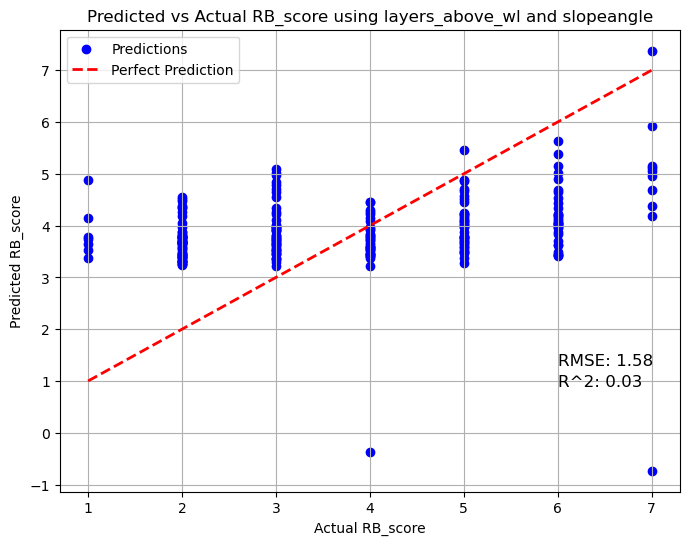

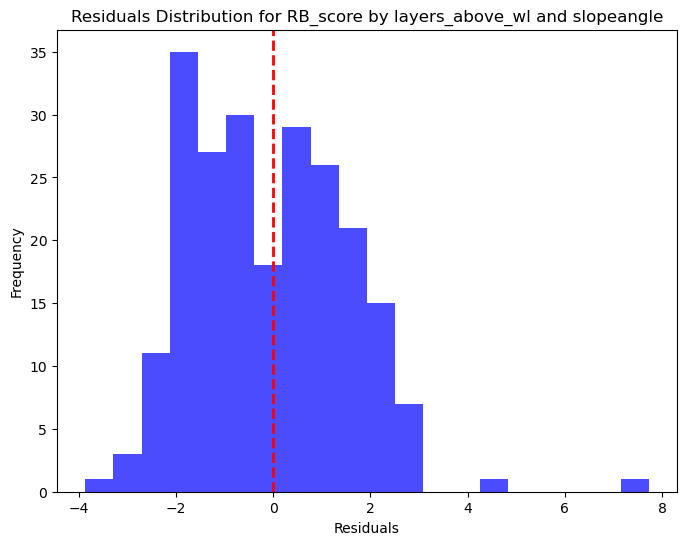

In [213]:
# Define predictor and target variables based on previous naming conventions
predictor_var_1 = "layers_above_wl"
predictor_var_2 = "slopeangle"  # Corrected predictor variable name
target_var = "RB_score"

# Prepare the data for the original model (using only layers_above_wl)
max_length = max(len(lst) for lst in df_raw[predictor_var_1])  # Determine maximum length for padding
X1 = np.array([lst + [0] * (max_length - len(lst)) for lst in df_raw[predictor_var_1]])
X1_train, X1_test, y_train, y_test = train_test_split(X1, df_raw[target_var].values, test_size=0.3, random_state=36)

# Fit the original model (only layers_above_wl)
model1 = LinearRegression().fit(X1_train, y_train)
y_pred1 = model1.predict(X1_test)
rss_original = np.sum((y_test - y_pred1) ** 2)  # Residual sum of squares for the original model

# Prepare the data for the new model (using layers_above_wl and slopeangle)
X2_1 = np.array([lst + [0] * (max_length - len(lst)) for lst in df_raw[predictor_var_1]])  # Padded layers_above_wl
X2_2 = df_raw[predictor_var_2].values.reshape(-1, 1)  # slopeangle as a single column

# Concatenate layers_above_wl and slopeangle horizontally
X2 = np.hstack((X2_1, X2_2))

# Train-test split for the new model
X_train, X_test, y_train, y_test = train_test_split(X2, df_raw[target_var].values, test_size=0.3, random_state=36)

# Fit the new model (layers_above_wl and slopeangle)
model2 = LinearRegression().fit(X_train, y_train)
y_pred2 = model2.predict(X_test)
rss_new = np.sum((y_test - y_pred2) ** 2)  # Residual sum of squares for the new model

# Calculate F-statistic
p = X2.shape[1] - X1.shape[1]  # Number of additional predictors
n = len(y_test)                # Number of observations
k = X2.shape[1]                # Total number of predictors in the new model

f_stat = ((rss_original - rss_new) / p) / (rss_new / (n - k))
p_value = 1 - f.cdf(f_stat, p, n - k)
print(f'F-statistic: {f_stat}, p-value: {p_value}')

# Cross-validated RMSE for both models
cv_rmse_model1 = np.mean(np.sqrt(-cross_val_score(model1, X1, df_raw[target_var].values, scoring='neg_mean_squared_error', cv=10)))
cv_rmse_model2 = np.mean(np.sqrt(-cross_val_score(model2, X2, df_raw[target_var].values, scoring='neg_mean_squared_error', cv=10)))

print(f'Cross-validated RMSE for model with only {predictor_var_1}: {cv_rmse_model1}')
print(f'Cross-validated RMSE for model with {predictor_var_1} and {predictor_var_2}: {cv_rmse_model2}')

# Plot Predicted vs Actual Values for the new model (layers_above_wl and slopeangle)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred2, c='blue', marker='o', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title(f'Predicted vs Actual {target_var} using {predictor_var_1} and {predictor_var_2}')
plt.xlabel(f'Actual {target_var}')
plt.ylabel(f'Predicted {target_var}')
plt.legend()
plt.grid(True)

# Annotate RMSE and R^2 on the plot in the lower right corner
x_pos = y_test.min() + (5 / 6) * (y_test.max() - y_test.min())
y_pos = y_pred2.min() + (1 / 4) * (y_pred2.max() - y_pred2.min())
plt.text(x_pos, y_pos, f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred2)):.2f}', fontsize=12, color='black')
plt.text(x_pos, y_pos - (y_pred2.max() - y_pred2.min()) * 0.05, f'R^2: {r2_score(y_test, y_pred2):.2f}', fontsize=12, color='black')

# Save the predicted vs actual plot with a descriptive name
plt.savefig(os.path.join(output_dir, f"predicted_vs_actual_{target_var}_by_{predictor_var_1}_and_{predictor_var_2}.png"))
plt.show()

# Plot Residuals Distribution for the new model
residuals = y_test - y_pred2
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=20, alpha=0.7, color='blue')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title(f'Residuals Distribution for {target_var} by {predictor_var_1} and {predictor_var_2}')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

# Save the residuals plot with a descriptive name
plt.savefig(os.path.join(output_dir, f"residuals_distribution_{target_var}_by_{predictor_var_1}_and_{predictor_var_2}.png"))
plt.show()

In [188]:
### Adding slopeangle does not have any significance either ### 

### Proceed to try using density instead ###

Cross-validated RMSE for model with only density_above_wl: 1.3917500759420063


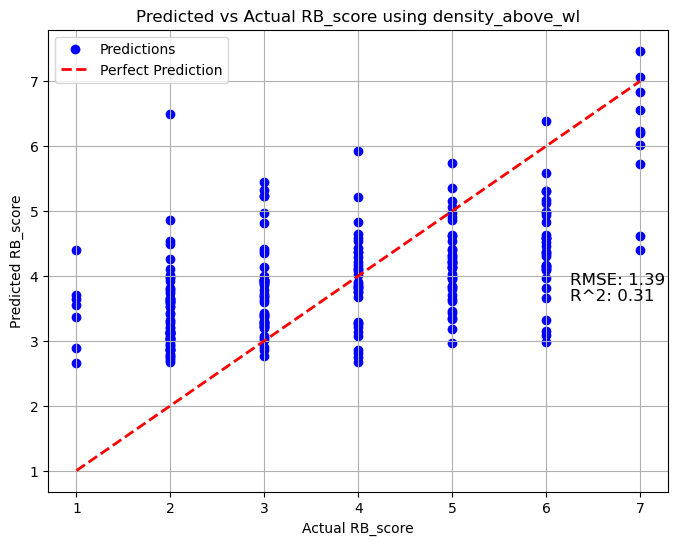

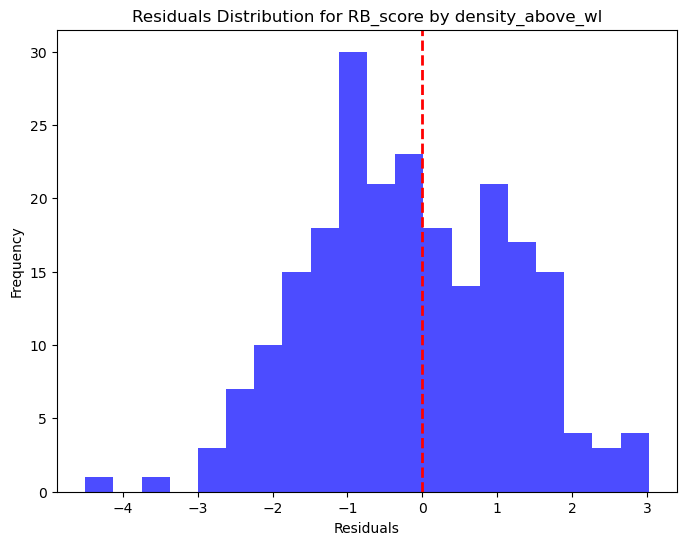

In [212]:
# Define predictor and target variables
predictor_var_density = "density_above_wl"
target_var = "RB_score"

# Prepare the data for the new model (using only density_above_wl with padding)
max_length_density = max(len(lst) for lst in df_raw[predictor_var_density])  # Determine maximum length for padding
X_density = np.array([lst + [0] * (max_length_density - len(lst)) for lst in df_raw[predictor_var_density]])
X_density_train, X_density_test, y_train, y_test = train_test_split(X_density, df_raw[target_var].values, test_size=0.3, random_state=36)

# Fit the model (only density_above_wl)
model_density = LinearRegression().fit(X_density_train, y_train)
y_pred_density = model_density.predict(X_density_test)

# Cross-validated RMSE for the density_above_wl model
cv_rmse_model_density = np.mean(np.sqrt(-cross_val_score(model_density, X_density, df_raw[target_var].values, scoring='neg_mean_squared_error', cv=10)))

print(f'Cross-validated RMSE for model with only {predictor_var_density}: {cv_rmse_model_density}')

# Plot Predicted vs Actual Values for the density_above_wl model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_density, c='blue', marker='o', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title(f'Predicted vs Actual {target_var} using {predictor_var_density}')
plt.xlabel(f'Actual {target_var}')
plt.ylabel(f'Predicted {target_var}')
plt.legend()
plt.grid(True)

# Annotate RMSE and R^2 on the plot for density_above_wl model
x_pos = y_test.min() + (7 / 8) * (y_test.max() - y_test.min())
y_pos = y_pred_density.min() + (1 / 4) * (y_pred_density.max() - y_pred_density.min())
plt.text(x_pos, y_pos, f'RMSE: {cv_rmse_model_density:.2f}', fontsize=12, color='black')
plt.text(x_pos, y_pos - (y_pred_density.max() - y_pred_density.min()) * 0.05, f'R^2: {r2_score(y_test, y_pred_density):.2f}', fontsize=12, color='black')

# Save and show the plot for density_above_wl model
plt.savefig(os.path.join(output_dir, f"predicted_vs_actual_{target_var}_by_{predictor_var_density}.png"))
plt.show()

# Plot Residuals Distribution for density_above_wl model
residuals_density = y_test - y_pred_density
plt.figure(figsize=(8, 6))
plt.hist(residuals_density, bins=20, alpha=0.7, color='blue')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title(f"Residuals Distribution for {target_var} by {predictor_var_density}")
plt.xlabel('Residuals')
plt.ylabel('Frequency')

# Save and show the residuals plot for density_above_wl model
plt.savefig(os.path.join(output_dir, f"residuals_distribution_{target_var}_by_{predictor_var_density}.png"))
plt.show()

F-statistic: 1.6721503757141918, p-value: 0.1974260906521691
Cross-validated RMSE for model with only density_above_wl: 1.3917500759420063
Cross-validated RMSE for model with density_above_wl and slopeangle: 1.3904255162430124


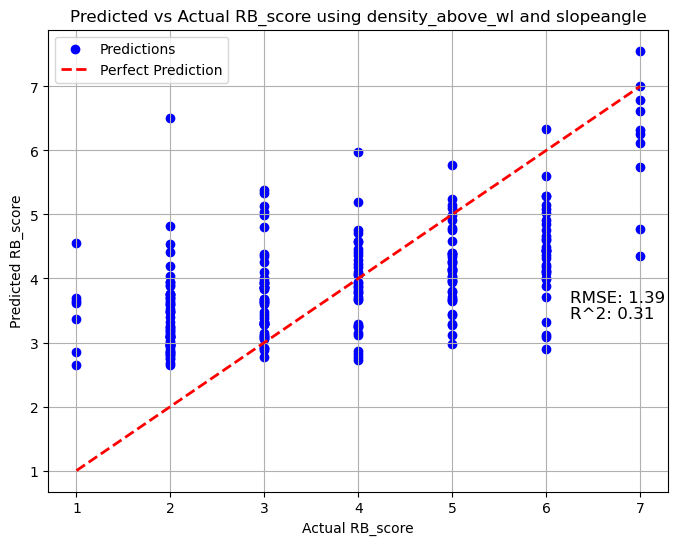

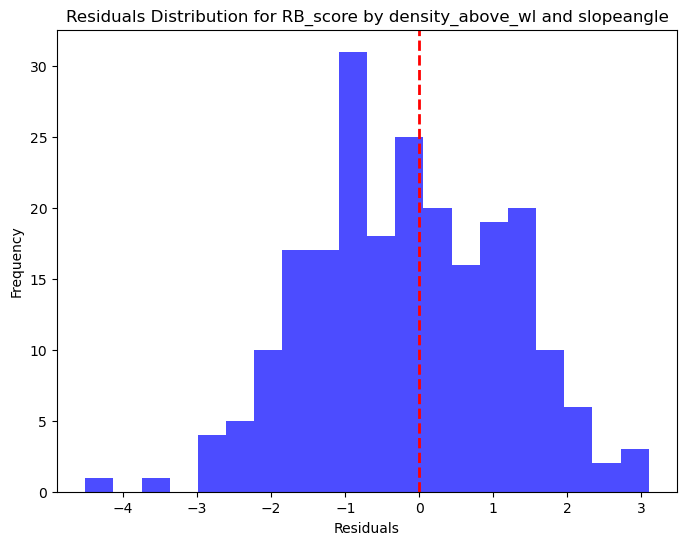

In [195]:
# Define predictor and target variables
predictor_var_density = "density_above_wl"
predictor_var_slope = "slopeangle"  # New additional predictor
target_var = "RB_score"

# Prepare the data for the original model (using only density_above_wl)
max_length_density = max(len(lst) for lst in df_raw[predictor_var_density])  # Determine maximum length for padding
X_density = np.array([lst + [0] * (max_length_density - len(lst)) for lst in df_raw[predictor_var_density]])
X_density_train, X_density_test, y_train, y_test = train_test_split(X_density, df_raw[target_var].values, test_size=0.3, random_state=36)

# Fit the original model (only density_above_wl)
model_density = LinearRegression().fit(X_density_train, y_train)
y_pred_density = model_density.predict(X_density_test)
rss_density = np.sum((y_test - y_pred_density) ** 2)  # Residual sum of squares for the density model

# Prepare the data for the new model (using both density_above_wl and slopeangle)
X_slope = df_raw[predictor_var_slope].values.reshape(-1, 1)  # slopeangle as a single column
X_density_padded = np.array([lst + [0] * (max_length_density - len(lst)) for lst in df_raw[predictor_var_density]])
X_combined = np.hstack((X_density_padded, X_slope))  # Combine density_above_wl and slopeangle horizontally

# Train-test split for the new model
X_combined_train, X_combined_test, y_train, y_test = train_test_split(X_combined, df_raw[target_var].values, test_size=0.3, random_state=36)

# Fit the new model (density_above_wl and slopeangle)
model_combined = LinearRegression().fit(X_combined_train, y_train)
y_pred_combined = model_combined.predict(X_combined_test)
rss_combined = np.sum((y_test - y_pred_combined) ** 2)  # Residual sum of squares for the combined model

# Calculate F-statistic to compare the two models
p = X_combined.shape[1] - X_density.shape[1]  # Number of additional predictors (1 in this case)
n = len(y_test)                              # Number of observations
k = X_combined.shape[1]                       # Number of predictors in the new model

f_stat = ((rss_density - rss_combined) / p) / (rss_combined / (n - k))
p_value = 1 - f.cdf(f_stat, p, n - k)
print(f'F-statistic: {f_stat}, p-value: {p_value}')

# Cross-validated RMSE for both models
cv_rmse_model_density = np.mean(np.sqrt(-cross_val_score(model_density, X_density, df_raw[target_var].values, scoring='neg_mean_squared_error', cv=10)))
cv_rmse_model_combined = np.mean(np.sqrt(-cross_val_score(model_combined, X_combined, df_raw[target_var].values, scoring='neg_mean_squared_error', cv=10)))

print(f'Cross-validated RMSE for model with only {predictor_var_density}: {cv_rmse_model_density}')
print(f'Cross-validated RMSE for model with {predictor_var_density} and {predictor_var_slope}: {cv_rmse_model_combined}')

# Plot Predicted vs Actual Values for the combined model (density_above_wl and slopeangle)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_combined, c='blue', marker='o', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title(f'Predicted vs Actual {target_var} using {predictor_var_density} and {predictor_var_slope}')
plt.xlabel(f'Actual {target_var}')
plt.ylabel(f'Predicted {target_var}')
plt.legend()
plt.grid(True)

# Annotate RMSE and R^2 on the plot for combined model
x_pos = y_test.min() + (7 / 8) * (y_test.max() - y_test.min())
y_pos = y_pred_combined.min() + (1 / 5) * (y_pred_combined.max() - y_pred_combined.min())
plt.text(x_pos, y_pos, f'RMSE: {cv_rmse_model_combined:.2f}', fontsize=12, color='black')
plt.text(x_pos, y_pos - (y_pred_combined.max() - y_pred_combined.min()) * 0.05, f'R^2: {r2_score(y_test, y_pred_combined):.2f}', fontsize=12, color='black')

# Save and show the plot for combined model
plt.savefig(os.path.join(output_dir, f"predicted_vs_actual_{target_var}_by_{predictor_var_density}_and_{predictor_var_slope}.png"))
plt.show()

# Plot Residuals Distribution for combined model
residuals_combined = y_test - y_pred_combined
plt.figure(figsize=(8, 6))
plt.hist(residuals_combined, bins=20, alpha=0.7, color='blue')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title(f'Residuals Distribution for {target_var} by {predictor_var_density} and {predictor_var_slope}')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

# Save and show the residuals plot for combined model
plt.savefig(os.path.join(output_dir, f"residuals_distribution_{target_var}_by_{predictor_var_density}_and_{predictor_var_slope}.png"))
plt.show()

F-statistic: 3.972590340854872, p-value: nan
Cross-validated RMSE for model with only density_above_wl: 1.3917500759420063
Cross-validated RMSE for model with only slopeangle: 1.5870448929292285


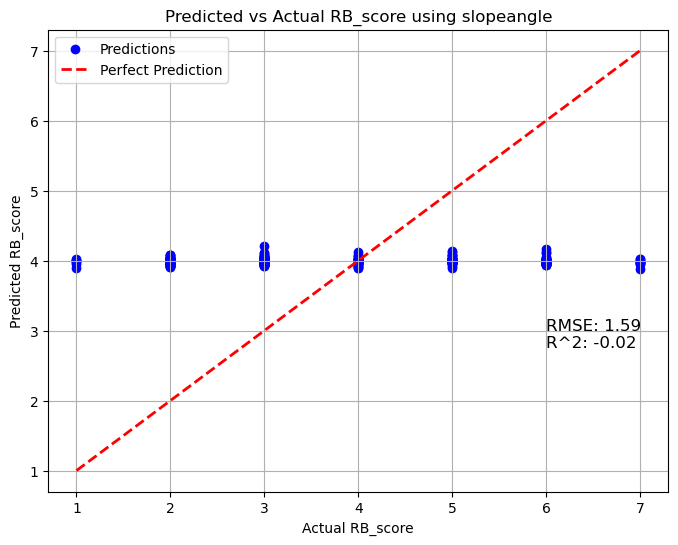

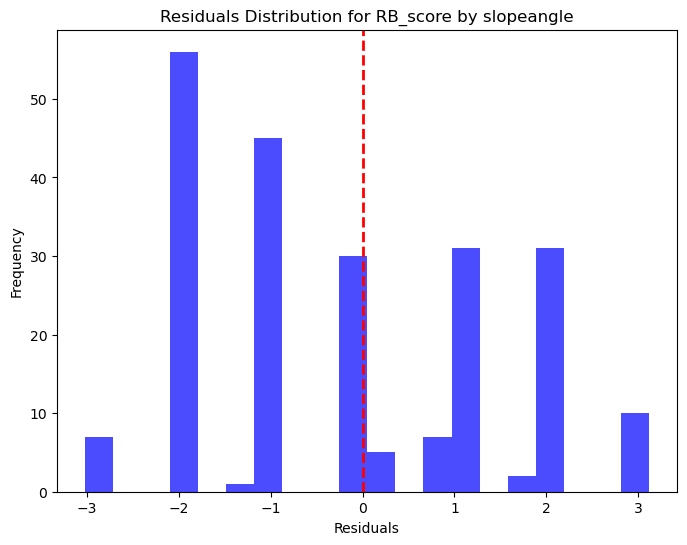

In [196]:
# Define predictor and target variables
predictor_var_density = "density_above_wl"
predictor_var_slope = "slopeangle"  # New single predictor model
target_var = "RB_score"

# Prepare the data for the density_above_wl model (current best model)
max_length_density = max(len(lst) for lst in df_raw[predictor_var_density])  # Determine maximum length for padding
X_density = np.array([lst + [0] * (max_length_density - len(lst)) for lst in df_raw[predictor_var_density]])
X_density_train, X_density_test, y_train, y_test = train_test_split(X_density, df_raw[target_var].values, test_size=0.3, random_state=36)

# Fit the model with only density_above_wl
model_density = LinearRegression().fit(X_density_train, y_train)
y_pred_density = model_density.predict(X_density_test)
rss_density = np.sum((y_test - y_pred_density) ** 2)  # Residual sum of squares for the density model

# Prepare the data for the slopeangle model
X_slope = df_raw[predictor_var_slope].values.reshape(-1, 1)  # slopeangle as a single column
X_slope_train, X_slope_test, _, _ = train_test_split(X_slope, df_raw[target_var].values, test_size=0.3, random_state=36)

# Fit the model with only slopeangle
model_slope = LinearRegression().fit(X_slope_train, y_train)
y_pred_slope = model_slope.predict(X_slope_test)
rss_slope = np.sum((y_test - y_pred_slope) ** 2)  # Residual sum of squares for the slope model

# Calculate F-statistic to compare the two single-input models
p = X_slope.shape[1] - X_density.shape[1]  # Number of additional predictors (0, as both are single-input models)
n = len(y_test)                            # Number of observations
k = X_slope.shape[1]                       # Number of predictors in the new model

# For comparison between two single-input models, F-test is limited, but we calculate RMSE values
f_stat = ((rss_density - rss_slope) / p) / (rss_slope / (n - k)) if p != 0 else 0
p_value = 1 - f.cdf(f_stat, p, n - k) if p != 0 else 1.0
print(f'F-statistic: {f_stat}, p-value: {p_value}')

# Cross-validated RMSE for both models
cv_rmse_model_density = np.mean(np.sqrt(-cross_val_score(model_density, X_density, df_raw[target_var].values, scoring='neg_mean_squared_error', cv=10)))
cv_rmse_model_slope = np.mean(np.sqrt(-cross_val_score(model_slope, X_slope, df_raw[target_var].values, scoring='neg_mean_squared_error', cv=10)))

print(f'Cross-validated RMSE for model with only {predictor_var_density}: {cv_rmse_model_density}')
print(f'Cross-validated RMSE for model with only {predictor_var_slope}: {cv_rmse_model_slope}')

# Plot Predicted vs Actual Values for the slopeangle model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_slope, c='blue', marker='o', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title(f'Predicted vs Actual {target_var} using {predictor_var_slope}')
plt.xlabel(f'Actual {target_var}')
plt.ylabel(f'Predicted {target_var}')
plt.legend()
plt.grid(True)

# Annotate RMSE and R^2 on the plot for slopeangle model
x_pos = 6
y_pos = 3
plt.text(x_pos, y_pos, f'RMSE: {cv_rmse_model_slope:.2f}', fontsize=12, color='black')
plt.text(x_pos, y_pos - y_pos * 0.08, f'R^2: {r2_score(y_test, y_pred_slope):.2f}', fontsize=12, color='black')

# Save and show the plot for slopeangle model
plt.savefig(os.path.join(output_dir, f"predicted_vs_actual_{target_var}_by_{predictor_var_slope}.png"))
plt.show()

# Plot Residuals Distribution for slopeangle model
residuals_slope = y_test - y_pred_slope
plt.figure(figsize=(8, 6))
plt.hist(residuals_slope, bins=20, alpha=0.7, color='blue')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title(f'Residuals Distribution for {target_var} by {predictor_var_slope}')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

# Save and show the residuals plot for slopeangle model
plt.savefig(os.path.join(output_dir, f"residuals_distribution_{target_var}_by_{predictor_var_slope}.png"))
plt.show()

F-statistic: -3.900152862341859, p-value: 1.0
Cross-validated RMSE for model with only density_above_wl: 1.3917500759420063
Cross-validated RMSE for model with density_above_wl, slopeangle, and layers_above_wl: 4.71530369855351


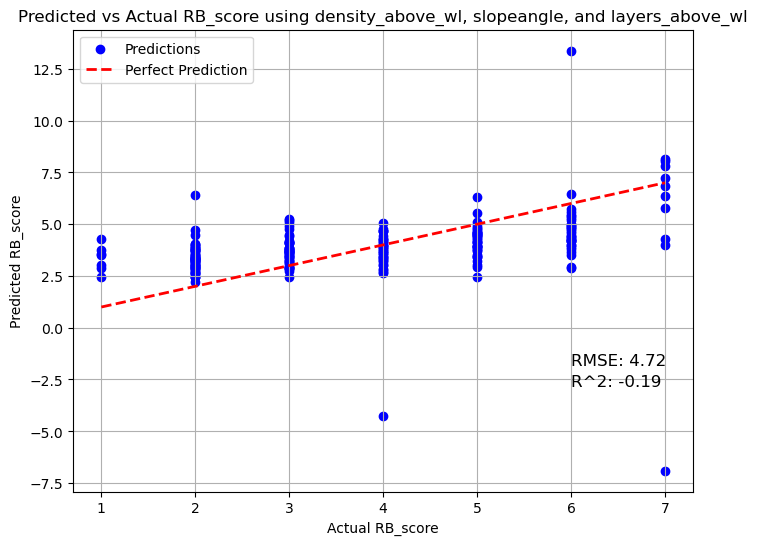

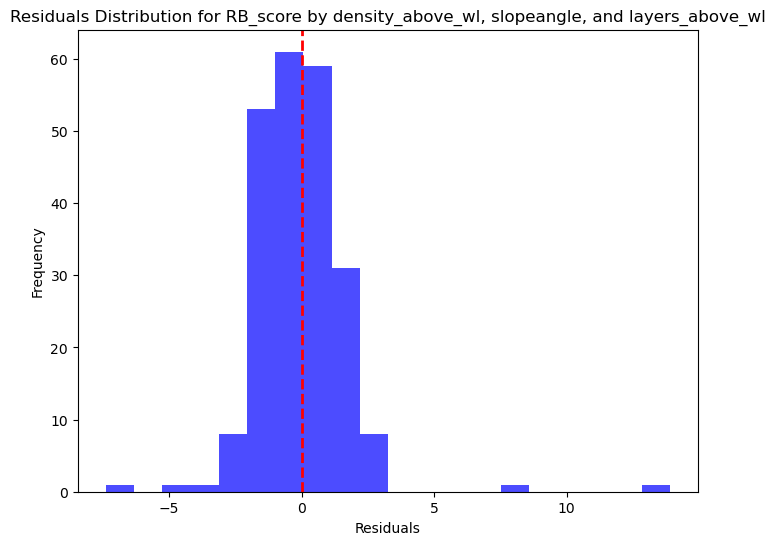

In [197]:
# Define predictor and target variables
predictor_var_density = "density_above_wl"
predictor_var_slope = "slopeangle"
predictor_var_layers = "layers_above_wl"
target_var = "RB_score"

# Prepare the data for the density_above_wl model (current best model)
max_length_density = max(len(lst) for lst in df_raw[predictor_var_density])  # Determine maximum length for padding
X_density = np.array([lst + [0] * (max_length_density - len(lst)) for lst in df_raw[predictor_var_density]])
X_density_train, X_density_test, y_train, y_test = train_test_split(X_density, df_raw[target_var].values, test_size=0.3, random_state=36)

# Fit the model with only density_above_wl
model_density = LinearRegression().fit(X_density_train, y_train)
y_pred_density = model_density.predict(X_density_test)
rss_density = np.sum((y_test - y_pred_density) ** 2)  # Residual sum of squares for the density model

# Prepare the data for the combined model (density_above_wl, slopeangle, and layers_above_wl)
X_slope = df_raw[predictor_var_slope].values.reshape(-1, 1)  # slopeangle as a single column
max_length_layers = max(len(lst) for lst in df_raw[predictor_var_layers])  # Determine max length for padding layers
X_layers = np.array([lst + [0] * (max_length_layers - len(lst)) for lst in df_raw[predictor_var_layers]])

# Combine all three predictors horizontally
X_density_padded = np.array([lst + [0] * (max_length_density - len(lst)) for lst in df_raw[predictor_var_density]])
X_combined = np.hstack((X_density_padded, X_slope, X_layers))

# Train-test split for the combined model
X_combined_train, X_combined_test, y_train, y_test = train_test_split(X_combined, df_raw[target_var].values, test_size=0.3, random_state=36)

# Fit the new model (density_above_wl, slopeangle, and layers_above_wl)
model_combined = LinearRegression().fit(X_combined_train, y_train)
y_pred_combined = model_combined.predict(X_combined_test)
rss_combined = np.sum((y_test - y_pred_combined) ** 2)  # Residual sum of squares for the combined model

# Calculate F-statistic to compare the two models
p = X_combined.shape[1] - X_density.shape[1]  # Number of additional predictors
n = len(y_test)                               # Number of observations
k = X_combined.shape[1]                        # Total number of predictors in the combined model

f_stat = ((rss_density - rss_combined) / p) / (rss_combined / (n - k))
p_value = 1 - f.cdf(f_stat, p, n - k)
print(f'F-statistic: {f_stat}, p-value: {p_value}')

# Cross-validated RMSE for both models
cv_rmse_model_density = np.mean(np.sqrt(-cross_val_score(model_density, X_density, df_raw[target_var].values, scoring='neg_mean_squared_error', cv=10)))
cv_rmse_model_combined = np.mean(np.sqrt(-cross_val_score(model_combined, X_combined, df_raw[target_var].values, scoring='neg_mean_squared_error', cv=10)))

print(f'Cross-validated RMSE for model with only {predictor_var_density}: {cv_rmse_model_density}')
print(f'Cross-validated RMSE for model with {predictor_var_density}, {predictor_var_slope}, and {predictor_var_layers}: {cv_rmse_model_combined}')

# Plot Predicted vs Actual Values for the combined model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_combined, c='blue', marker='o', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title(f'Predicted vs Actual {target_var} using {predictor_var_density}, {predictor_var_slope}, and {predictor_var_layers}')
plt.xlabel(f'Actual {target_var}')
plt.ylabel(f'Predicted {target_var}')
plt.legend()
plt.grid(True)

# Annotate RMSE and R^2 on the plot for combined model
x_pos = y_test.min() + (5 / 6) * (y_test.max() - y_test.min())
y_pos = y_pred_combined.min() + (1 / 4) * (y_pred_combined.max() - y_pred_combined.min())
plt.text(x_pos, y_pos, f'RMSE: {cv_rmse_model_combined:.2f}', fontsize=12, color='black')
plt.text(x_pos, y_pos - (y_pred_combined.max() - y_pred_combined.min()) * 0.05, f'R^2: {r2_score(y_test, y_pred_combined):.2f}', fontsize=12, color='black')

# Save and show the plot for combined model
plt.savefig(os.path.join(output_dir, f"predicted_vs_actual_{target_var}_by_{predictor_var_density}_{predictor_var_slope}_{predictor_var_layers}.png"))
plt.show()

# Plot Residuals Distribution for combined model
residuals_combined = y_test - y_pred_combined
plt.figure(figsize=(8, 6))
plt.hist(residuals_combined, bins=20, alpha=0.7, color='blue')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title(f'Residuals Distribution for {target_var} by {predictor_var_density}, {predictor_var_slope}, and {predictor_var_layers}')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

# Save and show the residuals plot for combined model
plt.savefig(os.path.join(output_dir, f"residuals_distribution_{target_var}_by_{predictor_var_density}_{predictor_var_slope}_{predictor_var_layers}.png"))
plt.show()

F-statistic: 0.17753109279481794, p-value: nan
Cross-validated RMSE for model with only density_above_wl: 1.3917500759420063
Cross-validated RMSE for model with only trunc_density_above_wl: 1.4083975840005756


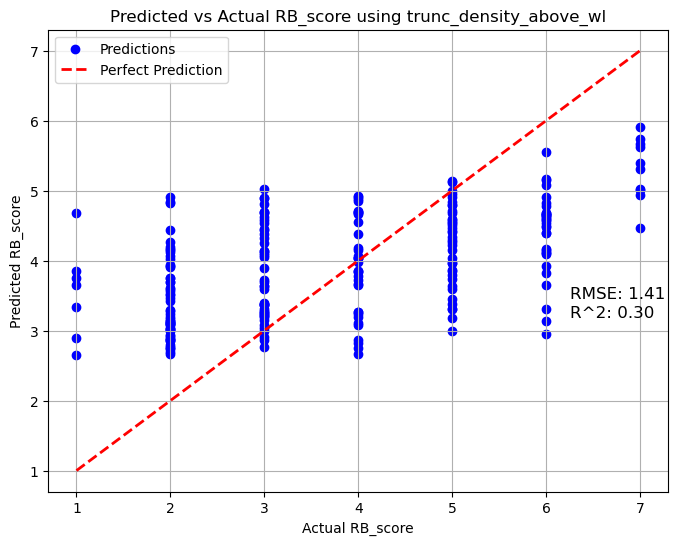

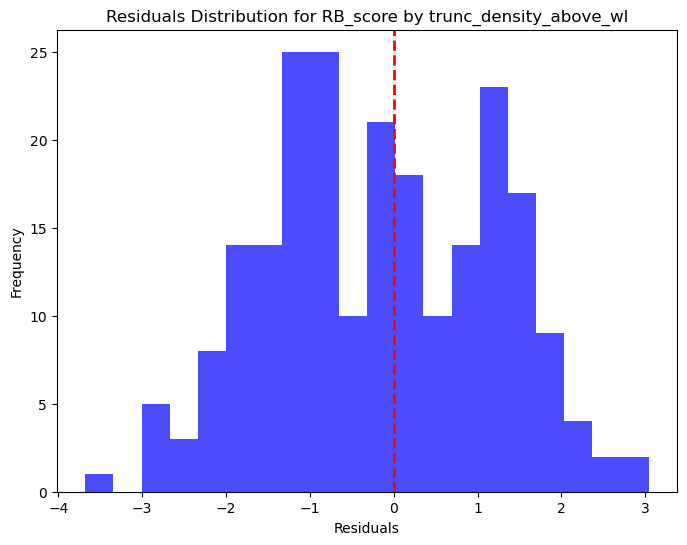

In [209]:
# Define predictor and target variables
predictor_var_density = "density_above_wl"  # Previously used density variable
predictor_var_trunc_density = "trunc_density_above_wl"  # New truncated density variable
target_var = "RB_score"

# Prepare the data for the original model (using padded density_above_wl)
max_length_density = max(len(lst) for lst in df_raw[predictor_var_density])  # Determine maximum length for padding
X_density = np.array([lst + [0] * (max_length_density - len(lst)) for lst in df_raw[predictor_var_density]])
X_density_train, X_density_test, y_train, y_test = train_test_split(X_density, df_raw[target_var].values, test_size=0.3, random_state=36)

# Fit the original model (only density_above_wl)
model_density = LinearRegression().fit(X_density_train, y_train)
y_pred_density = model_density.predict(X_density_test)
rss_density = np.sum((y_test - y_pred_density) ** 2)  # Residual sum of squares for the density model

# Prepare the data for the new model (using truncated density_above_wl)
X_trunc_density = np.array(df_raw[predictor_var_trunc_density].tolist())
X_trunc_density_train, X_trunc_density_test, _, _ = train_test_split(X_trunc_density, df_raw[target_var].values, test_size=0.3, random_state=36)

# Fit the new model (only trunc_density_above_wl)
model_trunc_density = LinearRegression().fit(X_trunc_density_train, y_train)
y_pred_trunc_density = model_trunc_density.predict(X_trunc_density_test)
rss_trunc_density = np.sum((y_test - y_pred_trunc_density) ** 2)  # Residual sum of squares for the trunc_density model

# Calculate F-statistic to compare the two models
p = X_trunc_density.shape[1] - X_density.shape[1]  # Number of additional predictors (0 in this case, as both are single-input models)
n = len(y_test)                                    # Number of observations
k = X_trunc_density.shape[1]                       # Number of predictors in the new model

# For comparison between two single-input models, F-test is limited, but we calculate RMSE values
f_stat = ((rss_density - rss_trunc_density) / p) / (rss_trunc_density / (n - k)) if p != 0 else 0
p_value = 1 - f.cdf(f_stat, p, n - k) if p != 0 else 1.0
print(f'F-statistic: {f_stat}, p-value: {p_value}')

# Cross-validated RMSE for both models
cv_rmse_model_density = np.mean(np.sqrt(-cross_val_score(model_density, X_density, df_raw[target_var].values, scoring='neg_mean_squared_error', cv=10)))
cv_rmse_model_trunc_density = np.mean(np.sqrt(-cross_val_score(model_trunc_density, X_trunc_density, df_raw[target_var].values, scoring='neg_mean_squared_error', cv=10)))

print(f'Cross-validated RMSE for model with only {predictor_var_density}: {cv_rmse_model_density}')
print(f'Cross-validated RMSE for model with only {predictor_var_trunc_density}: {cv_rmse_model_trunc_density}')

# Plot Predicted vs Actual Values for the trunc_density_above_wl model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_trunc_density, c='blue', marker='o', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title(f'Predicted vs Actual {target_var} using {predictor_var_trunc_density}')
plt.xlabel(f'Actual {target_var}')
plt.ylabel(f'Predicted {target_var}')
plt.legend()
plt.grid(True)

# Annotate RMSE and R^2 on the plot for trunc_density_above_wl model
x_pos = y_test.min() + (7 / 8) * (y_test.max() - y_test.min())
y_pos = y_pred_trunc_density.min() + (1 / 4) * (y_pred_trunc_density.max() - y_pred_trunc_density.min())
plt.text(x_pos, y_pos, f'RMSE: {cv_rmse_model_trunc_density:.2f}', fontsize=12, color='black')
plt.text(x_pos, y_pos*0.92, f'R^2: {r2_score(y_test, y_pred_trunc_density):.2f}', fontsize=12, color='black')

# Save and show the plot for trunc_density_above_wl model
plt.savefig(os.path.join(output_dir, f"predicted_vs_actual_{target_var}_by_{predictor_var_trunc_density}.png"))
plt.show()

# Plot Residuals Distribution for trunc_density_above_wl model
residuals_trunc_density = y_test - y_pred_trunc_density
plt.figure(figsize=(8, 6))
plt.hist(residuals_trunc_density, bins=20, alpha=0.7, color='blue')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title(f'Residuals Distribution for {target_var} by {predictor_var_trunc_density}')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

# Save and show the residuals plot for trunc_density_above_wl model
plt.savefig(os.path.join(output_dir, f"residuals_distribution_{target_var}_by_{predictor_var_trunc_density}.png"))
plt.show()

F-statistic: 3.8818718071369775, p-value: 0.0010643489160995223
Cross-validated RMSE for model with only trunc_density_above_wl: 1.4083975840005756
Cross-validated RMSE for model with trunc_density_above_wl and trunc_layers_above_wl: 1.3598266824171525


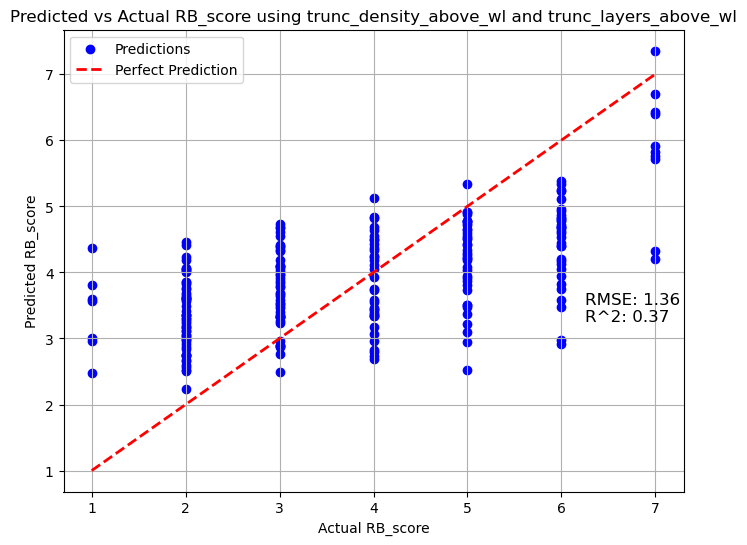

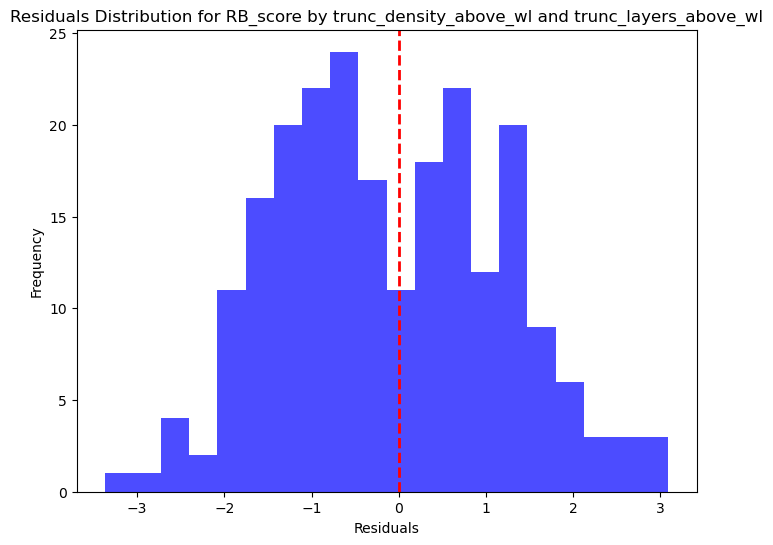

In [202]:
# Define predictor and target variables
predictor_var_trunc_density = "trunc_density_above_wl"  # Single-input predictor
predictor_var_trunc_layers = "trunc_layers_above_wl"    # Additional predictor for the two-input model
target_var = "RB_score"

# Determine maximum length for padding in truncated versions
max_length_trunc_density = max(len(lst) for lst in df_raw[predictor_var_trunc_density])
max_length_trunc_layers = max(len(lst) for lst in df_raw[predictor_var_trunc_layers])
max_length = max(max_length_trunc_density, max_length_trunc_layers)  # Use the longer length for padding consistency

# Prepare the data for the single-input model (using only trunc_density_above_wl with padding)
X_trunc_density = np.array([lst + [0] * (max_length - len(lst)) for lst in df_raw[predictor_var_trunc_density]])
X_trunc_density_train, X_trunc_density_test, y_train, y_test = train_test_split(X_trunc_density, df_raw[target_var].values, test_size=0.3, random_state=36)

# Fit the single-input model (only trunc_density_above_wl)
model_trunc_density = LinearRegression().fit(X_trunc_density_train, y_train)
y_pred_trunc_density = model_trunc_density.predict(X_trunc_density_test)
rss_trunc_density = np.sum((y_test - y_pred_trunc_density) ** 2)  # Residual sum of squares for the single-input model

# Prepare the data for the two-input model (using trunc_density_above_wl and trunc_layers_above_wl with padding)
X_trunc_layers = np.array([lst + [0] * (max_length - len(lst)) for lst in df_raw[predictor_var_trunc_layers]])
X_combined = np.hstack((X_trunc_density, X_trunc_layers))  # Combine both predictors

# Train-test split for the combined model
X_combined_train, X_combined_test, y_train, y_test = train_test_split(X_combined, df_raw[target_var].values, test_size=0.3, random_state=36)

# Fit the two-input model (trunc_density_above_wl and trunc_layers_above_wl)
model_combined = LinearRegression().fit(X_combined_train, y_train)
y_pred_combined = model_combined.predict(X_combined_test)
rss_combined = np.sum((y_test - y_pred_combined) ** 2)  # Residual sum of squares for the combined model

# Calculate F-statistic to compare the two models
p = X_combined.shape[1] - X_trunc_density.shape[1]  # Number of additional predictors (1 in this case)
n = len(y_test)                                     # Number of observations
k = X_combined.shape[1]                             # Total number of predictors in the combined model

f_stat = ((rss_trunc_density - rss_combined) / p) / (rss_combined / (n - k))
p_value = 1 - f.cdf(f_stat, p, n - k)
print(f'F-statistic: {f_stat}, p-value: {p_value}')

# Cross-validated RMSE for both models
cv_rmse_model_trunc_density = np.mean(np.sqrt(-cross_val_score(model_trunc_density, X_trunc_density, df_raw[target_var].values, scoring='neg_mean_squared_error', cv=10)))
cv_rmse_model_combined = np.mean(np.sqrt(-cross_val_score(model_combined, X_combined, df_raw[target_var].values, scoring='neg_mean_squared_error', cv=10)))

print(f'Cross-validated RMSE for model with only {predictor_var_trunc_density}: {cv_rmse_model_trunc_density}')
print(f'Cross-validated RMSE for model with {predictor_var_trunc_density} and {predictor_var_trunc_layers}: {cv_rmse_model_combined}')

# Plot Predicted vs Actual Values for the combined model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_combined, c='blue', marker='o', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title(f'Predicted vs Actual {target_var} using {predictor_var_trunc_density} and {predictor_var_trunc_layers}')
plt.xlabel(f'Actual {target_var}')
plt.ylabel(f'Predicted {target_var}')
plt.legend()
plt.grid(True)

# Annotate RMSE and R^2 on the plot for combined model
x_pos = y_test.min() + (7 / 8) * (y_test.max() - y_test.min())
y_pos = y_pred_combined.min() + (1 / 4) * (y_pred_combined.max() - y_pred_combined.min())
plt.text(x_pos, y_pos, f'RMSE: {cv_rmse_model_combined:.2f}', fontsize=12, color='black')
plt.text(x_pos, y_pos - (y_pred_combined.max() - y_pred_combined.min()) * 0.05, f'R^2: {r2_score(y_test, y_pred_combined):.2f}', fontsize=12, color='black')

# Save and show the plot for combined model
plt.savefig(os.path.join(output_dir, f"predicted_vs_actual_{target_var}_by_{predictor_var_trunc_density}_and_{predictor_var_trunc_layers}.png"))
plt.show()

# Plot Residuals Distribution for combined model
residuals_combined = y_test - y_pred_combined
plt.figure(figsize=(8, 6))
plt.hist(residuals_combined, bins=20, alpha=0.7, color='blue')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title(f'Residuals Distribution for {target_var} by {predictor_var_trunc_density} and {predictor_var_trunc_layers}')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

# Save and show the residuals plot for combined model
plt.savefig(os.path.join(output_dir, f"residuals_distribution_{target_var}_by_{predictor_var_trunc_density}_and_{predictor_var_trunc_layers}.png"))
plt.show()

F-statistic: 0.8604329414760539, p-value: 0.35467241310605246
Cross-validated RMSE for model with trunc_density_above_wl and trunc_layers_above_wl: 1.3598266824171525
Cross-validated RMSE for model with trunc_density_above_wl, trunc_layers_above_wl, and slopeangle: 1.3606116277026512


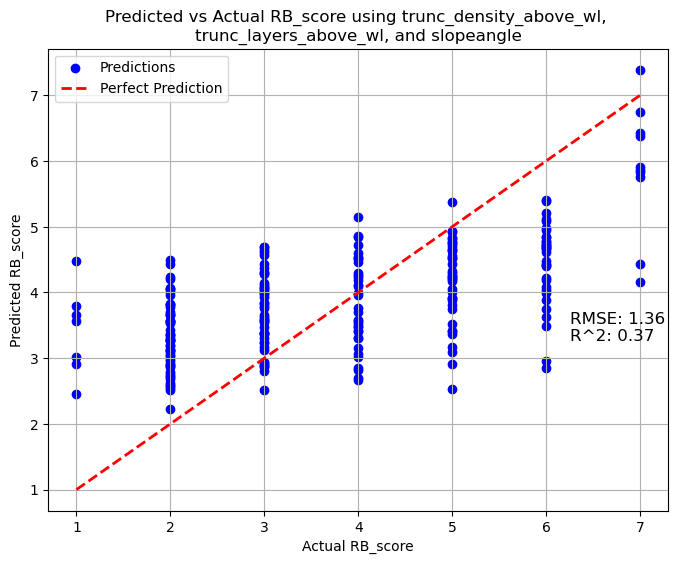

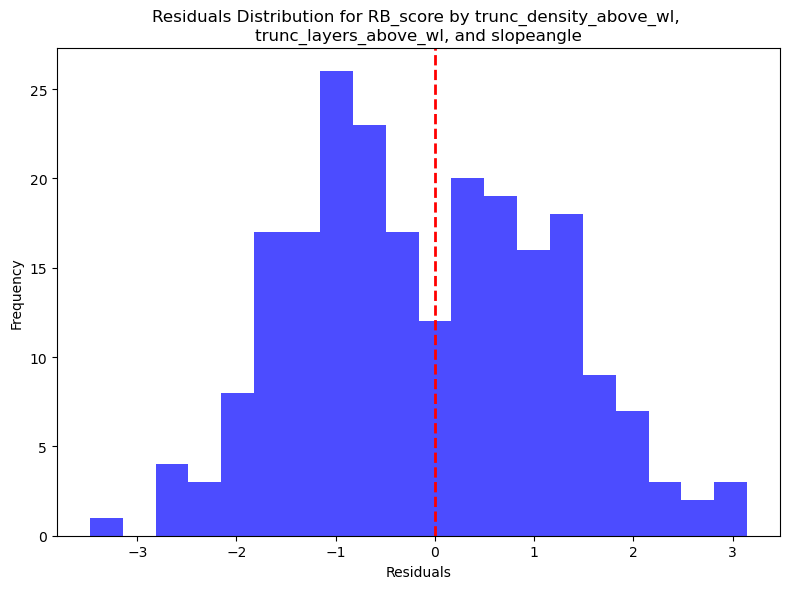

In [208]:
# Define predictor and target variables
predictor_var_trunc_density = "trunc_density_above_wl"
predictor_var_trunc_layers = "trunc_layers_above_wl"
predictor_var_slope = "slopeangle"  # Additional predictor for the three-input model
target_var = "RB_score"

# Determine maximum length for padding in truncated versions
max_length_trunc_density = max(len(lst) for lst in df_raw[predictor_var_trunc_density])
max_length_trunc_layers = max(len(lst) for lst in df_raw[predictor_var_trunc_layers])
max_length = max(max_length_trunc_density, max_length_trunc_layers)  # Use the longer length for padding consistency

# Prepare the data for the two-input model (using trunc_density_above_wl and trunc_layers_above_wl with padding)
X_trunc_density = np.array([lst + [0] * (max_length - len(lst)) for lst in df_raw[predictor_var_trunc_density]])
X_trunc_layers = np.array([lst + [0] * (max_length - len(lst)) for lst in df_raw[predictor_var_trunc_layers]])
X_combined_two = np.hstack((X_trunc_density, X_trunc_layers))  # Combine the two predictors

# Train-test split for the two-input model
X_combined_two_train, X_combined_two_test, y_train, y_test = train_test_split(X_combined_two, df_raw[target_var].values, test_size=0.3, random_state=36)

# Fit the two-input model (trunc_density_above_wl and trunc_layers_above_wl)
model_two_input = LinearRegression().fit(X_combined_two_train, y_train)
y_pred_two_input = model_two_input.predict(X_combined_two_test)
rss_two_input = np.sum((y_test - y_pred_two_input) ** 2)  # Residual sum of squares for the two-input model

# Prepare the data for the three-input model (using trunc_density_above_wl, trunc_layers_above_wl, and slopeangle with padding)
X_slope = df_raw[predictor_var_slope].values.reshape(-1, 1)  # slopeangle as a single column
X_combined_three = np.hstack((X_combined_two, X_slope))      # Combine all three predictors

# Train-test split for the three-input model
X_combined_three_train, X_combined_three_test, y_train, y_test = train_test_split(X_combined_three, df_raw[target_var].values, test_size=0.3, random_state=36)

# Fit the three-input model (trunc_density_above_wl, trunc_layers_above_wl, and slopeangle)
model_three_input = LinearRegression().fit(X_combined_three_train, y_train)
y_pred_three_input = model_three_input.predict(X_combined_three_test)
rss_three_input = np.sum((y_test - y_pred_three_input) ** 2)  # Residual sum of squares for the three-input model

# Calculate F-statistic to compare the two-input and three-input models
p = X_combined_three.shape[1] - X_combined_two.shape[1]  # Number of additional predictors (1 in this case)
n = len(y_test)                                          # Number of observations
k = X_combined_three.shape[1]                            # Total number of predictors in the three-input model

f_stat = ((rss_two_input - rss_three_input) / p) / (rss_three_input / (n - k))
p_value = 1 - f.cdf(f_stat, p, n - k)
print(f'F-statistic: {f_stat}, p-value: {p_value}')

# Cross-validated RMSE for both models
cv_rmse_model_two_input = np.mean(np.sqrt(-cross_val_score(model_two_input, X_combined_two, df_raw[target_var].values, scoring='neg_mean_squared_error', cv=10)))
cv_rmse_model_three_input = np.mean(np.sqrt(-cross_val_score(model_three_input, X_combined_three, df_raw[target_var].values, scoring='neg_mean_squared_error', cv=10)))

print(f'Cross-validated RMSE for model with {predictor_var_trunc_density} and {predictor_var_trunc_layers}: {cv_rmse_model_two_input}')
print(f'Cross-validated RMSE for model with {predictor_var_trunc_density}, {predictor_var_trunc_layers}, and {predictor_var_slope}: {cv_rmse_model_three_input}')

# Plot Predicted vs Actual Values for the three-input model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_three_input, c='blue', marker='o', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title(f'Predicted vs Actual {target_var} using {predictor_var_trunc_density}, \n'
          f'{predictor_var_trunc_layers}, and {predictor_var_slope}')
plt.xlabel(f'Actual {target_var}')
plt.ylabel(f'Predicted {target_var}')
plt.legend()
plt.grid(True)

# Annotate RMSE and R^2 on the plot for three-input model
x_pos = y_test.min() + (7 / 8) * (y_test.max() - y_test.min())
y_pos = y_pred_three_input.min() + (1 / 4) * (y_pred_three_input.max() - y_pred_three_input.min())
plt.text(x_pos, y_pos, f'RMSE: {cv_rmse_model_three_input:.2f}', fontsize=12, color='black')
plt.text(x_pos, y_pos - (y_pred_three_input.max() - y_pred_three_input.min()) * 0.05, f'R^2: {r2_score(y_test, y_pred_three_input):.2f}', fontsize=12, color='black')

# Save and show the plot for three-input model
plt.savefig(os.path.join(output_dir, f"predicted_vs_actual_{target_var}_by_{predictor_var_trunc_density}_{predictor_var_trunc_layers}_{predictor_var_slope}.png"))
plt.show()

# Plot Residuals Distribution for three-input model
residuals_three_input = y_test - y_pred_three_input
plt.figure(figsize=(8, 6))
plt.hist(residuals_three_input, bins=20, alpha=0.7, color='blue')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title(f'Residuals Distribution for {target_var} by {predictor_var_trunc_density}, \n'
          f'{predictor_var_trunc_layers}, and {predictor_var_slope}')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

# Save and show the residuals plot for three-input model
plt.tight_layout()
plt.savefig(os.path.join(output_dir, f"residuals_distribution_{target_var}_by_{predictor_var_trunc_density}_{predictor_var_trunc_layers}_{predictor_var_slope}.png"))
plt.show()

In [ ]:
### Adding slopeangle is thus not significant ###

### We now move over to the third segment of the modelling approach

### Trying to improve our predctive capabilities by utilizing localNowcast as well

In [218]:
## Begin by defining a new save_folder
os.makedirs(output_dir_2, exist_ok=True)
output_dir_2 = os.path.join(os.getcwd(), "CN_thesis_plots", "2_raw_localNowcast")

In [220]:
### Since we could not with significance decide which of density vs trunc_density+trunc_layers was best, we check adding localNowcast to density

F-statistic: 70.2288301310907, p-value: 8.326672684688674e-15
Cross-validated RMSE for model with only density_above_wl: 1.3917500759420063
Cross-validated RMSE for model with density_above_wl and localNowcast: 1.156688541320861


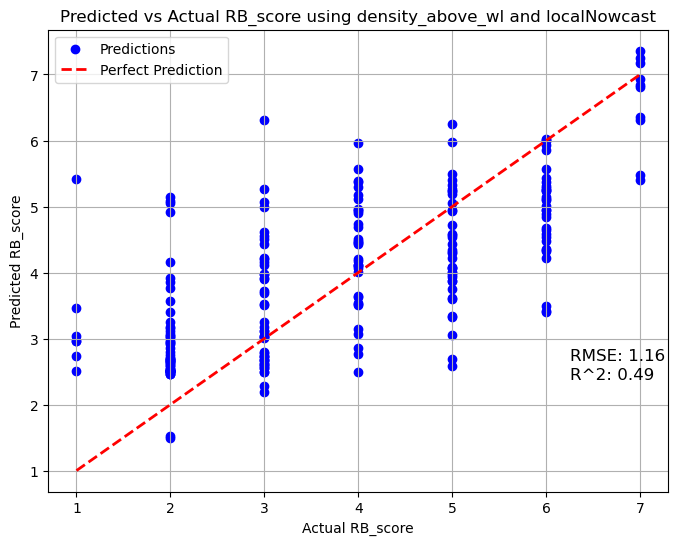

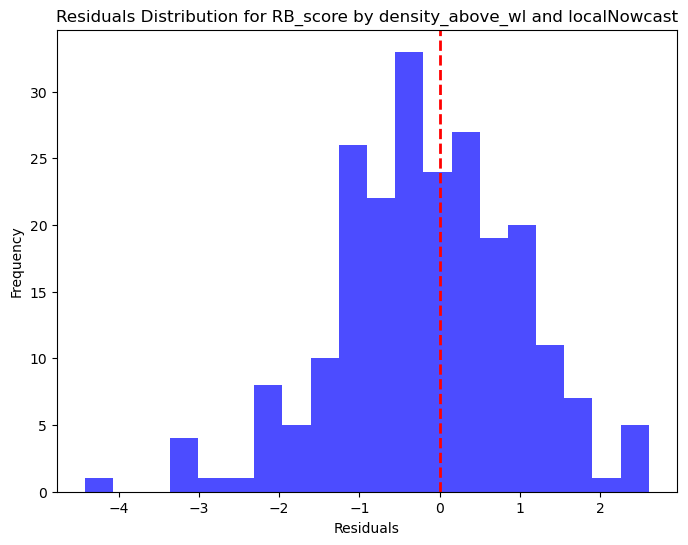

In [320]:
# Define predictor and target variables
predictor_var_density_unique = "density_above_wl"
predictor_var_localNowcast_unique = "localNowcast"  # Additional predictor
target_var_unique = "RB_score"

# Prepare the data for the original model (only density_above_wl with padding)
max_length_density_unique = max(len(lst) for lst in df_raw[predictor_var_density_unique])  # Determine maximum length for padding
X_density_unique = np.array([lst + [0] * (max_length_density_unique - len(lst)) for lst in df_raw[predictor_var_density_unique]])
X_density_train_unique, X_density_test_unique, y_train_unique, y_test_unique = train_test_split(X_density_unique, df_raw[target_var_unique].values, test_size=0.3, random_state=36)

# Fit the original model (only density_above_wl)
model_density_unique = LinearRegression().fit(X_density_train_unique, y_train_unique)
y_pred_density_unique = model_density_unique.predict(X_density_test_unique)
rss_density_unique = np.sum((y_test_unique - y_pred_density_unique) ** 2)  # Residual sum of squares for the density model

# Prepare the data for the new model (using density_above_wl and localNowcast)
X_localNowcast_unique = df_raw[predictor_var_localNowcast_unique].values.reshape(-1, 1)  # localNowcast as a single column
X_combined_unique = np.hstack((X_density_unique, X_localNowcast_unique))  # Combine density_above_wl and localNowcast horizontally

# Train-test split for the new model
X_combined_train_unique, X_combined_test_unique, y_train_combined_unique, y_test_combined_unique = train_test_split(
    X_combined_unique, df_raw[target_var_unique].values, test_size=0.3, random_state=36
)

# Fit the new model (density_above_wl and localNowcast)
model_combined_unique = LinearRegression().fit(X_combined_train_unique, y_train_combined_unique)
y_pred_combined_unique = model_combined_unique.predict(X_combined_test_unique)
rss_combined_unique = np.sum((y_test_combined_unique - y_pred_combined_unique) ** 2)  # Residual sum of squares for the combined model

# Calculate F-statistic to compare the single-input and two-input models
p_unique = X_combined_unique.shape[1] - X_density_unique.shape[1]  # Number of additional predictors (1 in this case)
n_unique = len(y_test_combined_unique)                              # Number of observations
k_unique = X_combined_unique.shape[1]                               # Number of predictors in the new model

f_stat_unique = ((rss_density_unique - rss_combined_unique) / p_unique) / (rss_combined_unique / (n_unique - k_unique))
p_value_unique = 1 - f.cdf(f_stat_unique, p_unique, n_unique - k_unique)
print(f'F-statistic: {f_stat_unique}, p-value: {p_value_unique}')

# Cross-validated RMSE for both models
cv_rmse_model_density_unique = np.mean(np.sqrt(-cross_val_score(
    model_density_unique, X_density_unique, df_raw[target_var_unique].values, scoring='neg_mean_squared_error', cv=10
)))
cv_rmse_model_combined_unique = np.mean(np.sqrt(-cross_val_score(
    model_combined_unique, X_combined_unique, df_raw[target_var_unique].values, scoring='neg_mean_squared_error', cv=10
)))

print(f'Cross-validated RMSE for model with only {predictor_var_density_unique}: {cv_rmse_model_density_unique}')
print(f'Cross-validated RMSE for model with {predictor_var_density_unique} and {predictor_var_localNowcast_unique}: {cv_rmse_model_combined_unique}')

# Plot Predicted vs Actual Values for the combined model
plt.figure(figsize=(8, 6))
plt.scatter(y_test_combined_unique, y_pred_combined_unique, c='blue', marker='o', label='Predictions')
plt.plot([y_test_combined_unique.min(), y_test_combined_unique.max()], [y_test_combined_unique.min(), y_test_combined_unique.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title(f'Predicted vs Actual {target_var_unique} using {predictor_var_density_unique} and {predictor_var_localNowcast_unique}')
plt.xlabel(f'Actual {target_var_unique}')
plt.ylabel(f'Predicted {target_var_unique}')
plt.legend()
plt.grid(True)

# Annotate RMSE and R^2 on the plot for combined model
x_pos_unique = y_test_combined_unique.min() + (7 / 8) * (y_test_combined_unique.max() - y_test_combined_unique.min())
y_pos_unique = y_pred_combined_unique.min() + (1 / 5) * (y_pred_combined_unique.max() - y_pred_combined_unique.min())
plt.text(x_pos_unique, y_pos_unique, f'RMSE: {cv_rmse_model_combined_unique:.2f}', fontsize=12, color='black')
plt.text(x_pos_unique, y_pos_unique - (y_pred_combined_unique.max() - y_pred_combined_unique.min()) * 0.05, f'R^2: {r2_score(y_test_combined_unique, y_pred_combined_unique):.2f}', fontsize=12, color='black')

# Save and show the plot for combined model
plt.savefig(os.path.join(output_dir_2, f"predicted_vs_actual_{target_var_unique}_by_{predictor_var_density_unique}_and_{predictor_var_localNowcast_unique}.png"))
plt.show()

# Plot Residuals Distribution for combined model
residuals_combined_unique = y_test_combined_unique - y_pred_combined_unique
plt.figure(figsize=(8, 6))
plt.hist(residuals_combined_unique, bins=20, alpha=0.7, color='blue')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title(f'Residuals Distribution for {target_var_unique} by {predictor_var_density_unique} and {predictor_var_localNowcast_unique}')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

# Save and show the residuals plot for combined model
plt.savefig(os.path.join(output_dir_2, f"residuals_distribution_{target_var_unique}_by_{predictor_var_density_unique}_and_{predictor_var_localNowcast_unique}.png"))
plt.show()

In [ ]:
# This is our best model for full length. 

F-statistic: -0.35533529695928917, p-value: 1.0
Cross-validated RMSE for model with density_above_wl and localNowcast: 1.156688541320861
Cross-validated RMSE for model with layers_above_wl, density_above_wl, and localNowcast: 2.17661419016373


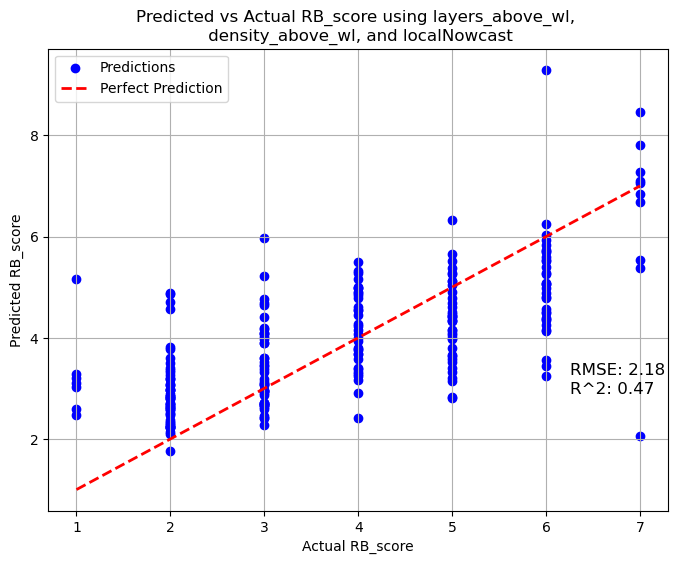

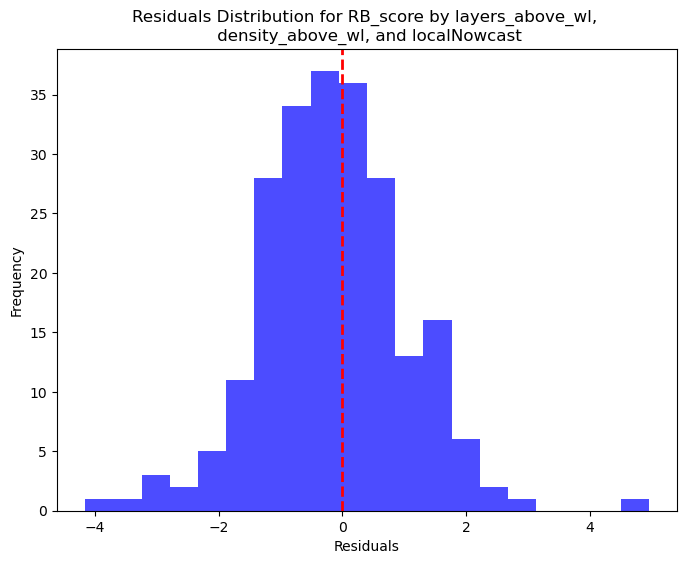

In [254]:
# Define predictor and target variables
predictor_var_layers = "layers_above_wl"
predictor_var_density = "density_above_wl"
predictor_var_localNowcast = "localNowcast"
target_var = "RB_score"

# Prepare the data for the smaller model (density_above_wl and localNowcast)
max_length_density = max(len(lst) for lst in df_raw[predictor_var_density])
X_density = np.array([lst + [0] * (max_length_density - len(lst)) for lst in df_raw[predictor_var_density]])
X_localNowcast = df_raw[predictor_var_localNowcast].values.reshape(-1, 1)
X_combined = np.hstack((X_density, X_localNowcast))  # Combine density and localNowcast

# Train-test split for the smaller model
X_combined_train, X_combined_test, y_train, y_test = train_test_split(X_combined, df_raw[target_var].values, test_size=0.3, random_state=36)

# Fit the smaller model (density_above_wl and localNowcast)
model_combined = LinearRegression().fit(X_combined_train, y_train)
y_pred_combined = model_combined.predict(X_combined_test)
rss_combined = np.sum((y_test - y_pred_combined) ** 2)

# Prepare the data for the full model (layers_above_wl, density_above_wl, and localNowcast)
max_length_layers = max(len(lst) for lst in df_raw[predictor_var_layers])
X_layers = np.array([lst + [0] * (max_length_layers - len(lst)) for lst in df_raw[predictor_var_layers]])
X_full = np.hstack((X_layers, X_density, X_localNowcast))  # Combine layers, density, and localNowcast

# Train-test split for the full model
X_full_train, X_full_test, y_train, y_test = train_test_split(X_full, df_raw[target_var].values, test_size=0.3, random_state=36)

# Fit the full model
model_full = LinearRegression().fit(X_full_train, y_train)
y_pred_full = model_full.predict(X_full_test)
rss_full = np.sum((y_test - y_pred_full) ** 2)

# Calculate F-statistic to compare the two models
p = X_full.shape[1] - X_combined.shape[1]  # Number of additional predictors
n = len(y_test)                              # Number of observations
k = X_full.shape[1]                          # Number of predictors in the full model

f_stat = ((rss_combined - rss_full) / p) / (rss_full / (n - k))
p_value = 1 - f.cdf(f_stat, p, n - k)
print(f'F-statistic: {f_stat}, p-value: {p_value}')

# Cross-validated RMSE for both models
cv_rmse_model_combined = np.mean(np.sqrt(-cross_val_score(model_combined, X_combined, df_raw[target_var].values, scoring='neg_mean_squared_error', cv=10)))
cv_rmse_model_full = np.mean(np.sqrt(-cross_val_score(model_full, X_full, df_raw[target_var].values, scoring='neg_mean_squared_error', cv=10)))

print(f'Cross-validated RMSE for model with {predictor_var_density} and {predictor_var_localNowcast}: {cv_rmse_model_combined}')
print(f'Cross-validated RMSE for model with {predictor_var_layers}, {predictor_var_density}, and {predictor_var_localNowcast}: {cv_rmse_model_full}')

# Plot Predicted vs Actual Values for the full model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_full, c='blue', marker='o', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title(f'Predicted vs Actual {target_var} using {predictor_var_layers}, \n {predictor_var_density}, and {predictor_var_localNowcast}')
plt.xlabel(f'Actual {target_var}')
plt.ylabel(f'Predicted {target_var}')
plt.legend()
plt.grid(True)

# Annotate RMSE and R^2 on the plot for full model
x_pos = y_test.min() + (7 / 8) * (y_test.max() - y_test.min())
y_pos = y_pred_full.min() + (1 / 5) * (y_pred_full.max() - y_pred_full.min())
plt.text(x_pos, y_pos, f'RMSE: {cv_rmse_model_full:.2f}', fontsize=12, color='black')
plt.text(x_pos, y_pos - (y_pred_full.max() - y_pred_full.min()) * 0.05, f'R^2: {r2_score(y_test, y_pred_full):.2f}', fontsize=12, color='black')

# Save and show the plot for full model
plt.savefig(os.path.join(output_dir_2, f"predicted_vs_actual_{target_var}_by_{predictor_var_layers}_and_{predictor_var_density}_and_{predictor_var_localNowcast}.png"))
plt.show()

# Plot Residuals Distribution for full model
residuals_full = y_test - y_pred_full
plt.figure(figsize=(8, 6))
plt.hist(residuals_full, bins=20, alpha=0.7, color='blue')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title(f'Residuals Distribution for {target_var} by {predictor_var_layers}, \n {predictor_var_density}, and {predictor_var_localNowcast}')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

# Save and show the residuals plot for full model
plt.savefig(os.path.join(output_dir_2, f"residuals_distribution_{target_var}_by_{predictor_var_layers}_and_{predictor_var_density}_and_{predictor_var_localNowcast}.png"))
plt.show()

In [ ]:
# Adding localNowcast was definetely an improvement, but trunc_density + trunc_layers + localNowcast outperforms with lower RMSE and higher R2

F-statistic (Three vs Two Inputs): 88.10983473621494, p-value: 1.1102230246251565e-16
Cross-validated RMSE for Two-Input Model (trunc_layers_above_wl and trunc_density_above_wl): 1.3598266824171528
Cross-validated RMSE for Three-Input Model (trunc_layers_above_wl, trunc_density_above_wl, and localNowcast): 1.1138590069950993


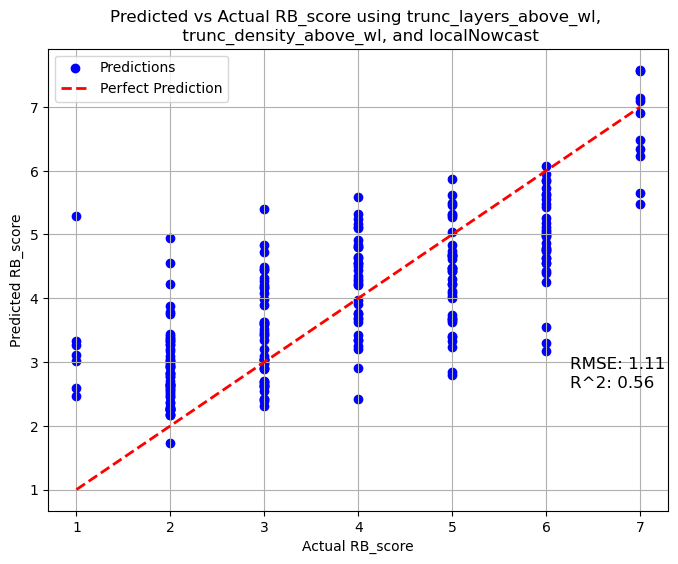

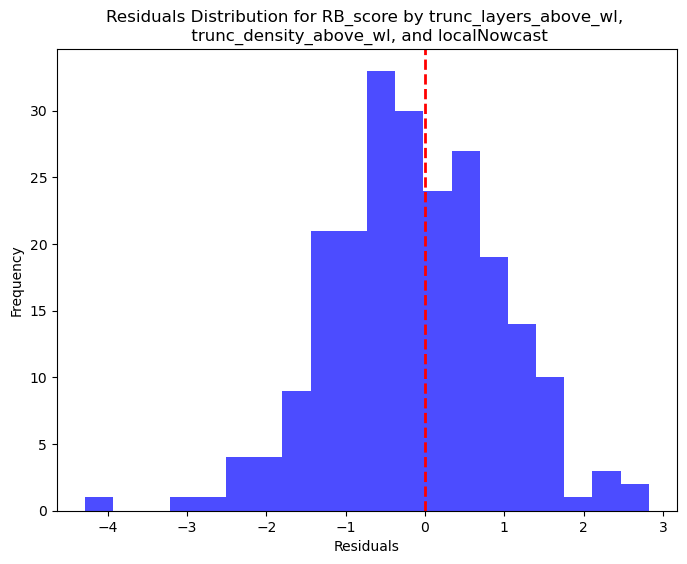

In [319]:
# Define predictor and target variables
predictor_var_trunc_layers = "trunc_layers_above_wl"
predictor_var_trunc_density = "trunc_density_above_wl"
predictor_var_localNowcast = "localNowcast"  # New predictor for this model
target_var = "RB_score"

# Determine maximum length for padding for truncated layers and density
max_length_trunc_layers = max(len(lst) for lst in df_raw[predictor_var_trunc_layers])
max_length_trunc_density = max(len(lst) for lst in df_raw[predictor_var_trunc_density])
max_length = max(max_length_trunc_layers, max_length_trunc_density)  # Consistent padding length

# Prepare the data for the two-input model (trunc_layers_above_wl and trunc_density_above_wl with padding)
X_trunc_layers_two_input = np.array([lst + [0] * (max_length - len(lst)) for lst in df_raw[predictor_var_trunc_layers]])
X_trunc_density_two_input = np.array([lst + [0] * (max_length - len(lst)) for lst in df_raw[predictor_var_trunc_density]])
X_combined_two_input = np.hstack((X_trunc_layers_two_input, X_trunc_density_two_input))  # Combine the two predictors

# Train-test split for the two-input model
X_two_input_train, X_two_input_test, y_train_two_input, y_test_two_input = train_test_split(
    X_combined_two_input, df_raw[target_var].values, test_size=0.3, random_state=36
)

# Fit the two-input model (trunc_layers_above_wl and trunc_density_above_wl)
model_two_input = LinearRegression().fit(X_two_input_train, y_train_two_input)
y_pred_two_input = model_two_input.predict(X_two_input_test)
rss_two_input_model = np.sum((y_test_two_input - y_pred_two_input) ** 2)  # Residual sum of squares for the two-input model

# Prepare the data for the three-input model (trunc_layers_above_wl, trunc_density_above_wl, and localNowcast with padding)
X_localNowcast_three_input = df_raw[predictor_var_localNowcast].values.reshape(-1, 1)  # localNowcast as a single column
X_combined_three_input = np.hstack((X_combined_two_input, X_localNowcast_three_input))  # Combine all three predictors

# Train-test split for the three-input model
X_three_input_train, X_three_input_test, y_train_three_input, y_test_three_input = train_test_split(
    X_combined_three_input, df_raw[target_var].values, test_size=0.3, random_state=36
)

# Fit the three-input model (trunc_layers_above_wl, trunc_density_above_wl, and localNowcast)
model_three_input = LinearRegression().fit(X_three_input_train, y_train_three_input)
y_pred_three_input = model_three_input.predict(X_three_input_test)
rss_three_input_model = np.sum((y_test_three_input - y_pred_three_input) ** 2)  # Residual sum of squares for the three-input model

# Calculate F-statistic to compare the two-input and three-input models
p_three_vs_two = X_combined_three_input.shape[1] - X_combined_two_input.shape[1]  # Number of additional predictors (1 in this case)
n_three_vs_two = len(y_test_three_input)                                          # Number of observations
k_three_vs_two = X_combined_three_input.shape[1]                                  # Total number of predictors in the three-input model

f_stat_three_vs_two = ((rss_two_input_model - rss_three_input_model) / p_three_vs_two) / (
    rss_three_input_model / (n_three_vs_two - k_three_vs_two)
)
p_value_three_vs_two = 1 - f.cdf(f_stat_three_vs_two, p_three_vs_two, n_three_vs_two - k_three_vs_two)
print(f'F-statistic (Three vs Two Inputs): {f_stat_three_vs_two}, p-value: {p_value_three_vs_two}')

# Cross-validated RMSE for both models
cv_rmse_two_input_model = np.mean(np.sqrt(-cross_val_score(
    model_two_input, X_combined_two_input, df_raw[target_var].values, scoring='neg_mean_squared_error', cv=10
)))
cv_rmse_three_input_model = np.mean(np.sqrt(-cross_val_score(
    model_three_input, X_combined_three_input, df_raw[target_var].values, scoring='neg_mean_squared_error', cv=10
)))

print(f'Cross-validated RMSE for Two-Input Model ({predictor_var_trunc_layers} and {predictor_var_trunc_density}): {cv_rmse_two_input_model}')
print(f'Cross-validated RMSE for Three-Input Model ({predictor_var_trunc_layers}, {predictor_var_trunc_density}, and {predictor_var_localNowcast}): {cv_rmse_three_input_model}')

# Plot Predicted vs Actual Values for the three-input model
plt.figure(figsize=(8, 6))
plt.scatter(y_test_three_input, y_pred_three_input, c='blue', marker='o', label='Predictions')
plt.plot([y_test_three_input.min(), y_test_three_input.max()], [y_test_three_input.min(), y_test_three_input.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title(f'Predicted vs Actual {target_var} using {predictor_var_trunc_layers}, \n {predictor_var_trunc_density}, and {predictor_var_localNowcast}')
plt.xlabel(f'Actual {target_var}')
plt.ylabel(f'Predicted {target_var}')
plt.legend()
plt.grid(True)

# Annotate RMSE and R^2 on the plot for the three-input model
x_pos = y_test_three_input.min() + (7 / 8) * (y_test_three_input.max() - y_test_three_input.min())
y_pos = y_pred_three_input.min() + (1 / 5) * (y_pred_three_input.max() - y_pred_three_input.min())
plt.text(x_pos, y_pos, f'RMSE: {cv_rmse_three_input_model:.2f}', fontsize=12, color='black')
plt.text(x_pos, y_pos - (y_pred_three_input.max() - y_pred_three_input.min()) * 0.05, f'R^2: {r2_score(y_test_three_input, y_pred_three_input):.2f}', fontsize=12, color='black')

# Save and show the plot for the three-input model
plt.savefig(os.path.join(output_dir_2, f"predicted_vs_actual_{target_var}_by_{predictor_var_trunc_layers}_{predictor_var_trunc_density}_{predictor_var_localNowcast}.png"))
plt.show()

# Plot Residuals Distribution for the three-input model
residuals_three_input_model = y_test_three_input - y_pred_three_input
plt.figure(figsize=(8, 6))
plt.hist(residuals_three_input_model, bins=20, alpha=0.7, color='blue')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title(f"Residuals Distribution for {target_var} by {predictor_var_trunc_layers}, \n {predictor_var_trunc_density}, and {predictor_var_localNowcast}")
plt.xlabel('Residuals')
plt.ylabel('Frequency')

# Save and show the residuals plot for the three-input model
plt.savefig(os.path.join(output_dir_2, f"residuals_distribution_{target_var}_by_{predictor_var_trunc_layers}_{predictor_var_trunc_density}_{predictor_var_localNowcast}.png"))
plt.show()


F-statistic: 0.6708245208331123, p-value: 0.413688397582323
Cross-validated RMSE for model with trunc_layers_above_wl, trunc_density_above_wl, and localNowcast: 1.1138590069950993
Cross-validated RMSE for model with trunc_layers_above_wl, trunc_density_above_wl, localNowcast, and slopeangle: 1.1087810199328805


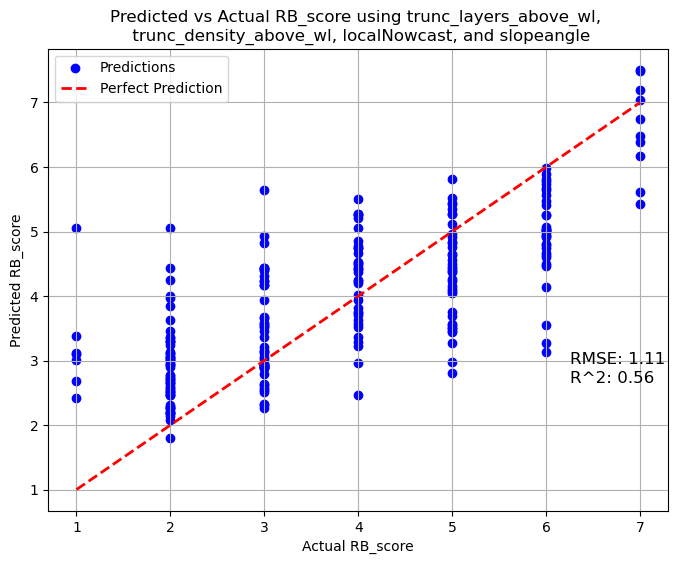

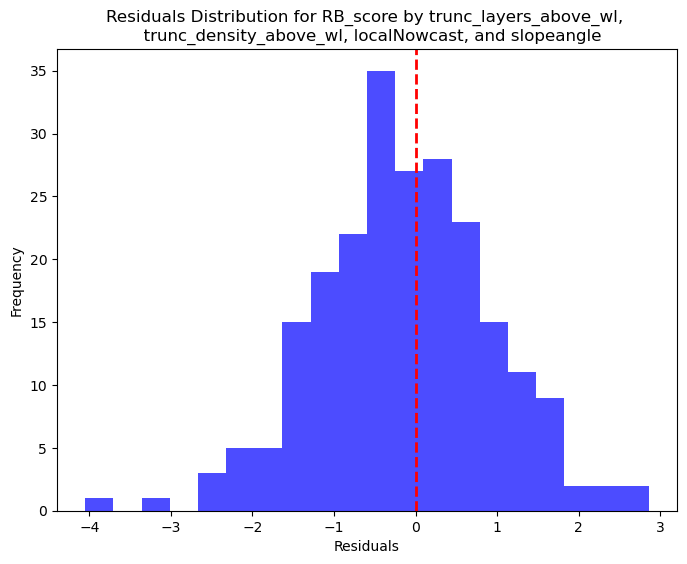

In [257]:
# Define predictor and target variables
predictor_var_trunc_density = "trunc_density_above_wl"
predictor_var_trunc_layers = "trunc_layers_above_wl"
predictor_var_localNowcast = "localNowcast"
predictor_var_slope = "slopeangle"  # New additional predictor for four-input model
target_var = "RB_score"

# Determine maximum length for padding for truncated layers and density
max_length_trunc_layers = max(len(lst) for lst in df_raw[predictor_var_trunc_layers])
max_length_trunc_density = max(len(lst) for lst in df_raw[predictor_var_trunc_density])
max_length = max(max_length_trunc_layers, max_length_trunc_density)  # Use the longer length for padding consistency

# Prepare the data for the three-input model (trunc_layers_above_wl, trunc_density_above_wl, and localNowcast)
X_trunc_layers = np.array([lst + [0] * (max_length - len(lst)) for lst in df_raw[predictor_var_trunc_layers]])
X_trunc_density = np.array([lst + [0] * (max_length - len(lst)) for lst in df_raw[predictor_var_trunc_density]])
X_localNowcast = df_raw[predictor_var_localNowcast].values.reshape(-1, 1)  # localNowcast as a single column
X_combined_three = np.hstack((X_trunc_layers, X_trunc_density, X_localNowcast))  # Combine three predictors

# Train-test split for the three-input model
X_combined_three_train, X_combined_three_test, y_train, y_test = train_test_split(X_combined_three, df_raw[target_var].values, test_size=0.3, random_state=36)

# Fit the three-input model
model_three_input = LinearRegression().fit(X_combined_three_train, y_train)
y_pred_three_input = model_three_input.predict(X_combined_three_test)
rss_three_input = np.sum((y_test - y_pred_three_input) ** 2)  # Residual sum of squares for the three-input model

# Prepare the data for the four-input model (trunc_layers_above_wl, trunc_density_above_wl, localNowcast, and slopeangle)
X_slope = df_raw[predictor_var_slope].values.reshape(-1, 1)  # slopeangle as a single column
X_combined_four = np.hstack((X_trunc_layers, X_trunc_density, X_localNowcast, X_slope))  # Combine four predictors

# Train-test split for the four-input model
X_combined_four_train, X_combined_four_test, y_train, y_test = train_test_split(X_combined_four, df_raw[target_var].values, test_size=0.3, random_state=36)

# Fit the four-input model
model_four_input = LinearRegression().fit(X_combined_four_train, y_train)
y_pred_four_input = model_four_input.predict(X_combined_four_test)
rss_four_input = np.sum((y_test - y_pred_four_input) ** 2)  # Residual sum of squares for the four-input model

# Calculate F-statistic to compare the three-input and four-input models
p = X_combined_four.shape[1] - X_combined_three.shape[1]  # Number of additional predictors (1 in this case)
n = len(y_test)                                           # Number of observations
k = X_combined_four.shape[1]                              # Total number of predictors in the four-input model

f_stat = ((rss_three_input - rss_four_input) / p) / (rss_four_input / (n - k))
p_value = 1 - f.cdf(f_stat, p, n - k)
print(f'F-statistic: {f_stat}, p-value: {p_value}')

# Cross-validated RMSE for both models
cv_rmse_model_three_input = np.mean(np.sqrt(-cross_val_score(model_three_input, X_combined_three, df_raw[target_var].values, scoring='neg_mean_squared_error', cv=10)))
cv_rmse_model_four_input = np.mean(np.sqrt(-cross_val_score(model_four_input, X_combined_four, df_raw[target_var].values, scoring='neg_mean_squared_error', cv=10)))

print(f'Cross-validated RMSE for model with {predictor_var_trunc_layers}, {predictor_var_trunc_density}, and {predictor_var_localNowcast}: {cv_rmse_model_three_input}')
print(f'Cross-validated RMSE for model with {predictor_var_trunc_layers}, {predictor_var_trunc_density}, {predictor_var_localNowcast}, and {predictor_var_slope}: {cv_rmse_model_four_input}')

# Plot Predicted vs Actual Values for the four-input model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_four_input, c='blue', marker='o', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title(f'Predicted vs Actual {target_var} using {predictor_var_trunc_layers}, \n {predictor_var_trunc_density}, {predictor_var_localNowcast}, and {predictor_var_slope}')
plt.xlabel(f'Actual {target_var}')
plt.ylabel(f'Predicted {target_var}')
plt.legend()
plt.grid(True)

# Annotate RMSE and R^2 on the plot for four-input model
x_pos = y_test.min() + (7 / 8) * (y_test.max() - y_test.min())
y_pos = y_pred_four_input.min() + (1 / 5) * (y_pred_four_input.max() - y_pred_four_input.min())
plt.text(x_pos, y_pos, f'RMSE: {cv_rmse_model_four_input:.2f}', fontsize=12, color='black')
plt.text(x_pos, y_pos - (y_pred_four_input.max() - y_pred_four_input.min()) * 0.05, f'R^2: {r2_score(y_test, y_pred_four_input):.2f}', fontsize=12, color='black')

# Save and show the plot for four-input model
plt.savefig(os.path.join(output_dir_2, f"predicted_vs_actual_{target_var}_by_{predictor_var_trunc_layers}_{predictor_var_trunc_density}_{predictor_var_localNowcast}_{predictor_var_slope}.png"))
plt.show()

# Plot Residuals Distribution for four-input model
residuals_four_input = y_test - y_pred_four_input
plt.figure(figsize=(8, 6))
plt.hist(residuals_four_input, bins=20, alpha=0.7, color='blue')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title(f'Residuals Distribution for {target_var} by {predictor_var_trunc_layers}, \n  {predictor_var_trunc_density}, {predictor_var_localNowcast}, and {predictor_var_slope}')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

# Save and show the residuals plot for four-input model
plt.savefig(os.path.join(output_dir_2, f"residuals_distribution_{target_var}_by_{predictor_var_trunc_layers}_{predictor_var_trunc_density}_{predictor_var_localNowcast}_{predictor_var_slope}.png"))
plt.show()

In [224]:
# Adding slopeangle is not significant, so we try to reduce to a simpler model and see if the bigger model is significantly better than the big one

Cross-validated RMSE for model with trunc_density_above_wl and localNowcast: 1.1688367319241675


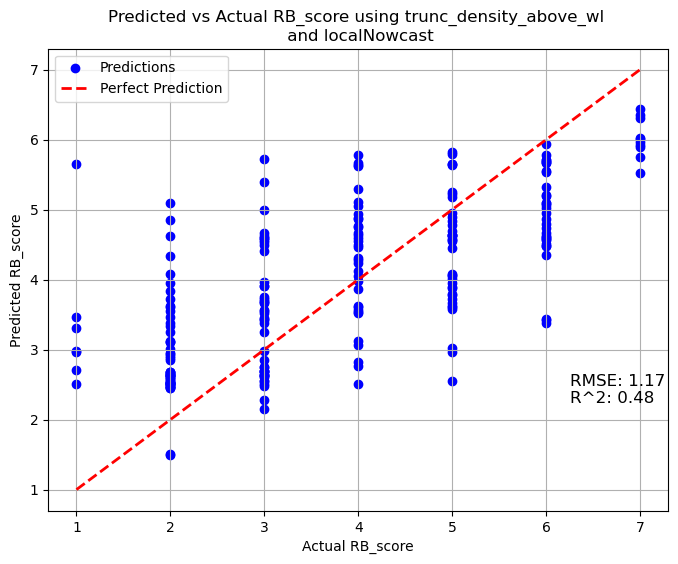

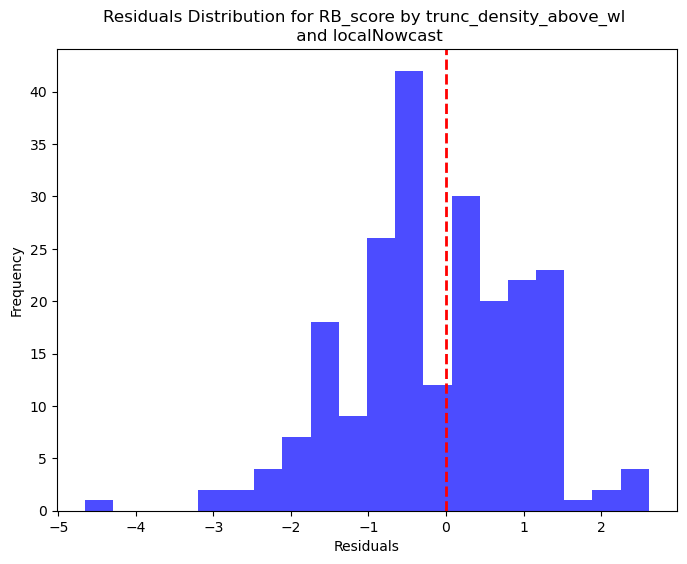

In [277]:
# Define predictor and target variables
predictor_var_trunc_density = "trunc_density_above_wl"
predictor_var_localNowcast = "localNowcast"
target_var = "RB_score"

# Determine maximum length for padding for truncated density
max_length_trunc_density = max(len(lst) for lst in df_raw[predictor_var_trunc_density])

# Prepare the data for the smaller model (trunc_density_above_wl and localNowcast with padding)
X_trunc_density = np.array([lst + [0] * (max_length_trunc_density - len(lst)) for lst in df_raw[predictor_var_trunc_density]])
X_localNowcast = df_raw[predictor_var_localNowcast].values.reshape(-1, 1)  # localNowcast as a single column
X_combined_two = np.hstack((X_trunc_density, X_localNowcast))  # Combine the two predictors

# Train-test split for the smaller (two-input) model
X_combined_two_train, X_combined_two_test, y_train, y_test = train_test_split(X_combined_two, df_raw[target_var].values, test_size=0.3, random_state=36)

# Fit the two-input model
model_two_input = LinearRegression().fit(X_combined_two_train, y_train)
y_pred_two_input = model_two_input.predict(X_combined_two_test)
rss_two_input = np.sum((y_test - y_pred_two_input) ** 2)  # Residual sum of squares for the two-input model

# Cross-validated RMSE for the smaller model
cv_rmse_model_two_input = np.mean(np.sqrt(-cross_val_score(model_two_input, X_combined_two, df_raw[target_var].values, scoring='neg_mean_squared_error', cv=10)))

print(f'Cross-validated RMSE for model with {predictor_var_trunc_density} and {predictor_var_localNowcast}: {cv_rmse_model_two_input}')

# Plot Predicted vs Actual Values for the two-input model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_two_input, c='blue', marker='o', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title(f'Predicted vs Actual {target_var} using {predictor_var_trunc_density} \n and {predictor_var_localNowcast}')
plt.xlabel(f'Actual {target_var}')
plt.ylabel(f'Predicted {target_var}')
plt.legend()
plt.grid(True)

# Annotate RMSE and R^2 on the plot for two-input model
x_pos = y_test.min() + (7 / 8) * (y_test.max() - y_test.min())
y_pos = y_pred_two_input.min() + (1 / 5) * (y_pred_two_input.max() - y_pred_two_input.min())
plt.text(x_pos, y_pos, f'RMSE: {cv_rmse_model_two_input:.2f}', fontsize=12, color='black')
plt.text(x_pos, y_pos - (y_pred_two_input.max() - y_pred_two_input.min()) * 0.05, f'R^2: {r2_score(y_test, y_pred_two_input):.2f}', fontsize=12, color='black')

# Save and show the plot for two-input model
plt.savefig(os.path.join(output_dir_2, f"predicted_vs_actual_{target_var}_by_{predictor_var_trunc_density}_{predictor_var_localNowcast}.png"))
plt.show()

# Plot Residuals Distribution for two-input model
residuals_two_input = y_test - y_pred_two_input
plt.figure(figsize=(8, 6))
plt.hist(residuals_two_input, bins=20, alpha=0.7, color='blue')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title(f'Residuals Distribution for {target_var} by {predictor_var_trunc_density} \n and {predictor_var_localNowcast}')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

# Save and show the residuals plot for two-input model
plt.savefig(os.path.join(output_dir_2, f"residuals_distribution_{target_var}_by_{predictor_var_trunc_density}_{predictor_var_localNowcast}.png"))
plt.show()

In [278]:
## Although unlikely, we proceed to check using only localNowcast

F-statistic: 7.963209810651472, p-value: 8.913707694180317e-08
Cross-validated RMSE for model with only localNowcast: 1.280271261542725
Cross-validated RMSE for model with localNowcast and trunc_density_above_wl: 1.1688367319241677


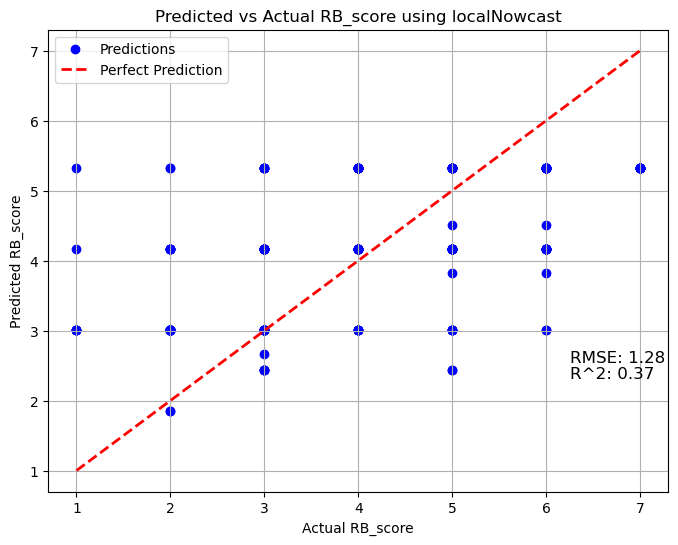

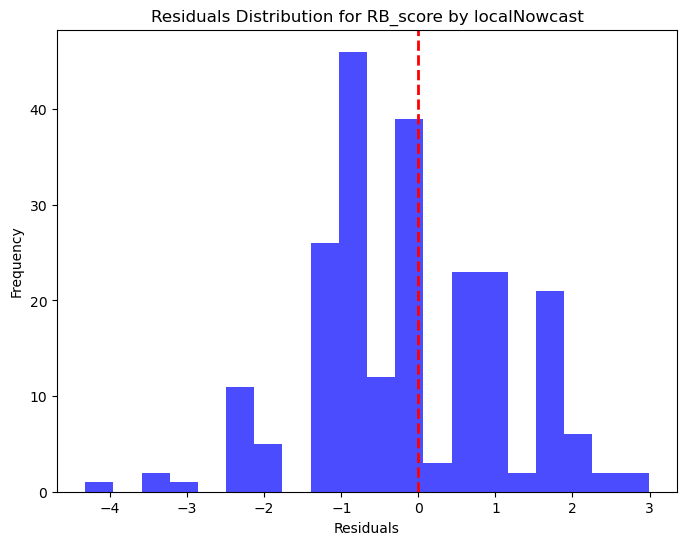

In [279]:
# Define predictor and target variables
predictor_var_localNowcast = "localNowcast"
predictor_var_trunc_density = "trunc_density_above_wl"  # Predictor for the two-input model
target_var = "RB_score"

# Prepare the data for the single-input model (only localNowcast)
X_localNowcast = df_raw[predictor_var_localNowcast].values.reshape(-1, 1)  # localNowcast as a single column
X_localNowcast_train, X_localNowcast_test, y_train, y_test = train_test_split(X_localNowcast, df_raw[target_var].values, test_size=0.3, random_state=36)

# Fit the single-input model (only localNowcast)
model_single = LinearRegression().fit(X_localNowcast_train, y_train)
y_pred_single = model_single.predict(X_localNowcast_test)
rss_single = np.sum((y_test - y_pred_single) ** 2)  # Residual sum of squares for the single-input model

# Determine maximum length for padding for trunc_density_above_wl
max_length_trunc_density = max(len(lst) for lst in df_raw[predictor_var_trunc_density])

# Prepare the data for the two-input model (localNowcast and trunc_density_above_wl with padding)
X_trunc_density = np.array([lst + [0] * (max_length_trunc_density - len(lst)) for lst in df_raw[predictor_var_trunc_density]])
X_combined_two = np.hstack((X_localNowcast, X_trunc_density))  # Combine the two predictors

# Train-test split for the two-input model
X_combined_two_train, X_combined_two_test, y_train, y_test = train_test_split(X_combined_two, df_raw[target_var].values, test_size=0.3, random_state=36)

# Fit the two-input model (localNowcast and trunc_density_above_wl)
model_two_input = LinearRegression().fit(X_combined_two_train, y_train)
y_pred_two_input = model_two_input.predict(X_combined_two_test)
rss_two_input = np.sum((y_test - y_pred_two_input) ** 2)  # Residual sum of squares for the two-input model

# Calculate F-statistic to compare the single-input and two-input models
p = X_combined_two.shape[1] - X_localNowcast.shape[1]  # Number of additional predictors (1 in this case)
n = len(y_test)                                       # Number of observations
k = X_combined_two.shape[1]                           # Total number of predictors in the two-input model

f_stat = ((rss_single - rss_two_input) / p) / (rss_two_input / (n - k))
p_value = 1 - f.cdf(f_stat, p, n - k)
print(f'F-statistic: {f_stat}, p-value: {p_value}')

# Cross-validated RMSE for both models
cv_rmse_model_single = np.mean(np.sqrt(-cross_val_score(model_single, X_localNowcast, df_raw[target_var].values, scoring='neg_mean_squared_error', cv=10)))
cv_rmse_model_two_input = np.mean(np.sqrt(-cross_val_score(model_two_input, X_combined_two, df_raw[target_var].values, scoring='neg_mean_squared_error', cv=10)))

print(f'Cross-validated RMSE for model with only {predictor_var_localNowcast}: {cv_rmse_model_single}')
print(f'Cross-validated RMSE for model with {predictor_var_localNowcast} and {predictor_var_trunc_density}: {cv_rmse_model_two_input}')

# Plot Predicted vs Actual Values for the single-input model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_single, c='blue', marker='o', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title(f'Predicted vs Actual {target_var} using {predictor_var_localNowcast}')
plt.xlabel(f'Actual {target_var}')
plt.ylabel(f'Predicted {target_var}')
plt.legend()
plt.grid(True)

# Annotate RMSE and R^2 on the plot for the single-input model
x_pos = y_test.min() + (7 / 8) * (y_test.max() - y_test.min())
y_pos = y_pred_single.min() + (1 / 5) * (y_pred_single.max() - y_pred_single.min())
plt.text(x_pos, y_pos, f'RMSE: {cv_rmse_model_single:.2f}', fontsize=12, color='black')
plt.text(x_pos, y_pos * 0.91, f'R^2: {r2_score(y_test, y_pred_single):.2f}', fontsize=12, color='black')

# Save and show the plot for the single-input model
plt.savefig(os.path.join(output_dir_2, f"predicted_vs_actual_{target_var}_by_{predictor_var_localNowcast}.png"))
plt.show()

# Plot Residuals Distribution for the single-input model
residuals_single = y_test - y_pred_single
plt.figure(figsize=(8, 6))
plt.hist(residuals_single, bins=20, alpha=0.7, color='blue')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title(f'Residuals Distribution for {target_var} by {predictor_var_localNowcast}')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

# Save and show the residuals plot for the single-input model
plt.savefig(os.path.join(output_dir_2, f"residuals_distribution_{target_var}_by_{predictor_var_localNowcast}.png"))
plt.show()

In [229]:
# We can thus conclude that the model using localNowcast, trunc_layers and trunc_density is the significantly determined best model

In [ ]:
# As we have now finished modelling of the full scale RB score 1-7, we would like to compare the two best performing models from each class


# Full length: best performance by localNowcast + density

# Truncated length: best performance by localNowcast + density + 

In [324]:
from scipy.stats import ttest_rel

# Step 1: Cross-validation RMSE for density + localNowcast model
cv_rmse_density_localNowcast = -cross_val_score(model_combined_unique, X_combined_unique, df_raw[target_var_unique].values, scoring='neg_mean_squared_error', cv=10)
cv_rmse_density_localNowcast = np.sqrt(-cv_rmse_density_localNowcast)

# Step 2: Cross-validation RMSE for trunc_density + trunc_layers + localNowcast model
cv_rmse_trunc_layers_density_localNowcast = -cross_val_score(
    model_three_input, X_combined_three_input, df_raw[target_var_unique].values, scoring='neg_mean_squared_error', cv=10
)
cv_rmse_trunc_layers_density_localNowcast = np.sqrt(-cv_rmse_trunc_layers_density_localNowcast)

# Step 3: Paired t-Test for RMSE
t_stat, p_value = ttest_rel(cv_rmse_density_localNowcast, cv_rmse_trunc_layers_density_localNowcast)
print(f"Paired t-test results: t-statistic = {t_stat:.3f}, p-value = {p_value:.3f}")

if p_value < 0.05:
    print("The difference in model performance is statistically significant.")
else:
    print("No significant difference in model performance.")

# Step 4: AIC/BIC Comparison
def calculate_aic(rss, n, k):
    return n * np.log(rss / n) + 2 * k

def calculate_bic(rss, n, k):
    return n * np.log(rss / n) + k * np.log(n)

# Calculate AIC/BIC for density + localNowcast model
aic_density_localNowcast = calculate_aic(rss_combined_unique, len(y_test_combined_unique), X_combined_unique.shape[1])
bic_density_localNowcast = calculate_bic(rss_combined_unique, len(y_test_combined_unique), X_combined_unique.shape[1])

# Calculate AIC/BIC for trunc_density + trunc_layers + localNowcast model
aic_trunc_layers_density_localNowcast = calculate_aic(rss_three_input_model, len(y_test_three_input), X_combined_three_input.shape[1])
bic_trunc_layers_density_localNowcast = calculate_bic(rss_three_input_model, len(y_test_three_input), X_combined_three_input.shape[1])

print(f"AIC for Density + LocalNowcast Model: {aic_density_localNowcast:.2f}")
print(f"BIC for Density + LocalNowcast Model: {bic_density_localNowcast:.2f}")
print(f"AIC for Trunc_Density + Trunc_Layers + LocalNowcast Model: {aic_trunc_layers_density_localNowcast:.2f}")
print(f"BIC for Trunc_Density + Trunc_Layers + LocalNowcast Model: {bic_trunc_layers_density_localNowcast:.2f}")


Paired t-test results: t-statistic = nan, p-value = nan
No significant difference in model performance.
AIC for Density + LocalNowcast Model: 105.27
BIC for Density + LocalNowcast Model: 173.60
AIC for Trunc_Density + Trunc_Layers + LocalNowcast Model: 58.39
BIC for Trunc_Density + Trunc_Layers + LocalNowcast Model: 102.80


/var/folders/qg/62g5vkys0fn7v7yj0yy0sp780000gn/T/ipykernel_7469/2071126611.py:5: RuntimeWarning: invalid value encountered in sqrt
  cv_rmse_density_localNowcast = np.sqrt(-cv_rmse_density_localNowcast)
/var/folders/qg/62g5vkys0fn7v7yj0yy0sp780000gn/T/ipykernel_7469/2071126611.py:11: RuntimeWarning: invalid value encountered in sqrt
  cv_rmse_trunc_layers_density_localNowcast = np.sqrt(-cv_rmse_trunc_layers_density_localNowcast)


In [ ]:
# THIS NEEDS TO BE VALIDATED

In [329]:
# Extract Confidence Intervals for Density + LocalNowcast model
ci_combined = pd.DataFrame(
    model_combined_sm.conf_int(alpha=0.05),
    columns=['Lower Bound', 'Upper Bound']
)
ci_combined.index = ['Intercept'] + [f"Feature {i+1}" for i in range(X_combined_unique.shape[1])]

# Extract Confidence Intervals for Trunc_Density + Trunc_Layers + LocalNowcast model
ci_three = pd.DataFrame(
    model_three_sm.conf_int(alpha=0.05),
    columns=['Lower Bound', 'Upper Bound']
)
ci_three.index = ['Intercept'] + [f"Feature {i+1}" for i in range(X_combined_three_input.shape[1])]

# Display Confidence Intervals
print("Confidence Intervals for Density + LocalNowcast Model:")
print(ci_combined)

print("\nConfidence Intervals for Trunc_Density + Trunc_Layers + LocalNowcast Model:")
print(ci_three)

Confidence Intervals for Density + LocalNowcast Model:
            Lower Bound  Upper Bound
Intercept      4.663800     5.554605
Feature 1     -0.000387     0.002665
Feature 2     -0.000642     0.002198
Feature 3     -0.000925     0.001698
Feature 4      0.000420     0.003309
Feature 5      0.000179     0.003238
Feature 6     -0.001562     0.001766
Feature 7     -0.002867     0.001163
Feature 8      0.000256     0.004969
Feature 9     -0.000836     0.004298
Feature 10    -0.004186     0.001653
Feature 11    -0.002867     0.003828
Feature 12    -0.001550     0.007230
Feature 13    -0.005162     0.006065
Feature 14    -0.008667     0.010177
Feature 15    -0.007528     0.006559
Feature 16    -0.031154     0.006547
Feature 17    -0.017196     0.005936
Feature 18    -0.029220     0.060931
Feature 19    -0.004612     0.015923
Feature 20    -1.055635    -0.847429

Confidence Intervals for Trunc_Density + Trunc_Layers + LocalNowcast Model:
            Lower Bound  Upper Bound
Intercept      4.

In [280]:
# We are now trying to predict a grouped version of the RB scores into four distinct categories

# Define and create the new output directory for the fourth segment
output_dir_4 = os.path.join(os.getcwd(), "CN_thesis_plots", "4_RB_score_grouped_4")
os.makedirs(output_dir_4, exist_ok=True)  # Ensure the directory exists

Cross-validated RMSE for model with only localNowcast: 0.7400908243388773
F-statistic: 2.399255164103499, p-value: 0.0013690050242305407
Cross-validated RMSE for model with localNowcast and density_above_wl: 0.6692510467067733


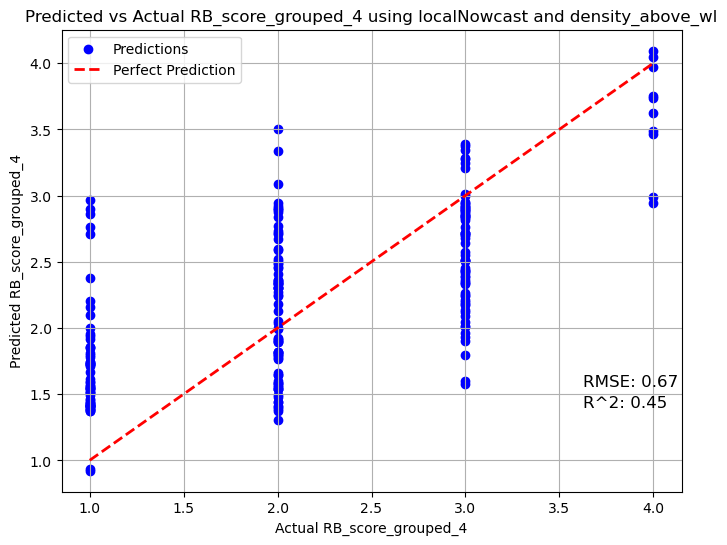

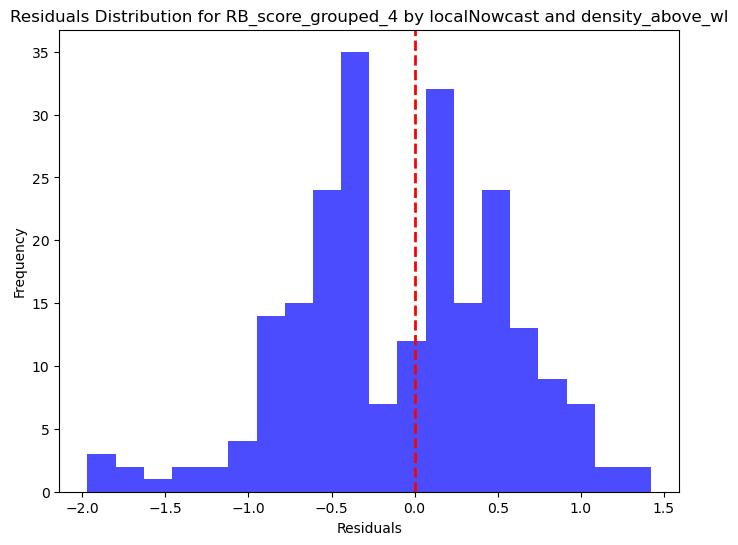

In [281]:
# Define predictor and target variables
predictor_var_localNowcast = "localNowcast"
predictor_var_density = "density_above_wl"  # New predictor for the two-input model
target_var_grouped = "RB_score_grouped_4"  # Target variable

# Train-test split for the single-input model
X_train_single, X_test_single, y_train, y_test = train_test_split(X_localNowcast, y_grouped, test_size=0.3, random_state=36)

# Fit the single-input model (only localNowcast)
model_single = LinearRegression().fit(X_train_single, y_train)
y_pred_single = model_single.predict(X_test_single)
rss_single = np.sum((y_test - y_pred_single) ** 2)

# Cross-validated RMSE for the single-input model
cv_rmse_single = np.mean(np.sqrt(-cross_val_score(model_single, X_localNowcast, y_grouped, scoring='neg_mean_squared_error', cv=10)))
print(f'Cross-validated RMSE for model with only {predictor_var_localNowcast}: {cv_rmse_single}')

# Determine maximum length for padding for density_above_wl
max_length_density = max(len(lst) for lst in df_raw[predictor_var_density])

# Prepare the data for the two-input model (localNowcast and density_above_wl with padding)
X_density = np.array([lst + [0] * (max_length_density - len(lst)) for lst in df_raw[predictor_var_density]])
X_combined_two = np.hstack((X_localNowcast, X_density))

# Train-test split for the two-input model
X_train_two, X_test_two, y_train, y_test = train_test_split(X_combined_two, y_grouped, test_size=0.3, random_state=36)

# Fit the two-input model (localNowcast and density_above_wl)
model_two = LinearRegression().fit(X_train_two, y_train)
y_pred_two = model_two.predict(X_test_two)
rss_two = np.sum((y_test - y_pred_two) ** 2)

# Calculate F-statistic to compare the single-input and two-input models
p = X_combined_two.shape[1] - X_localNowcast.shape[1]  # Number of additional predictors (1 in this case)
n = len(y_test)                                       # Number of observations
k = X_combined_two.shape[1]                           # Total number of predictors in the two-input model

f_stat = ((rss_single - rss_two) / p) / (rss_two / (n - k))
p_value = 1 - f.cdf(f_stat, p, n - k)
print(f'F-statistic: {f_stat}, p-value: {p_value}')

# Cross-validated RMSE for the two-input model
cv_rmse_two = np.mean(np.sqrt(-cross_val_score(model_two, X_combined_two, y_grouped, scoring='neg_mean_squared_error', cv=10)))
print(f'Cross-validated RMSE for model with {predictor_var_localNowcast} and {predictor_var_density}: {cv_rmse_two}')

# Plot Predicted vs Actual Values for the two-input model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_two, c='blue', marker='o', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title(f'Predicted vs Actual {target_var_grouped} using {predictor_var_localNowcast} and {predictor_var_density}')
plt.xlabel(f'Actual {target_var_grouped}')
plt.ylabel(f'Predicted {target_var_grouped}')
plt.legend()
plt.grid(True)

# Annotate RMSE and R^2 on the plot for two-input model
x_pos = y_test.min() + (7 / 8) * (y_test.max() - y_test.min())
y_pos = y_pred_two.min() + (1 / 5) * (y_pred_two.max() - y_pred_two.min())
plt.text(x_pos, y_pos, f'RMSE: {cv_rmse_two:.2f}', fontsize=12, color='black')
plt.text(x_pos, y_pos - (y_pred_two.max() - y_pred_two.min()) * 0.05, f'R^2: {r2_score(y_test, y_pred_two):.2f}', fontsize=12, color='black')

# Save and show the plot for two-input model
plt.savefig(os.path.join(output_dir_4, f"predicted_vs_actual_{target_var_grouped}_by_{predictor_var_localNowcast}_{predictor_var_density}.png"))
plt.show()

# Plot Residuals Distribution for two-input model
residuals_two = y_test - y_pred_two
plt.figure(figsize=(8, 6))
plt.hist(residuals_two, bins=20, alpha=0.7, color='blue')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title(f'Residuals Distribution for {target_var_grouped} by {predictor_var_localNowcast} and {predictor_var_density}')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

# Save and show the residuals plot for two-input model
plt.savefig(os.path.join(output_dir_4, f"residuals_distribution_{target_var_grouped}_by_{predictor_var_localNowcast}_{predictor_var_density}.png"))
plt.show()

Cross-validated RMSE for model with localNowcast and density_above_wl: 0.6692510467067733
F-statistic: -0.21868535274744547, p-value: 1.0
Cross-validated RMSE for model with localNowcast, density_above_wl, and layers_above_wl: 1.1846130539169404


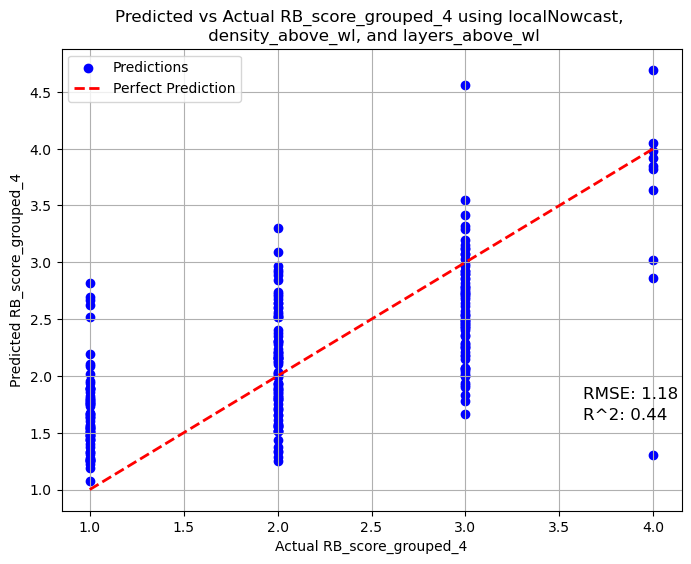

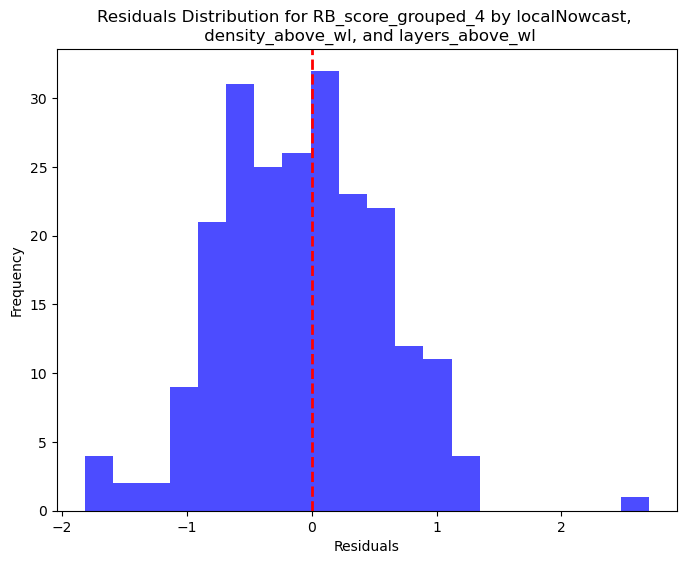

In [282]:
# Define predictor and target variables
predictor_var_localNowcast = "localNowcast"
predictor_var_density = "density_above_wl"
predictor_var_layers = "layers_above_wl"  # New predictor for the three-input model
target_var_grouped = "RB_score_grouped_4"

# Prepare the data for the two-input model (localNowcast and density_above_wl with padding)
X_localNowcast = df_raw[predictor_var_localNowcast].values.reshape(-1, 1)
y_grouped = df_raw[target_var_grouped].values

max_length_density = max(len(lst) for lst in df_raw[predictor_var_density])
X_density = np.array([lst + [0] * (max_length_density - len(lst)) for lst in df_raw[predictor_var_density]])
X_combined_two = np.hstack((X_localNowcast, X_density))

# Train-test split for the two-input model
X_train_two, X_test_two, y_train, y_test = train_test_split(X_combined_two, y_grouped, test_size=0.3, random_state=36)

# Fit the two-input model (localNowcast and density_above_wl)
model_two = LinearRegression().fit(X_train_two, y_train)
y_pred_two = model_two.predict(X_test_two)
rss_two = np.sum((y_test - y_pred_two) ** 2)

# Cross-validated RMSE for the two-input model
cv_rmse_two = np.mean(np.sqrt(-cross_val_score(model_two, X_combined_two, y_grouped, scoring='neg_mean_squared_error', cv=10)))
print(f'Cross-validated RMSE for model with {predictor_var_localNowcast} and {predictor_var_density}: {cv_rmse_two}')

# Prepare the data for the three-input model (localNowcast, density_above_wl, and layers_above_wl with padding)
max_length_layers = max(len(lst) for lst in df_raw[predictor_var_layers])
X_layers = np.array([lst + [0] * (max_length_layers - len(lst)) for lst in df_raw[predictor_var_layers]])
X_combined_three = np.hstack((X_localNowcast, X_density, X_layers))

# Train-test split for the three-input model
X_train_three, X_test_three, y_train, y_test = train_test_split(X_combined_three, y_grouped, test_size=0.3, random_state=36)

# Fit the three-input model (localNowcast, density_above_wl, and layers_above_wl)
model_three = LinearRegression().fit(X_train_three, y_train)
y_pred_three = model_three.predict(X_test_three)
rss_three = np.sum((y_test - y_pred_three) ** 2)

# Calculate F-statistic to compare the two-input and three-input models
p = X_combined_three.shape[1] - X_combined_two.shape[1]  # Number of additional predictors (1 in this case)
n = len(y_test)                                         # Number of observations
k = X_combined_three.shape[1]                           # Total number of predictors in the three-input model

f_stat = ((rss_two - rss_three) / p) / (rss_three / (n - k))
p_value = 1 - f.cdf(f_stat, p, n - k)
print(f'F-statistic: {f_stat}, p-value: {p_value}')

# Cross-validated RMSE for the three-input model
cv_rmse_three = np.mean(np.sqrt(-cross_val_score(model_three, X_combined_three, y_grouped, scoring='neg_mean_squared_error', cv=10)))
print(f'Cross-validated RMSE for model with {predictor_var_localNowcast}, {predictor_var_density}, and {predictor_var_layers}: {cv_rmse_three}')

# Plot Predicted vs Actual Values for the three-input model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_three, c='blue', marker='o', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title(f'Predicted vs Actual {target_var_grouped} using {predictor_var_localNowcast}, \n {predictor_var_density}, and {predictor_var_layers}')
plt.xlabel(f'Actual {target_var_grouped}')
plt.ylabel(f'Predicted {target_var_grouped}')
plt.legend()
plt.grid(True)

# Annotate RMSE and R^2 on the plot for three-input model
x_pos = y_test.min() + (7 / 8) * (y_test.max() - y_test.min())
y_pos = y_pred_three.min() + (1 / 5) * (y_pred_three.max() - y_pred_three.min())
plt.text(x_pos, y_pos, f'RMSE: {cv_rmse_three:.2f}', fontsize=12, color='black')
plt.text(x_pos, y_pos - (y_pred_three.max() - y_pred_three.min()) * 0.05, f'R^2: {r2_score(y_test, y_pred_three):.2f}', fontsize=12, color='black')

# Save and show the plot for three-input model
plt.savefig(os.path.join(output_dir_4, f"predicted_vs_actual_{target_var_grouped}_by_{predictor_var_localNowcast}_{predictor_var_density}_{predictor_var_layers}.png"))
plt.show()

# Plot Residuals Distribution for three-input model
residuals_three = y_test - y_pred_three
plt.figure(figsize=(8, 6))
plt.hist(residuals_three, bins=20, alpha=0.7, color='blue')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title(f'Residuals Distribution for {target_var_grouped} by {predictor_var_localNowcast}, \n {predictor_var_density}, and {predictor_var_layers}')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

# Save and show the residuals plot for three-input model
plt.savefig(os.path.join(output_dir_4, f"residuals_distribution_{target_var_grouped}_by_{predictor_var_localNowcast}_{predictor_var_density}_{predictor_var_layers}.png"))
plt.show()

In [ ]:
## Testing truncated versions down below

In [ ]:
# Truncated versions

Cross-validated RMSE for model with only localNowcast: 0.7400908243388773
F-statistic: 8.094771365311264, p-value: 6.618283177051154e-08
Cross-validated RMSE for model with localNowcast and trunc_density_above_wl: 0.674245293938419


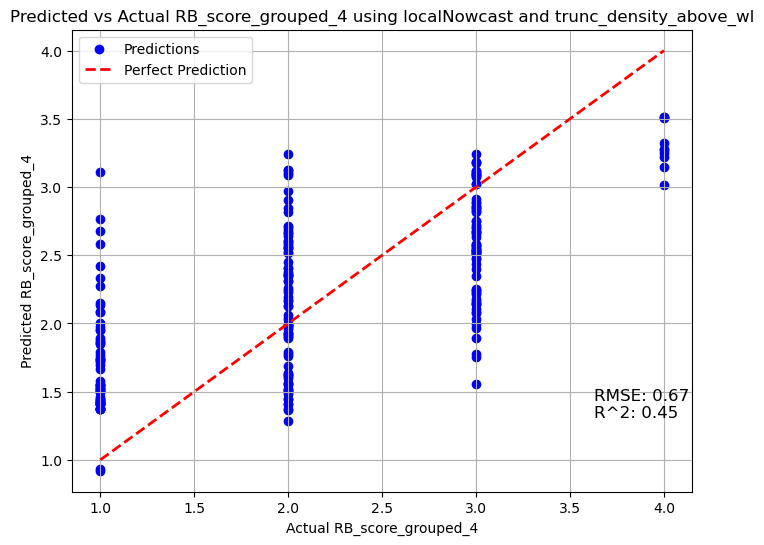

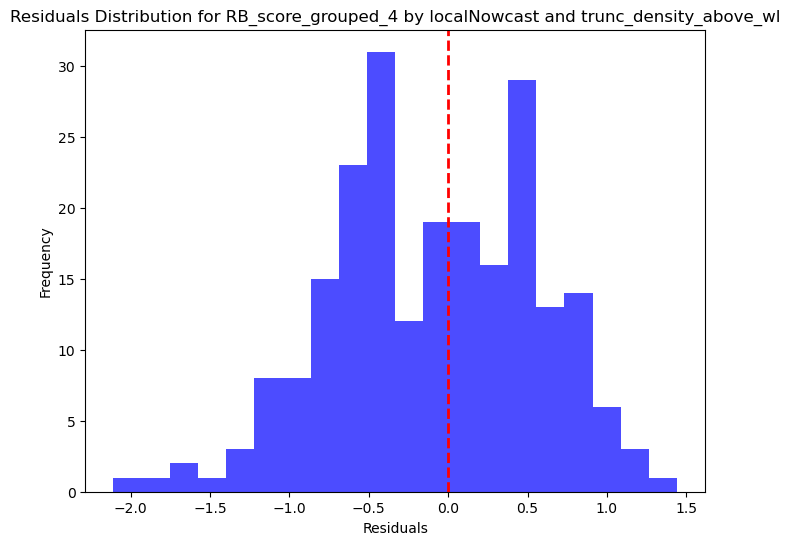

In [283]:
# Define predictor and target variables
predictor_var_localNowcast = "localNowcast"
predictor_var_trunc_density = "trunc_density_above_wl"  # New predictor for the two-input model
target_var_grouped = "RB_score_grouped_4"  # Target variable

# Prepare the data for the single-input model (only localNowcast)
X_localNowcast = df_raw[predictor_var_localNowcast].values.reshape(-1, 1)
y_grouped = df_raw[target_var_grouped].values

# Train-test split for the single-input model
X_train_single, X_test_single, y_train, y_test = train_test_split(X_localNowcast, y_grouped, test_size=0.3, random_state=36)

# Fit the single-input model (only localNowcast)
model_single = LinearRegression().fit(X_train_single, y_train)
y_pred_single = model_single.predict(X_test_single)
rss_single = np.sum((y_test - y_pred_single) ** 2)

# Cross-validated RMSE for the single-input model
cv_rmse_single = np.mean(np.sqrt(-cross_val_score(model_single, X_localNowcast, y_grouped, scoring='neg_mean_squared_error', cv=10)))
print(f'Cross-validated RMSE for model with only {predictor_var_localNowcast}: {cv_rmse_single}')

# Determine maximum length for padding for trunc_density_above_wl
max_length_trunc_density = max(len(lst) for lst in df_raw[predictor_var_trunc_density])

# Prepare the data for the two-input model (localNowcast and trunc_density_above_wl with padding)
X_trunc_density = np.array([lst + [0] * (max_length_trunc_density - len(lst)) for lst in df_raw[predictor_var_trunc_density]])
X_combined_two = np.hstack((X_localNowcast, X_trunc_density))

# Train-test split for the two-input model
X_train_two, X_test_two, y_train, y_test = train_test_split(X_combined_two, y_grouped, test_size=0.3, random_state=36)

# Fit the two-input model (localNowcast and trunc_density_above_wl)
model_two = LinearRegression().fit(X_train_two, y_train)
y_pred_two = model_two.predict(X_test_two)
rss_two = np.sum((y_test - y_pred_two) ** 2)

# Calculate F-statistic to compare the single-input and two-input models
p = X_combined_two.shape[1] - X_localNowcast.shape[1]  # Number of additional predictors (1 in this case)
n = len(y_test)                                       # Number of observations
k = X_combined_two.shape[1]                           # Total number of predictors in the two-input model

f_stat = ((rss_single - rss_two) / p) / (rss_two / (n - k))
p_value = 1 - f.cdf(f_stat, p, n - k)
print(f'F-statistic: {f_stat}, p-value: {p_value}')

# Cross-validated RMSE for the two-input model
cv_rmse_two = np.mean(np.sqrt(-cross_val_score(model_two, X_combined_two, y_grouped, scoring='neg_mean_squared_error', cv=10)))
print(f'Cross-validated RMSE for model with {predictor_var_localNowcast} and {predictor_var_trunc_density}: {cv_rmse_two}')

# Plot Predicted vs Actual Values for the two-input model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_two, c='blue', marker='o', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title(f'Predicted vs Actual {target_var_grouped} using {predictor_var_localNowcast} and {predictor_var_trunc_density}')
plt.xlabel(f'Actual {target_var_grouped}')
plt.ylabel(f'Predicted {target_var_grouped}')
plt.legend()
plt.grid(True)

# Annotate RMSE and R^2 on the plot for two-input model
x_pos = y_test.min() + (7 / 8) * (y_test.max() - y_test.min())
y_pos = y_pred_two.min() + (1 / 5) * (y_pred_two.max() - y_pred_two.min())
plt.text(x_pos, y_pos, f'RMSE: {cv_rmse_two:.2f}', fontsize=12, color='black')
plt.text(x_pos, y_pos - (y_pred_two.max() - y_pred_two.min()) * 0.05, f'R^2: {r2_score(y_test, y_pred_two):.2f}', fontsize=12, color='black')

# Save and show the plot for two-input model
plt.savefig(os.path.join(output_dir_4, f"predicted_vs_actual_{target_var_grouped}_by_{predictor_var_localNowcast}_{predictor_var_trunc_density}.png"))
plt.show()

# Plot Residuals Distribution for two-input model
residuals_two = y_test - y_pred_two
plt.figure(figsize=(8, 6))
plt.hist(residuals_two, bins=20, alpha=0.7, color='blue')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title(f'Residuals Distribution for {target_var_grouped} by {predictor_var_localNowcast} and {predictor_var_trunc_density}')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

# Save and show the residuals plot for two-input model
plt.savefig(os.path.join(output_dir_4, f"residuals_distribution_{target_var_grouped}_by_{predictor_var_localNowcast}_{predictor_var_trunc_density}.png"))
plt.show()

In [284]:
# Very similar performance when comparing the two, but maybe slightly better for group 4.0 when using full layers

In [285]:
# Similar trend as for RB_score, adding layers on top of density does not improve, so we switch back to truncated and add trunc_layers to trunc_layers+localNowcast and investigate performance

Cross-validated RMSE for model with trunc_density_above_wl and localNowcast: 0.674245293938419
F-statistic: 5.490063910940221, p-value: 2.6449458085942013e-05
Cross-validated RMSE for model with trunc_density_above_wl, localNowcast, and trunc_layers_above_wl: 0.641237696954759


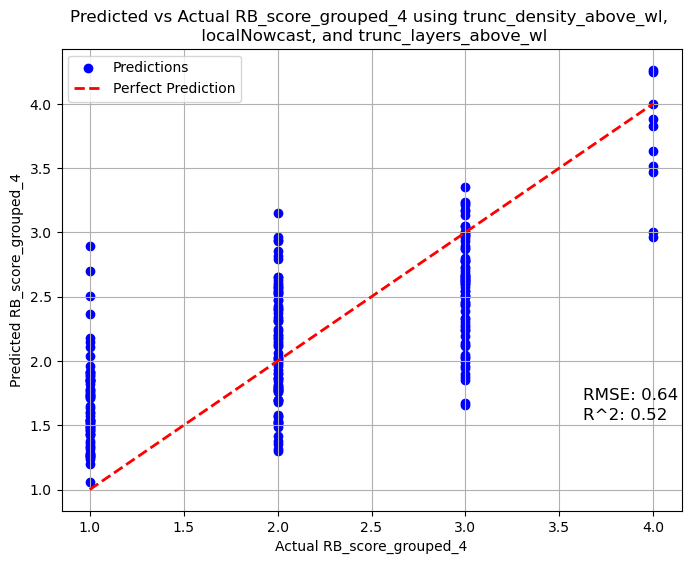

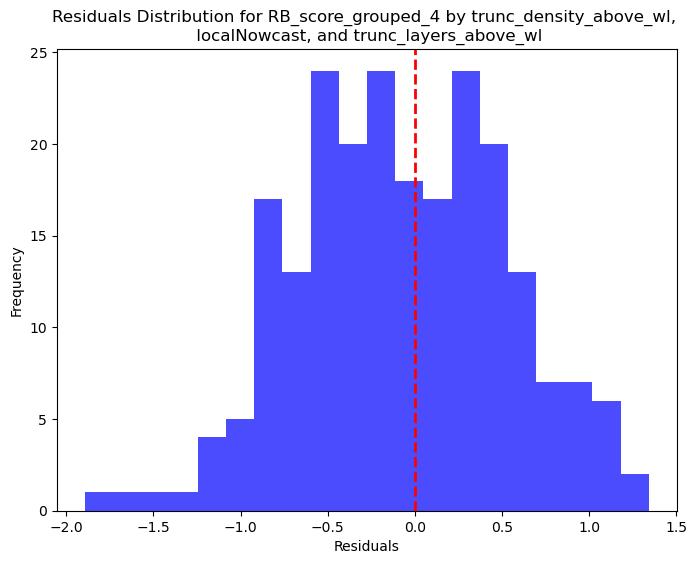

In [286]:
# Define predictor and target variables
predictor_var_trunc_density = "trunc_density_above_wl"
predictor_var_localNowcast = "localNowcast"
predictor_var_trunc_layers = "trunc_layers_above_wl"  # New predictor for the three-input model
target_var_grouped = "RB_score_grouped_4"

# Determine maximum length for padding for truncated density and layers
max_length_trunc_density = max(len(lst) for lst in df_raw[predictor_var_trunc_density])
max_length_trunc_layers = max(len(lst) for lst in df_raw[predictor_var_trunc_layers])
max_length = max(max_length_trunc_density, max_length_trunc_layers)  # Consistent padding length

# Prepare the data for the two-input model (trunc_density_above_wl and localNowcast with padding)
X_trunc_density = np.array([lst + [0] * (max_length - len(lst)) for lst in df_raw[predictor_var_trunc_density]])
X_localNowcast = df_raw[predictor_var_localNowcast].values.reshape(-1, 1)
y_grouped = df_raw[target_var_grouped].values

X_combined_two = np.hstack((X_trunc_density, X_localNowcast))  # Combine trunc_density and localNowcast

# Train-test split for the two-input model
X_train_two, X_test_two, y_train, y_test = train_test_split(X_combined_two, y_grouped, test_size=0.3, random_state=36)

# Fit the two-input model (trunc_density_above_wl and localNowcast)
model_two = LinearRegression().fit(X_train_two, y_train)
y_pred_two = model_two.predict(X_test_two)
rss_two = np.sum((y_test - y_pred_two) ** 2)

# Cross-validated RMSE for the two-input model
cv_rmse_two = np.mean(np.sqrt(-cross_val_score(model_two, X_combined_two, y_grouped, scoring='neg_mean_squared_error', cv=10)))
print(f'Cross-validated RMSE for model with {predictor_var_trunc_density} and {predictor_var_localNowcast}: {cv_rmse_two}')

# Prepare the data for the three-input model (trunc_density_above_wl, localNowcast, and trunc_layers_above_wl with padding)
X_trunc_layers = np.array([lst + [0] * (max_length - len(lst)) for lst in df_raw[predictor_var_trunc_layers]])
X_combined_three = np.hstack((X_trunc_density, X_localNowcast, X_trunc_layers))  # Combine trunc_density, localNowcast, and trunc_layers

# Train-test split for the three-input model
X_train_three, X_test_three, y_train, y_test = train_test_split(X_combined_three, y_grouped, test_size=0.3, random_state=36)

# Fit the three-input model (trunc_density_above_wl, localNowcast, and trunc_layers_above_wl)
model_three = LinearRegression().fit(X_train_three, y_train)
y_pred_three = model_three.predict(X_test_three)
rss_three = np.sum((y_test - y_pred_three) ** 2)

# Calculate F-statistic to compare the two-input and three-input models
p = X_combined_three.shape[1] - X_combined_two.shape[1]  # Number of additional predictors (1 in this case)
n = len(y_test)                                         # Number of observations
k = X_combined_three.shape[1]                           # Total number of predictors in the three-input model

f_stat = ((rss_two - rss_three) / p) / (rss_three / (n - k))
p_value = 1 - f.cdf(f_stat, p, n - k)
print(f'F-statistic: {f_stat}, p-value: {p_value}')

# Cross-validated RMSE for the three-input model
cv_rmse_three = np.mean(np.sqrt(-cross_val_score(model_three, X_combined_three, y_grouped, scoring='neg_mean_squared_error', cv=10)))
print(f'Cross-validated RMSE for model with {predictor_var_trunc_density}, {predictor_var_localNowcast}, and {predictor_var_trunc_layers}: {cv_rmse_three}')

# Plot Predicted vs Actual Values for the three-input model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_three, c='blue', marker='o', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title(f'Predicted vs Actual {target_var_grouped} using {predictor_var_trunc_density}, \n {predictor_var_localNowcast}, and {predictor_var_trunc_layers}')
plt.xlabel(f'Actual {target_var_grouped}')
plt.ylabel(f'Predicted {target_var_grouped}')
plt.legend()
plt.grid(True)

# Annotate RMSE and R^2 on the plot for three-input model
x_pos = y_test.min() + (7 / 8) * (y_test.max() - y_test.min())
y_pos = y_pred_three.min() + (1 / 5) * (y_pred_three.max() - y_pred_three.min())
plt.text(x_pos, y_pos, f'RMSE: {cv_rmse_three:.2f}', fontsize=12, color='black')
plt.text(x_pos, y_pos - (y_pred_three.max() - y_pred_three.min()) * 0.05, f'R^2: {r2_score(y_test, y_pred_three):.2f}', fontsize=12, color='black')

# Save and show the plot for three-input model
plt.savefig(os.path.join(output_dir_4, f"predicted_vs_actual_{target_var_grouped}_by_{predictor_var_trunc_density}_{predictor_var_localNowcast}_{predictor_var_trunc_layers}.png"))
plt.show()

# Plot Residuals Distribution for three-input model
residuals_three = y_test - y_pred_three
plt.figure(figsize=(8, 6))
plt.hist(residuals_three, bins=20, alpha=0.7, color='blue')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title(f'Residuals Distribution for {target_var_grouped} by {predictor_var_trunc_density}, \n {predictor_var_localNowcast}, and {predictor_var_trunc_layers}')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

# Save and show the residuals plot for three-input model
plt.savefig(os.path.join(output_dir_4, f"residuals_distribution_{target_var_grouped}_by_{predictor_var_trunc_density}_{predictor_var_localNowcast}_{predictor_var_trunc_layers}.png"))
plt.show()

Cross-validated RMSE for model with trunc_density_above_wl, localNowcast, and trunc_layers_above_wl: 0.641237696954759
F-statistic: 0.4671274163967872, p-value: 0.4950614988149866
Cross-validated RMSE for model with trunc_density_above_wl, localNowcast, trunc_layers_above_wl, and slopeangle: 0.6380430680143443


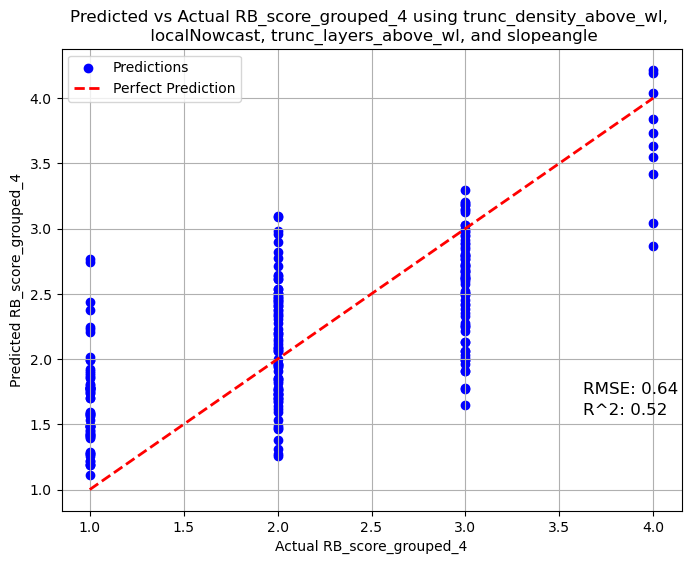

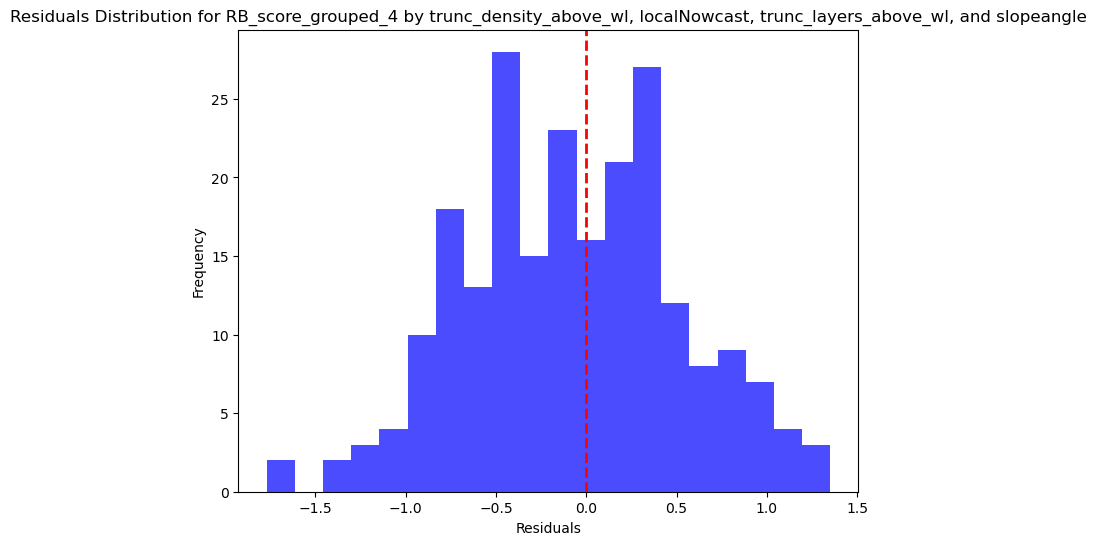

In [287]:
# Define predictor and target variables
predictor_var_trunc_density = "trunc_density_above_wl"
predictor_var_localNowcast = "localNowcast"
predictor_var_trunc_layers = "trunc_layers_above_wl"
predictor_var_slope = "slopeangle"  # New predictor for the four-input model
target_var_grouped = "RB_score_grouped_4"


# Determine maximum length for padding for truncated density and layers
max_length_trunc_density = max(len(lst) for lst in df_raw[predictor_var_trunc_density])
max_length_trunc_layers = max(len(lst) for lst in df_raw[predictor_var_trunc_layers])
max_length = max(max_length_trunc_density, max_length_trunc_layers)  # Consistent padding length

# Prepare the data for the three-input model (trunc_density_above_wl, localNowcast, and trunc_layers_above_wl with padding)
X_trunc_density = np.array([lst + [0] * (max_length - len(lst)) for lst in df_raw[predictor_var_trunc_density]])
X_localNowcast = df_raw[predictor_var_localNowcast].values.reshape(-1, 1)
X_trunc_layers = np.array([lst + [0] * (max_length - len(lst)) for lst in df_raw[predictor_var_trunc_layers]])
y_grouped = df_raw[target_var_grouped].values

X_combined_three = np.hstack((X_trunc_density, X_localNowcast, X_trunc_layers))  # Combine three predictors

# Train-test split for the three-input model
X_train_three, X_test_three, y_train, y_test = train_test_split(X_combined_three, y_grouped, test_size=0.3, random_state=36)

# Fit the three-input model (trunc_density_above_wl, localNowcast, and trunc_layers_above_wl)
model_three = LinearRegression().fit(X_train_three, y_train)
y_pred_three = model_three.predict(X_test_three)
rss_three = np.sum((y_test - y_pred_three) ** 2)

# Cross-validated RMSE for the three-input model
cv_rmse_three = np.mean(np.sqrt(-cross_val_score(model_three, X_combined_three, y_grouped, scoring='neg_mean_squared_error', cv=10)))
print(f'Cross-validated RMSE for model with {predictor_var_trunc_density}, {predictor_var_localNowcast}, and {predictor_var_trunc_layers}: {cv_rmse_three}')

# Prepare the data for the four-input model (trunc_density_above_wl, localNowcast, trunc_layers_above_wl, and slopeangle)
X_slope = df_raw[predictor_var_slope].values.reshape(-1, 1)  # slopeangle as a single column
X_combined_four = np.hstack((X_trunc_density, X_localNowcast, X_trunc_layers, X_slope))  # Combine all four predictors

# Train-test split for the four-input model
X_train_four, X_test_four, y_train, y_test = train_test_split(X_combined_four, y_grouped, test_size=0.3, random_state=36)

# Fit the four-input model (trunc_density_above_wl, localNowcast, trunc_layers_above_wl, and slopeangle)
model_four = LinearRegression().fit(X_train_four, y_train)
y_pred_four = model_four.predict(X_test_four)
rss_four = np.sum((y_test - y_pred_four) ** 2)

# Calculate F-statistic to compare the three-input and four-input models
p = X_combined_four.shape[1] - X_combined_three.shape[1]  # Number of additional predictors (1 in this case)
n = len(y_test)                                         # Number of observations
k = X_combined_four.shape[1]                            # Total number of predictors in the four-input model

f_stat = ((rss_three - rss_four) / p) / (rss_four / (n - k))
p_value = 1 - f.cdf(f_stat, p, n - k)
print(f'F-statistic: {f_stat}, p-value: {p_value}')

# Cross-validated RMSE for the four-input model
cv_rmse_four = np.mean(np.sqrt(-cross_val_score(model_four, X_combined_four, y_grouped, scoring='neg_mean_squared_error', cv=10)))
print(f'Cross-validated RMSE for model with {predictor_var_trunc_density}, {predictor_var_localNowcast}, {predictor_var_trunc_layers}, and {predictor_var_slope}: {cv_rmse_four}')

# Plot Predicted vs Actual Values for the four-input model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_four, c='blue', marker='o', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title(f'Predicted vs Actual {target_var_grouped} using {predictor_var_trunc_density}, \n {predictor_var_localNowcast}, {predictor_var_trunc_layers}, and {predictor_var_slope}')
plt.xlabel(f'Actual {target_var_grouped}')
plt.ylabel(f'Predicted {target_var_grouped}')
plt.legend()
plt.grid(True)

# Annotate RMSE and R^2 on the plot for four-input model
x_pos = y_test.min() + (7 / 8) * (y_test.max() - y_test.min())
y_pos = y_pred_four.min() + (1 / 5) * (y_pred_four.max() - y_pred_four.min())
plt.text(x_pos, y_pos, f'RMSE: {cv_rmse_four:.2f}', fontsize=12, color='black')
plt.text(x_pos, y_pos - (y_pred_four.max() - y_pred_four.min()) * 0.05, f'R^2: {r2_score(y_test, y_pred_four):.2f}', fontsize=12, color='black')

# Save and show the plot for four-input model
plt.savefig(os.path.join(output_dir_4, f"predicted_vs_actual_{target_var_grouped}_by_{predictor_var_trunc_density}_{predictor_var_localNowcast}_{predictor_var_trunc_layers}_{predictor_var_slope}.png"))
plt.show()

# Plot Residuals Distribution for four-input model
residuals_four = y_test - y_pred_four
plt.figure(figsize=(8, 6))
plt.hist(residuals_four, bins=20, alpha=0.7, color='blue')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title(f'Residuals Distribution for {target_var_grouped} by {predictor_var_trunc_density}, {predictor_var_localNowcast}, {predictor_var_trunc_layers}, and {predictor_var_slope}')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

# Save and show the residuals plot for four-input model
plt.savefig(os.path.join(output_dir_4, f"residuals_distribution_{target_var_grouped}_by_{predictor_var_trunc_density}_{predictor_var_localNowcast}_{predictor_var_trunc_layers}_{predictor_var_slope}.png"))
plt.show()

In [ ]:
# This is not a significant improvement, and once again we can note that localNowcast + trunc_density + trunc_layers performs best

# We can also note that we had better explainability of all seven levels for out best model

In [288]:
# we proceed with our fifth modelling approach, trying to predict stability (three classes)

# Define and create the new output directory for the fifth segment
output_dir_5 = os.path.join(os.getcwd(), "CN_thesis_plots", "5_stability")
os.makedirs(output_dir_5, exist_ok=True)  # Ensure the directory exists

Model Performance:
RMSE: 0.6418767281928958
R^2: 0.4132829734556094
Cross-validated RMSE for model with localNowcast: 0.6484288351910698


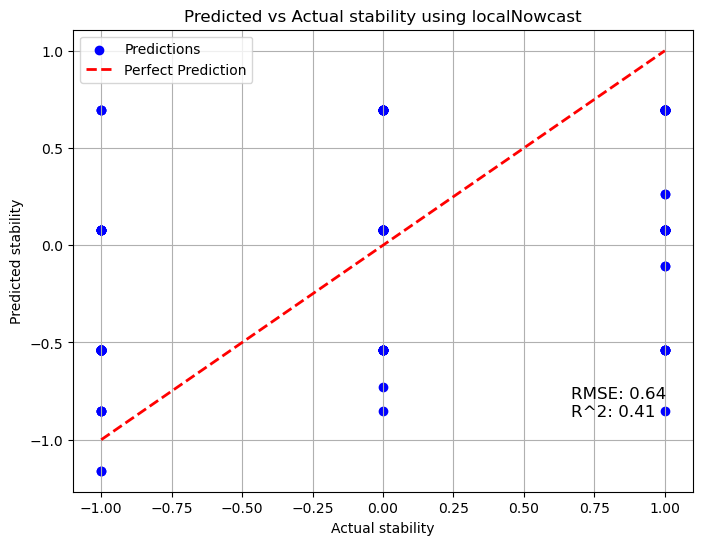

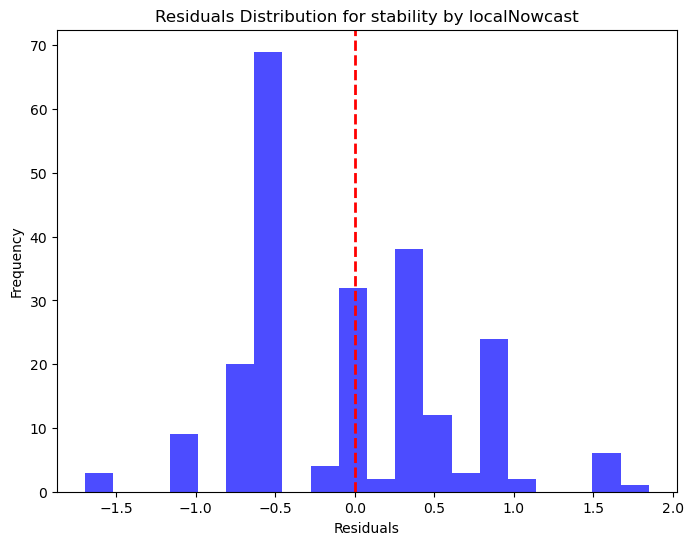

In [305]:
# Define predictor and target variables
predictor_var_localNowcast = "localNowcast"
target_var_stability = "stability"  # Assuming this is the three-step process target variable

# Prepare the data for the single-input model (using only localNowcast)
X_localNowcast = df_raw[predictor_var_localNowcast].values.reshape(-1, 1)  # Reshape for model compatibility
y_stability = df_raw[target_var_stability].values  # Target variable

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_localNowcast, y_stability, test_size=0.3, random_state=36)

# Fit the single-input model
model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)

# Calculate performance metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"Model Performance:\nRMSE: {rmse}\nR^2: {r2}")

# Cross-validated RMSE
cv_rmse = np.mean(np.sqrt(-cross_val_score(model, X_localNowcast, y_stability, scoring='neg_mean_squared_error', cv=10)))
print(f"Cross-validated RMSE for model with {predictor_var_localNowcast}: {cv_rmse}")

# Plot Predicted vs Actual Values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, c='blue', marker='o', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title(f'Predicted vs Actual {target_var_stability} using {predictor_var_localNowcast}')
plt.xlabel(f'Actual {target_var_stability}')
plt.ylabel(f'Predicted {target_var_stability}')
plt.legend()
plt.grid(True)

# Annotate RMSE and R^2 on the plot
x_pos = y_test.min() + (5 / 6) * (y_test.max() - y_test.min())
y_pos = y_pred.min() + (1 / 5) * (y_pred.max() - y_pred.min())
plt.text(x_pos, y_pos, f'RMSE: {rmse:.2f}', fontsize=12, color='black')
plt.text(x_pos, y_pos - (y_pred.max() - y_pred.min()) * 0.05, f'R^2: {r2:.2f}', fontsize=12, color='black')

# Save and show the plot
plt.savefig(os.path.join(output_dir_5, f"predicted_vs_actual_{target_var_stability}_by_{predictor_var_localNowcast}.png"))
plt.show()

# Plot Residuals Distribution
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=20, alpha=0.7, color='blue')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title(f'Residuals Distribution for {target_var_stability} by {predictor_var_localNowcast}')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

# Save and show the residuals plot
plt.savefig(os.path.join(output_dir_5, f"residuals_distribution_{target_var_stability}_by_{predictor_var_localNowcast}.png"))
plt.show()

Cross-validated RMSE for model with only localNowcast: 0.6484288351910698
F-statistic: 1.0051132055758283, p-value: 0.45654420407374396
Cross-validated RMSE for model with localNowcast and density_above_wl: 0.6188801343175546


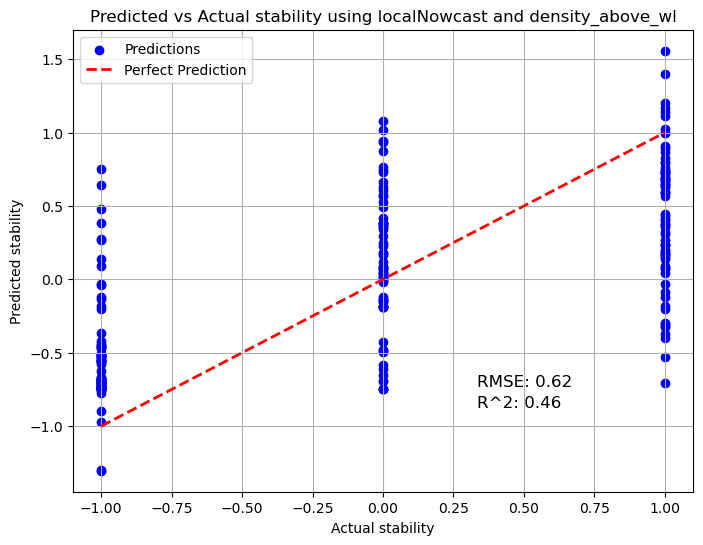

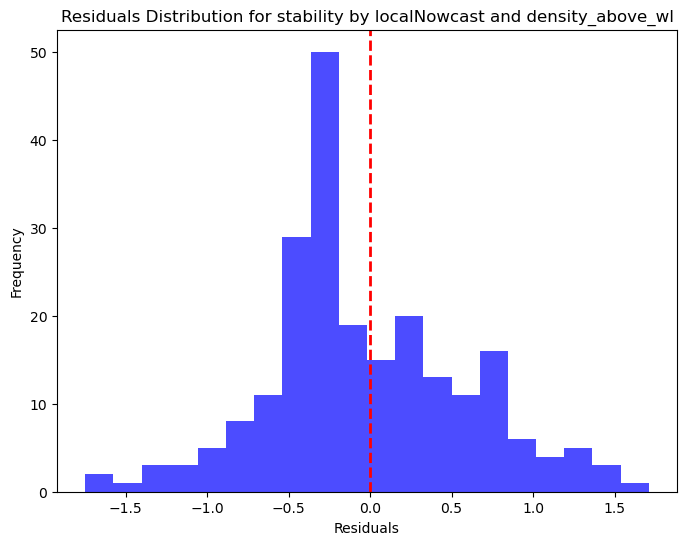

In [306]:
# Define predictor and target variables
predictor_var_localNowcast = "localNowcast"
predictor_var_density = "density_above_wl"  # Use density_above_wl instead of trunc_density_above_wl
target_var_stability = "stability"  # Target variable

# Determine maximum length for padding for density_above_wl
max_length_density = max(len(lst) for lst in df_raw[predictor_var_density])

# Prepare the data for the single-input model (using only localNowcast)
X_localNowcast = df_raw[predictor_var_localNowcast].values.reshape(-1, 1)
y_stability = df_raw[target_var_stability].values

# Train-test split for the single-input model
X_train_single, X_test_single, y_train, y_test = train_test_split(X_localNowcast, y_stability, test_size=0.3, random_state=36)

# Fit the single-input model (only localNowcast)
model_single = LinearRegression().fit(X_train_single, y_train)
y_pred_single = model_single.predict(X_test_single)
rss_single = np.sum((y_test - y_pred_single) ** 2)

# Cross-validated RMSE for the single-input model
cv_rmse_single = np.mean(np.sqrt(-cross_val_score(model_single, X_localNowcast, y_stability, scoring='neg_mean_squared_error', cv=10)))
print(f'Cross-validated RMSE for model with only {predictor_var_localNowcast}: {cv_rmse_single}')

# Prepare the data for the two-input model (localNowcast and density_above_wl with padding)
X_density = np.array([lst + [0] * (max_length_density - len(lst)) for lst in df_raw[predictor_var_density]])
X_combined_two = np.hstack((X_localNowcast, X_density))

# Train-test split for the two-input model
X_train_two, X_test_two, y_train, y_test = train_test_split(X_combined_two, y_stability, test_size=0.3, random_state=36)

# Fit the two-input model (localNowcast and density_above_wl)
model_two = LinearRegression().fit(X_train_two, y_train)
y_pred_two = model_two.predict(X_test_two)
rss_two = np.sum((y_test - y_pred_two) ** 2)

# Calculate F-statistic to compare the single-input and two-input models
p = X_combined_two.shape[1] - X_localNowcast.shape[1]  # Number of additional predictors (1 in this case)
n = len(y_test)                                       # Number of observations
k = X_combined_two.shape[1]                           # Total number of predictors in the two-input model

f_stat = ((rss_single - rss_two) / p) / (rss_two / (n - k))
p_value = 1 - f.cdf(f_stat, p, n - k)
print(f'F-statistic: {f_stat}, p-value: {p_value}')

# Cross-validated RMSE for the two-input model
cv_rmse_two = np.mean(np.sqrt(-cross_val_score(model_two, X_combined_two, y_stability, scoring='neg_mean_squared_error', cv=10)))
print(f'Cross-validated RMSE for model with {predictor_var_localNowcast} and {predictor_var_density}: {cv_rmse_two}')

# Plot Predicted vs Actual Values for the two-input model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_two, c='blue', marker='o', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title(f'Predicted vs Actual {target_var_stability} using {predictor_var_localNowcast} and {predictor_var_density}')
plt.xlabel(f'Actual {target_var_stability}')
plt.ylabel(f'Predicted {target_var_stability}')
plt.legend()
plt.grid(True)

# Annotate RMSE and R^2 on the plot for two-input model
x_pos = y_test.min() + (4 / 6) * (y_test.max() - y_test.min())
y_pos = y_pred_two.min() + (1 / 5) * (y_pred_two.max() - y_pred_two.min())
plt.text(x_pos, y_pos, f'RMSE: {cv_rmse_two:.2f}', fontsize=12, color='black')
plt.text(x_pos, y_pos - (y_pred_two.max() - y_pred_two.min()) * 0.05, f'R^2: {r2_score(y_test, y_pred_two):.2f}', fontsize=12, color='black')

# Save and show the plot for two-input model
plt.savefig(os.path.join(output_dir_5, f"predicted_vs_actual_{target_var_stability}_by_{predictor_var_localNowcast}_{predictor_var_density}.png"))
plt.show()

# Plot Residuals Distribution for two-input model
residuals_two = y_test - y_pred_two
plt.figure(figsize=(8, 6))
plt.hist(residuals_two, bins=20, alpha=0.7, color='blue')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title(f'Residuals Distribution for {target_var_stability} by {predictor_var_localNowcast} and {predictor_var_density}')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

# Save and show the residuals plot for two-input model
plt.savefig(os.path.join(output_dir_5, f"residuals_distribution_{target_var_stability}_by_{predictor_var_localNowcast}_{predictor_var_density}.png"))
plt.show()

In [300]:
# With poor performance we turn over to truncated profiles

Cross-validated RMSE for model with only localNowcast: 0.6484288351910698
F-statistic: 4.727883222438131, p-value: 0.0001506018745238702
Cross-validated RMSE for model with localNowcast and trunc_density_above_wl: 0.6129284624197409


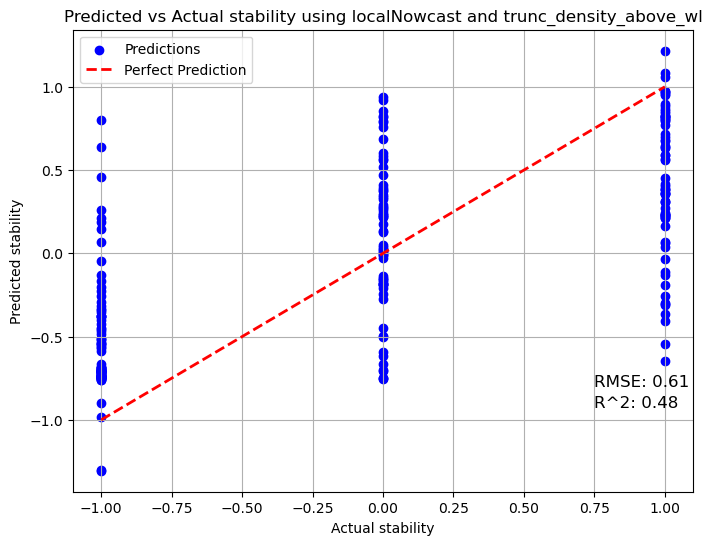

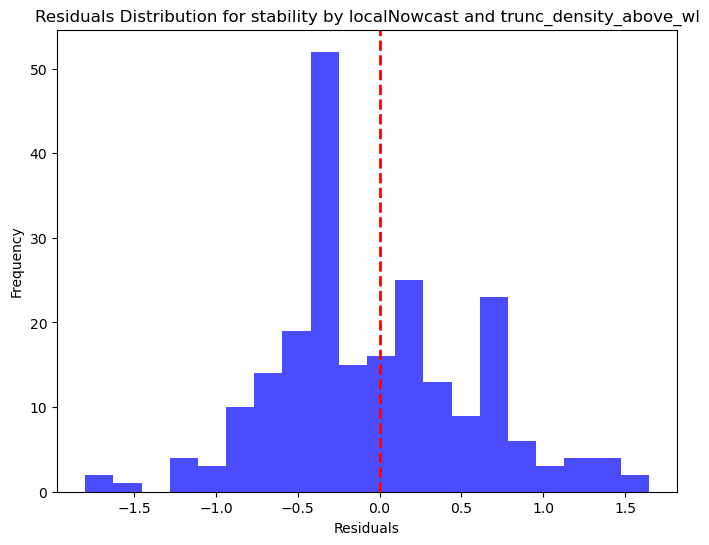

In [307]:
# Define predictor and target variables
predictor_var_localNowcast = "localNowcast"
predictor_var_trunc_density = "trunc_density_above_wl"  # Additional predictor for the two-input model
target_var_stability = "stability"  # Target variable

# Define the output directory for saving plots in the fifth segment
output_dir_5 = os.path.join(os.getcwd(), "CN_thesis_plots", "5_stability")
os.makedirs(output_dir_5, exist_ok=True)  # Ensure directories exist

# Train-test split for the single-input model
X_train_single, X_test_single, y_train, y_test = train_test_split(X_localNowcast, y_stability, test_size=0.3, random_state=36)

# Fit the single-input model (only localNowcast)
model_single = LinearRegression().fit(X_train_single, y_train)
y_pred_single = model_single.predict(X_test_single)
rss_single = np.sum((y_test - y_pred_single) ** 2)

# Cross-validated RMSE for the single-input model
cv_rmse_single = np.mean(np.sqrt(-cross_val_score(model_single, X_localNowcast, y_stability, scoring='neg_mean_squared_error', cv=10)))
print(f'Cross-validated RMSE for model with only {predictor_var_localNowcast}: {cv_rmse_single}')

# Determine maximum length for padding for trunc_density_above_wl
max_length_trunc_density = max(len(lst) for lst in df_raw[predictor_var_trunc_density])

# Prepare the data for the two-input model (localNowcast and trunc_density_above_wl with padding)
X_trunc_density = np.array([lst + [0] * (max_length_trunc_density - len(lst)) for lst in df_raw[predictor_var_trunc_density]])
X_combined_two = np.hstack((X_localNowcast, X_trunc_density))

# Train-test split for the two-input model
X_train_two, X_test_two, y_train, y_test = train_test_split(X_combined_two, y_stability, test_size=0.3, random_state=36)

# Fit the two-input model (localNowcast and trunc_density_above_wl)
model_two = LinearRegression().fit(X_train_two, y_train)
y_pred_two = model_two.predict(X_test_two)
rss_two = np.sum((y_test - y_pred_two) ** 2)

# Calculate F-statistic to compare the single-input and two-input models
p = X_combined_two.shape[1] - X_localNowcast.shape[1]  # Number of additional predictors (1 in this case)
n = len(y_test)                                       # Number of observations
k = X_combined_two.shape[1]                           # Total number of predictors in the two-input model

f_stat = ((rss_single - rss_two) / p) / (rss_two / (n - k))
p_value = 1 - f.cdf(f_stat, p, n - k)
print(f'F-statistic: {f_stat}, p-value: {p_value}')

# Cross-validated RMSE for the two-input model
cv_rmse_two = np.mean(np.sqrt(-cross_val_score(model_two, X_combined_two, y_stability, scoring='neg_mean_squared_error', cv=10)))
print(f'Cross-validated RMSE for model with {predictor_var_localNowcast} and {predictor_var_trunc_density}: {cv_rmse_two}')

# Plot Predicted vs Actual Values for the two-input model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_two, c='blue', marker='o', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title(f'Predicted vs Actual {target_var_stability} using {predictor_var_localNowcast} and {predictor_var_trunc_density}')
plt.xlabel(f'Actual {target_var_stability}')
plt.ylabel(f'Predicted {target_var_stability}')
plt.legend()
plt.grid(True)

# Annotate RMSE and R^2 on the plot for two-input model
x_pos = y_test.min() + (7 / 8) * (y_test.max() - y_test.min())
y_pos = y_pred_two.min() + (1 / 5) * (y_pred_two.max() - y_pred_two.min())
plt.text(x_pos, y_pos, f'RMSE: {cv_rmse_two:.2f}', fontsize=12, color='black')
plt.text(x_pos, y_pos - (y_pred_two.max() - y_pred_two.min()) * 0.05, f'R^2: {r2_score(y_test, y_pred_two):.2f}', fontsize=12, color='black')

# Save and show the plot for two-input model
plt.savefig(os.path.join(output_dir_5, f"predicted_vs_actual_{target_var_stability}_by_{predictor_var_localNowcast}_{predictor_var_trunc_density}.png"))
plt.show()

# Plot Residuals Distribution for two-input model
residuals_two = y_test - y_pred_two
plt.figure(figsize=(8, 6))
plt.hist(residuals_two, bins=20, alpha=0.7, color='blue')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title(f'Residuals Distribution for {target_var_stability} by {predictor_var_localNowcast} and {predictor_var_trunc_density}')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

# Save and show the residuals plot for two-input model
plt.savefig(os.path.join(output_dir_5, f"residuals_distribution_{target_var_stability}_by_{predictor_var_localNowcast}_{predictor_var_trunc_density}.png"))
plt.show()

Cross-validated RMSE for model with localNowcast and trunc_density_above_wl: 0.6129284624197409
F-statistic: 0.9050714010753449, p-value: 0.49211133575099086
Cross-validated RMSE for model with localNowcast, trunc_density_above_wl, and trunc_layers_above_wl: 0.6118768618367533


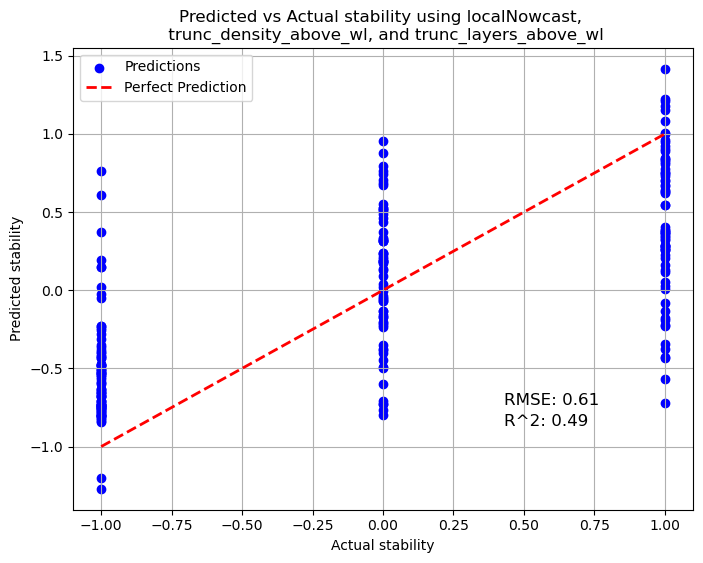

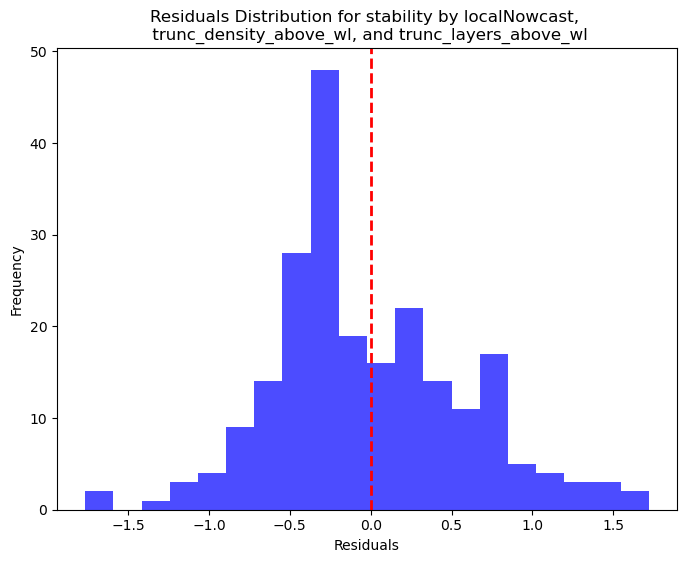

In [308]:
# Define predictor and target variables
predictor_var_localNowcast = "localNowcast"
predictor_var_trunc_density = "trunc_density_above_wl"
predictor_var_trunc_layers = "trunc_layers_above_wl"  # Additional predictor for the three-input model
target_var_stability = "stability"  # Target variable

# Determine maximum length for padding for trunc_density and trunc_layers
max_length_trunc_density = max(len(lst) for lst in df_raw[predictor_var_trunc_density])
max_length_trunc_layers = max(len(lst) for lst in df_raw[predictor_var_trunc_layers])
max_length = max(max_length_trunc_density, max_length_trunc_layers)  # Consistent padding length

# Prepare the data for the two-input model (localNowcast and trunc_density_above_wl with padding)
X_localNowcast = df_raw[predictor_var_localNowcast].values.reshape(-1, 1)
X_trunc_density = np.array([lst + [0] * (max_length - len(lst)) for lst in df_raw[predictor_var_trunc_density]])
y_stability = df_raw[target_var_stability].values

X_combined_two = np.hstack((X_localNowcast, X_trunc_density))  # Combine trunc_density and localNowcast

# Train-test split for the two-input model
X_train_two, X_test_two, y_train, y_test = train_test_split(X_combined_two, y_stability, test_size=0.3, random_state=36)

# Fit the two-input model (localNowcast and trunc_density_above_wl)
model_two = LinearRegression().fit(X_train_two, y_train)
y_pred_two = model_two.predict(X_test_two)
rss_two = np.sum((y_test - y_pred_two) ** 2)

# Cross-validated RMSE for the two-input model
cv_rmse_two = np.mean(np.sqrt(-cross_val_score(model_two, X_combined_two, y_stability, scoring='neg_mean_squared_error', cv=10)))
print(f'Cross-validated RMSE for model with {predictor_var_localNowcast} and {predictor_var_trunc_density}: {cv_rmse_two}')

# Prepare the data for the three-input model (localNowcast, trunc_density_above_wl, and trunc_layers_above_wl with padding)
X_trunc_layers = np.array([lst + [0] * (max_length - len(lst)) for lst in df_raw[predictor_var_trunc_layers]])
X_combined_three = np.hstack((X_localNowcast, X_trunc_density, X_trunc_layers))  # Combine trunc_density, localNowcast, and trunc_layers

# Train-test split for the three-input model
X_train_three, X_test_three, y_train, y_test = train_test_split(X_combined_three, y_stability, test_size=0.3, random_state=36)

# Fit the three-input model (localNowcast, trunc_density_above_wl, and trunc_layers_above_wl)
model_three = LinearRegression().fit(X_train_three, y_train)
y_pred_three = model_three.predict(X_test_three)
rss_three = np.sum((y_test - y_pred_three) ** 2)

# Calculate F-statistic to compare the two-input and three-input models
p = X_combined_three.shape[1] - X_combined_two.shape[1]  # Number of additional predictors (1 in this case)
n = len(y_test)                                         # Number of observations
k = X_combined_three.shape[1]                           # Total number of predictors in the three-input model

f_stat = ((rss_two - rss_three) / p) / (rss_three / (n - k))
p_value = 1 - f.cdf(f_stat, p, n - k)
print(f'F-statistic: {f_stat}, p-value: {p_value}')

# Cross-validated RMSE for the three-input model
cv_rmse_three = np.mean(np.sqrt(-cross_val_score(model_three, X_combined_three, y_stability, scoring='neg_mean_squared_error', cv=10)))
print(f'Cross-validated RMSE for model with {predictor_var_localNowcast}, {predictor_var_trunc_density}, and {predictor_var_trunc_layers}: {cv_rmse_three}')

# Plot Predicted vs Actual Values for the three-input model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_three, c='blue', marker='o', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title(f'Predicted vs Actual {target_var_stability} using {predictor_var_localNowcast}, \n {predictor_var_trunc_density}, and {predictor_var_trunc_layers}')
plt.xlabel(f'Actual {target_var_stability}')
plt.ylabel(f'Predicted {target_var_stability}')
plt.legend()
plt.grid(True)

# Annotate RMSE and R^2 on the plot for three-input model
x_pos = y_test.min() + (5 / 7) * (y_test.max() - y_test.min())
y_pos = y_pred_three.min() + (1 / 5) * (y_pred_three.max() - y_pred_three.min())
plt.text(x_pos, y_pos, f'RMSE: {cv_rmse_three:.2f}', fontsize=12, color='black')
plt.text(x_pos, y_pos - (y_pred_three.max() - y_pred_three.min()) * 0.05, f'R^2: {r2_score(y_test, y_pred_three):.2f}', fontsize=12, color='black')

# Save and show the plot for three-input model
plt.savefig(os.path.join(output_dir_5, f"predicted_vs_actual_{target_var_stability}_by_{predictor_var_localNowcast}_{predictor_var_trunc_density}_{predictor_var_trunc_layers}.png"))
plt.show()

# Plot Residuals Distribution for three-input model
residuals_three = y_test - y_pred_three
plt.figure(figsize=(8, 6))
plt.hist(residuals_three, bins=20, alpha=0.7, color='blue')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title(f'Residuals Distribution for {target_var_stability} by {predictor_var_localNowcast}, \n {predictor_var_trunc_density}, and {predictor_var_trunc_layers}')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

# Save and show the residuals plot for three-input model
plt.savefig(os.path.join(output_dir_5, f"residuals_distribution_{target_var_stability}_by_{predictor_var_localNowcast}_{predictor_var_trunc_density}_{predictor_var_trunc_layers}.png"))
plt.show()

In [94]:
# Adding trunc_layers is no longer significant, try with slopeangle instead

Cross-validated RMSE for model with localNowcast and trunc_density_above_wl: 0.6129284624197409
F-statistic: -0.8361037432627554, p-value: 1.0
Cross-validated RMSE for model with localNowcast, trunc_density_above_wl, and slopeangle: 0.608429792403761


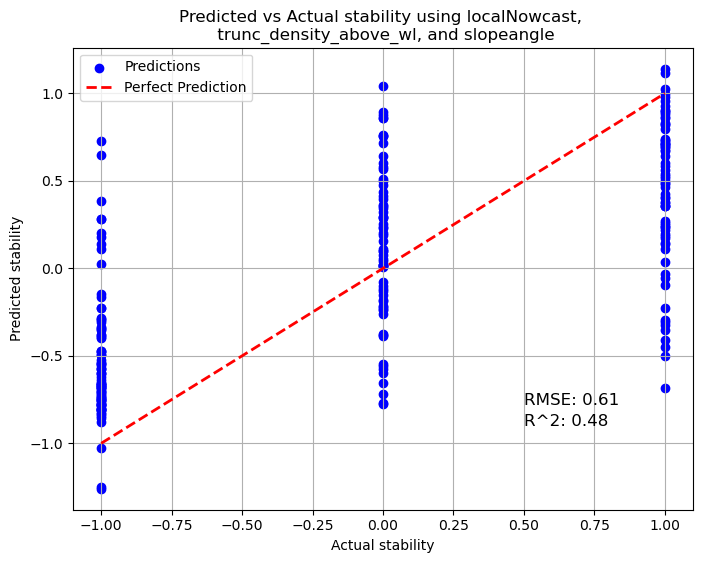

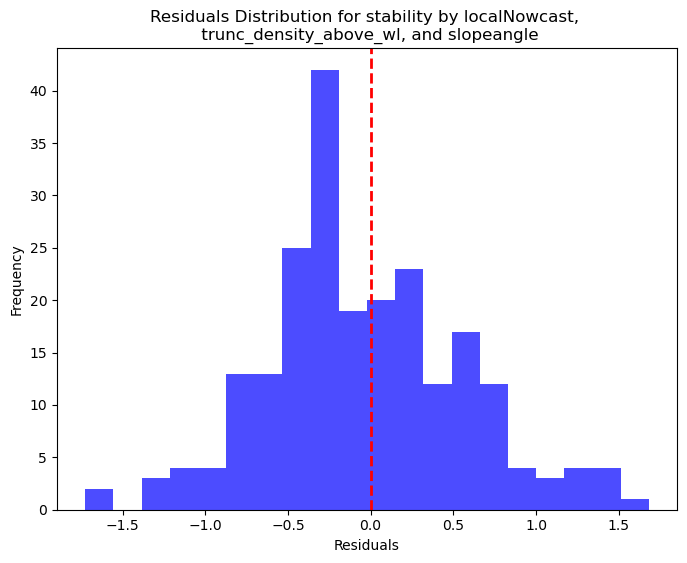

In [311]:
# Define predictor and target variables
predictor_var_localNowcast = "localNowcast"
predictor_var_trunc_density = "trunc_density_above_wl"
predictor_var_slope = "slopeangle"  # New predictor for the three-input model
target_var_stability = "stability"  # Target variable

# Determine maximum length for padding for trunc_density
max_length_trunc_density = max(len(lst) for lst in df_raw[predictor_var_trunc_density])

# Prepare the data for the two-input model (localNowcast and trunc_density_above_wl with padding)
X_localNowcast = df_raw[predictor_var_localNowcast].values.reshape(-1, 1)
X_trunc_density = np.array([lst + [0] * (max_length_trunc_density - len(lst)) for lst in df_raw[predictor_var_trunc_density]])
y_stability = df_raw[target_var_stability].values

X_combined_two = np.hstack((X_localNowcast, X_trunc_density))  # Combine trunc_density and localNowcast

# Train-test split for the two-input model
X_train_two, X_test_two, y_train, y_test = train_test_split(X_combined_two, y_stability, test_size=0.3, random_state=36)

# Fit the two-input model (localNowcast and trunc_density_above_wl)
model_two = LinearRegression().fit(X_train_two, y_train)
y_pred_two = model_two.predict(X_test_two)
rss_two = np.sum((y_test - y_pred_two) ** 2)

# Cross-validated RMSE for the two-input model
cv_rmse_two = np.mean(np.sqrt(-cross_val_score(model_two, X_combined_two, y_stability, scoring='neg_mean_squared_error', cv=10)))
print(f'Cross-validated RMSE for model with {predictor_var_localNowcast} and {predictor_var_trunc_density}: {cv_rmse_two}')

# Prepare the data for the three-input model (localNowcast, trunc_density_above_wl, and slopeangle)
X_slope = df_raw[predictor_var_slope].values.reshape(-1, 1)  # slopeangle as a single column
X_combined_three = np.hstack((X_localNowcast, X_trunc_density, X_slope))  # Combine trunc_density, localNowcast, and slopeangle

# Train-test split for the three-input model
X_train_three, X_test_three, y_train, y_test = train_test_split(X_combined_three, y_stability, test_size=0.3, random_state=36)

# Fit the three-input model (localNowcast, trunc_density_above_wl, and slopeangle)
model_three = LinearRegression().fit(X_train_three, y_train)
y_pred_three = model_three.predict(X_test_three)
rss_three = np.sum((y_test - y_pred_three) ** 2)

# Calculate F-statistic to compare the two-input and three-input models
p = X_combined_three.shape[1] - X_combined_two.shape[1]  # Number of additional predictors (1 in this case)
n = len(y_test)                                         # Number of observations
k = X_combined_three.shape[1]                           # Total number of predictors in the three-input model

f_stat = ((rss_two - rss_three) / p) / (rss_three / (n - k))
p_value = 1 - f.cdf(f_stat, p, n - k)
print(f'F-statistic: {f_stat}, p-value: {p_value}')

# Cross-validated RMSE for the three-input model
cv_rmse_three = np.mean(np.sqrt(-cross_val_score(model_three, X_combined_three, y_stability, scoring='neg_mean_squared_error', cv=10)))
print(f'Cross-validated RMSE for model with {predictor_var_localNowcast}, {predictor_var_trunc_density}, and {predictor_var_slope}: {cv_rmse_three}')

# Plot Predicted vs Actual Values for the three-input model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_three, c='blue', marker='o', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title(f'Predicted vs Actual {target_var_stability} using {predictor_var_localNowcast}, \n {predictor_var_trunc_density}, and {predictor_var_slope}')
plt.xlabel(f'Actual {target_var_stability}')
plt.ylabel(f'Predicted {target_var_stability}')
plt.legend()
plt.grid(True)

# Annotate RMSE and R^2 on the plot for three-input model
x_pos = y_test.min() + (6 / 8) * (y_test.max() - y_test.min())
y_pos = y_pred_three.min() + (1 / 5) * (y_pred_three.max() - y_pred_three.min())
plt.text(x_pos, y_pos, f'RMSE: {cv_rmse_three:.2f}', fontsize=12, color='black')
plt.text(x_pos, y_pos - (y_pred_three.max() - y_pred_three.min()) * 0.05, f'R^2: {r2_score(y_test, y_pred_three):.2f}', fontsize=12, color='black')

# Save and show the plot for three-input model
plt.savefig(os.path.join(output_dir_5, f"predicted_vs_actual_{target_var_stability}_by_{predictor_var_localNowcast}_{predictor_var_trunc_density}_{predictor_var_slope}.png"))
plt.show()

# Plot Residuals Distribution for three-input model
residuals_three = y_test - y_pred_three
plt.figure(figsize=(8, 6))
plt.hist(residuals_three, bins=20, alpha=0.7, color='blue')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title(f'Residuals Distribution for {target_var_stability} by {predictor_var_localNowcast}, \n {predictor_var_trunc_density}, and {predictor_var_slope}')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

# Save and show the residuals plot for three-input model
plt.savefig(os.path.join(output_dir_5, f"residuals_distribution_{target_var_stability}_by_{predictor_var_localNowcast}_{predictor_var_trunc_density}_{predictor_var_slope}.png"))
plt.show()

In [ ]:
# This is not an improvement either, we restart and try to add density to localNowcast to see if it is an improvement

In [ ]:
# This is not better either, so we can conclude that the best model is localNowcast + trunc_density, but that this is also worse than our predctive capabilities for all seven levels

In [ ]:
# Having looked through the data, we have noticed that not all observations actually have what is considered a weak_layer at the observed state, and can in a subset of all datapoint replace the observed wl with another layer that technically fulfills the criteria for being a weak_layer

In [102]:
# Define and create the new output directory for the sixth segment
output_dir_6 = os.path.join(os.getcwd(), "CN_thesis_plots", "6_weak_layers_exist")
os.makedirs(output_dir_6, exist_ok=True)  # Ensure the directory exists

In [ ]:
# We begin by filtering our df_raw dataset to df_weak_layers_exist by only including those rows for which the corresponding column for 'new_density_above_wl' is non-empty

In [124]:
# Filter df_raw to create df_weak_layers_exist with non-empty 'density_above_wl_new' entries
df_weak_layers_exist = df_raw[df_raw['density_above_wl_new'].apply(lambda x: len(x) > 0 if isinstance(x, list) else False)]

# Display the first few rows to confirm the filtering
print("Filtered dataset (df_weak_layers_exist) with non-empty 'density_above_wl_new':")
print(df_weak_layers_exist.head())

Filtered dataset (df_weak_layers_exist) with non-empty 'density_above_wl_new':
    profID                                          layer_top  \
1  10167.0  [15.0, 43.0, 60.0, 70.0, 70.7, 71.0, 77.0, 90....   
5  13330.0                   [10.0, 40.0, 58.0, 106.0, 107.0]   
6  13731.0  [5.0, 10.0, 72.0, 104.0, 108.0, 114.0, 124.0, ...   
7  14210.0         [25.0, 38.0, 41.0, 45.0, 55.0, 70.0, 81.0]   
8  14310.0        [30.0, 55.0, 58.0, 59.0, 95.0, 99.0, 100.0]   

                                        layer_bottom  \
1  [0.0, 15.0, 43.0, 60.0, 70.0, 70.7, 71.0, 77.0...   
5                     [0.0, 10.0, 40.0, 58.0, 106.0]   
6  [0.0, 5.0, 10.0, 72.0, 104.0, 108.0, 114.0, 12...   
7          [0.0, 25.0, 38.0, 41.0, 45.0, 55.0, 70.0]   
8          [0.0, 30.0, 55.0, 58.0, 59.0, 95.0, 99.0]   

                                            hardness  \
1  [1.5, 1.0, 3.5, 1.5, 1.0, 2.0, 1.0, 1.5, 2.5, ...   
5                          [1.0, 2.5, 2.0, 3.0, 1.0]   
6      [2.0, 3.0, 4.0, 3.

Cross-validated RMSE for model with only localNowcast: 1.2714125857817997
F-statistic: 0.9933701777203348, p-value: 0.4718519565466095
Cross-validated RMSE for model with localNowcast and density_above_wl_new: 1.173369496646374


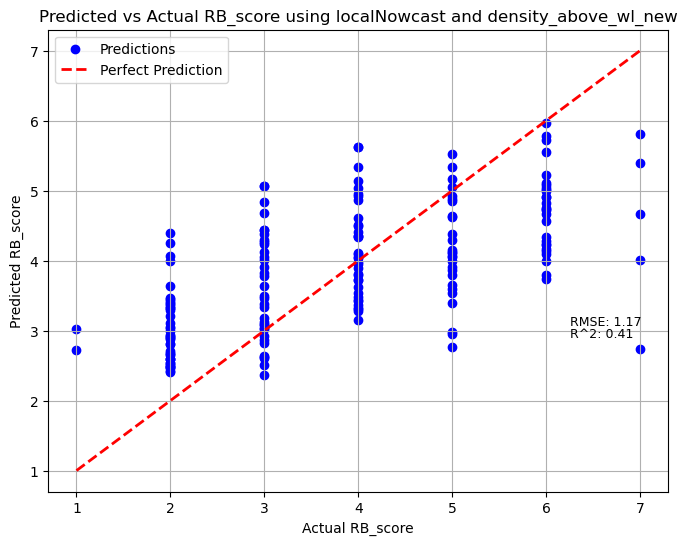

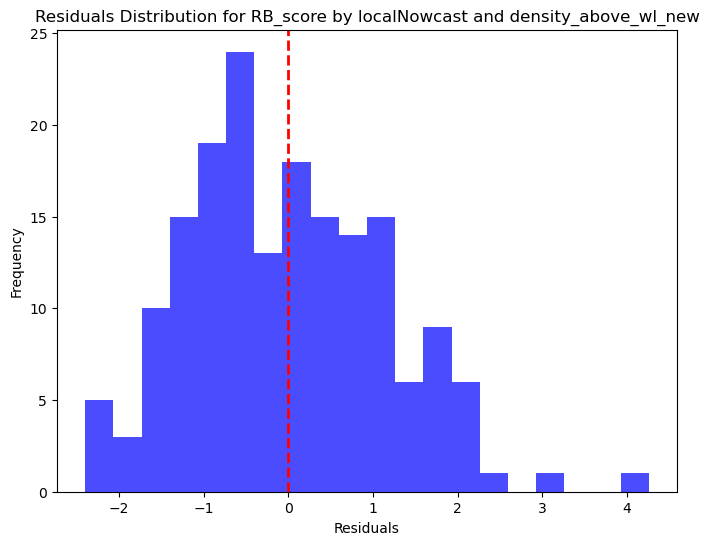

In [108]:
# Define predictor and target variables
predictor_var_localNowcast = "localNowcast"
predictor_var_density_new = "density_above_wl_new"  # Additional predictor for the two-input model
target_var_rb_score = "RB_score"

# Determine maximum length for padding for density_above_wl_new
max_length_density_new = max(len(lst) for lst in df_weak_layers_exist[predictor_var_density_new])

# Prepare the data for the single-input model (using only localNowcast)
X_localNowcast = df_weak_layers_exist[predictor_var_localNowcast].values.reshape(-1, 1)
y_rb_score = df_weak_layers_exist[target_var_rb_score].values

# Train-test split for the single-input model
X_train_single, X_test_single, y_train, y_test = train_test_split(X_localNowcast, y_rb_score, test_size=0.3, random_state=36)

# Fit the single-input model (only localNowcast)
model_single = LinearRegression().fit(X_train_single, y_train)
y_pred_single = model_single.predict(X_test_single)
rss_single = np.sum((y_test - y_pred_single) ** 2)

# Cross-validated RMSE for the single-input model
cv_rmse_single = np.mean(np.sqrt(-cross_val_score(model_single, X_localNowcast, y_rb_score, scoring='neg_mean_squared_error', cv=10)))
print(f'Cross-validated RMSE for model with only {predictor_var_localNowcast}: {cv_rmse_single}')

# Prepare the data for the two-input model (localNowcast and density_above_wl_new with padding)
X_density_new = np.array([lst + [0] * (max_length_density_new - len(lst)) for lst in df_weak_layers_exist[predictor_var_density_new]])
X_combined = np.hstack((X_localNowcast, X_density_new))

# Train-test split for the two-input model
X_train_two, X_test_two, y_train, y_test = train_test_split(X_combined, y_rb_score, test_size=0.3, random_state=36)

# Fit the two-input model (localNowcast and density_above_wl_new)
model_two = LinearRegression().fit(X_train_two, y_train)
y_pred_two = model_two.predict(X_test_two)
rss_two = np.sum((y_test - y_pred_two) ** 2)

# Calculate F-statistic to compare the single-input and two-input models
p = X_combined.shape[1] - X_localNowcast.shape[1]  # Number of additional predictors (1 in this case)
n = len(y_test)                                    # Number of observations
k = X_combined.shape[1]                            # Total number of predictors in the two-input model

f_stat = ((rss_single - rss_two) / p) / (rss_two / (n - k))
p_value = 1 - f.cdf(f_stat, p, n - k)
print(f'F-statistic: {f_stat}, p-value: {p_value}')

# Cross-validated RMSE for the two-input model
cv_rmse_two = np.mean(np.sqrt(-cross_val_score(model_two, X_combined, y_rb_score, scoring='neg_mean_squared_error', cv=10)))
print(f'Cross-validated RMSE for model with {predictor_var_localNowcast} and {predictor_var_density_new}: {cv_rmse_two}')

# Plot Predicted vs Actual Values for the two-input model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_two, c='blue', marker='o', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title(f'Predicted vs Actual {target_var_rb_score} using {predictor_var_localNowcast} and {predictor_var_density_new}')
plt.xlabel(f'Actual {target_var_rb_score}')
plt.ylabel(f'Predicted {target_var_rb_score}')
plt.legend()
plt.grid(True)

# Annotate RMSE and R^2 on the plot for two-input model
x_pos = y_test.min() + (7 / 8) * (y_test.max() - y_test.min())
y_pos = y_pred_two.min() + (1 / 5) * (y_pred_two.max() - y_pred_two.min())
plt.text(x_pos, y_pos, f'RMSE: {cv_rmse_two:.2f}', fontsize=9, color='black')
plt.text(x_pos, y_pos - (y_pred_two.max() - y_pred_two.min()) * 0.05, f'R^2: {r2_score(y_test, y_pred_two):.2f}', fontsize=9, color='black')

# Save and show the plot for the two-input model
plt.savefig(os.path.join(output_dir_6, f"predicted_vs_actual_{target_var_rb_score}_by_{predictor_var_localNowcast}_{predictor_var_density_new}.png"))
plt.show()

# Plot Residuals Distribution for two-input model
residuals_two = y_test - y_pred_two
plt.figure(figsize=(8, 6))
plt.hist(residuals_two, bins=20, alpha=0.7, color='blue')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title(f'Residuals Distribution for {target_var_rb_score} by {predictor_var_localNowcast} and {predictor_var_density_new}')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

# Save and show the residuals plot
plt.savefig(os.path.join(output_dir_6, f"residuals_distribution_{target_var_rb_score}_by_{predictor_var_localNowcast}_{predictor_var_density_new}.png"))
plt.show()

In [ ]:
# This is not an improvement compared to previously, and it is therefore most likely that it is best we use whichever was the manually determined weak_layer

Cross-validated RMSE for model with only localNowcast: 1.2714125857817997
F-statistic: 3.7715130463865187, p-value: 0.0015045092959241613
Cross-validated RMSE for model with localNowcast and trunc_density_above_wl_new: 1.1827763037299213


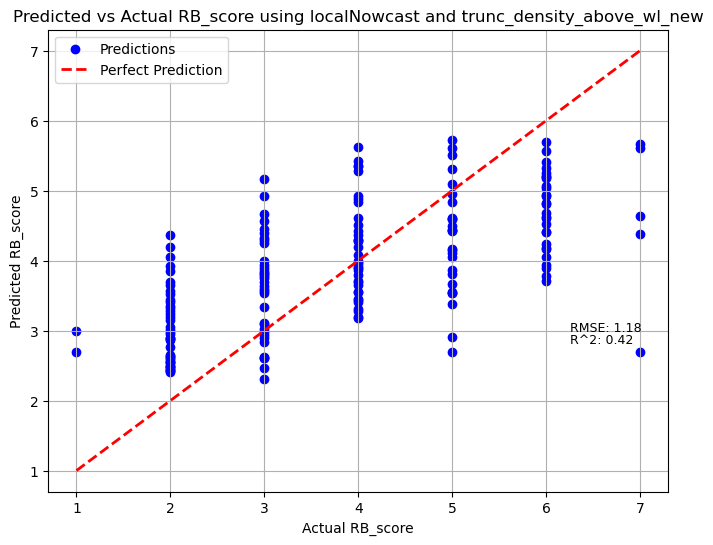

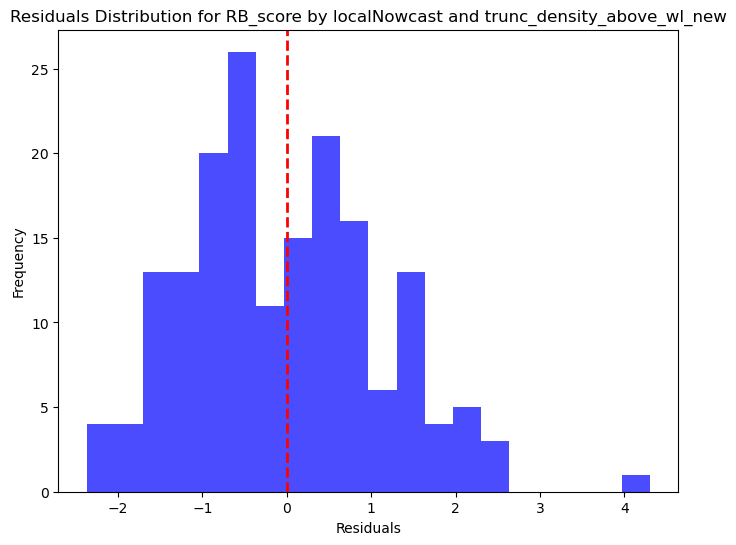

In [125]:
# Define predictor and target variables
predictor_var_localNowcast = "localNowcast"
predictor_var_trunc_density_new = "trunc_density_above_wl_new"  # Additional predictor for the two-input model
target_var_rb_score = "RB_score"

# Determine maximum length for padding for trunc_density_above_wl_new
max_length_trunc_density_new = max(len(lst) for lst in df_weak_layers_exist[predictor_var_trunc_density_new])

# Prepare the data for the single-input model (using only localNowcast)
X_localNowcast = df_weak_layers_exist[predictor_var_localNowcast].values.reshape(-1, 1)
y_rb_score = df_weak_layers_exist[target_var_rb_score].values

# Train-test split for the single-input model
X_train_single, X_test_single, y_train, y_test = train_test_split(X_localNowcast, y_rb_score, test_size=0.3, random_state=36)

# Fit the single-input model (only localNowcast)
model_single = LinearRegression().fit(X_train_single, y_train)
y_pred_single = model_single.predict(X_test_single)
rss_single = np.sum((y_test - y_pred_single) ** 2)

# Cross-validated RMSE for the single-input model
cv_rmse_single = np.mean(np.sqrt(-cross_val_score(model_single, X_localNowcast, y_rb_score, scoring='neg_mean_squared_error', cv=10)))
print(f'Cross-validated RMSE for model with only {predictor_var_localNowcast}: {cv_rmse_single}')

# Prepare the data for the two-input model (localNowcast and trunc_density_above_wl_new with padding)
X_trunc_density_new = np.array([lst + [0] * (max_length_trunc_density_new - len(lst)) for lst in df_weak_layers_exist[predictor_var_trunc_density_new]])
X_combined = np.hstack((X_localNowcast, X_trunc_density_new))

# Train-test split for the two-input model
X_train_two, X_test_two, y_train, y_test = train_test_split(X_combined, y_rb_score, test_size=0.3, random_state=36)

# Fit the two-input model (localNowcast and trunc_density_above_wl_new)
model_two = LinearRegression().fit(X_train_two, y_train)
y_pred_two = model_two.predict(X_test_two)
rss_two = np.sum((y_test - y_pred_two) ** 2)

# Calculate F-statistic to compare the single-input and two-input models
p = X_combined.shape[1] - X_localNowcast.shape[1]  # Number of additional predictors (1 in this case)
n = len(y_test)                                    # Number of observations
k = X_combined.shape[1]                            # Total number of predictors in the two-input model

f_stat = ((rss_single - rss_two) / p) / (rss_two / (n - k))
p_value = 1 - f.cdf(f_stat, p, n - k)
print(f'F-statistic: {f_stat}, p-value: {p_value}')

# Cross-validated RMSE for the two-input model
cv_rmse_two = np.mean(np.sqrt(-cross_val_score(model_two, X_combined, y_rb_score, scoring='neg_mean_squared_error', cv=10)))
print(f'Cross-validated RMSE for model with {predictor_var_localNowcast} and {predictor_var_trunc_density_new}: {cv_rmse_two}')

# Plot Predicted vs Actual Values for the two-input model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_two, c='blue', marker='o', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title(f'Predicted vs Actual {target_var_rb_score} using {predictor_var_localNowcast} and {predictor_var_trunc_density_new}')
plt.xlabel(f'Actual {target_var_rb_score}')
plt.ylabel(f'Predicted {target_var_rb_score}')
plt.legend()
plt.grid(True)

# Annotate RMSE and R^2 on the plot for two-input model
x_pos = y_test.min() + (7 / 8) * (y_test.max() - y_test.min())
y_pos = y_pred_two.min() + (1 / 5) * (y_pred_two.max() - y_pred_two.min())
plt.text(x_pos, y_pos, f'RMSE: {cv_rmse_two:.2f}', fontsize=9, color='black')
plt.text(x_pos, y_pos - (y_pred_two.max() - y_pred_two.min()) * 0.05, f'R^2: {r2_score(y_test, y_pred_two):.2f}', fontsize=9, color='black')

# Save and show the plot for the two-input model
plt.savefig(os.path.join(output_dir_6, f"predicted_vs_actual_{target_var_rb_score}_by_{predictor_var_localNowcast}_{predictor_var_trunc_density_new}.png"))
plt.show()

# Plot Residuals Distribution for two-input model
residuals_two = y_test - y_pred_two
plt.figure(figsize=(8, 6))
plt.hist(residuals_two, bins=20, alpha=0.7, color='blue')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title(f'Residuals Distribution for {target_var_rb_score} by {predictor_var_localNowcast} and {predictor_var_trunc_density_new}')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

# Save and show the residuals plot
plt.savefig(os.path.join(output_dir_6, f"residuals_distribution_{target_var_rb_score}_by_{predictor_var_localNowcast}_{predictor_var_trunc_density_new}.png"))
plt.show()

In [ ]:
# We have improved, and now try adding trunc_layers_new too

Cross-validated RMSE for model with localNowcast and trunc_density_above_wl_new: 1.1827763037299213
F-statistic: 3.4755272702204403, p-value: 0.0029390039249340694
Cross-validated RMSE for model with localNowcast, trunc_density_above_wl_new, and trunc_layers_above_wl_new: 1.1452078816789366


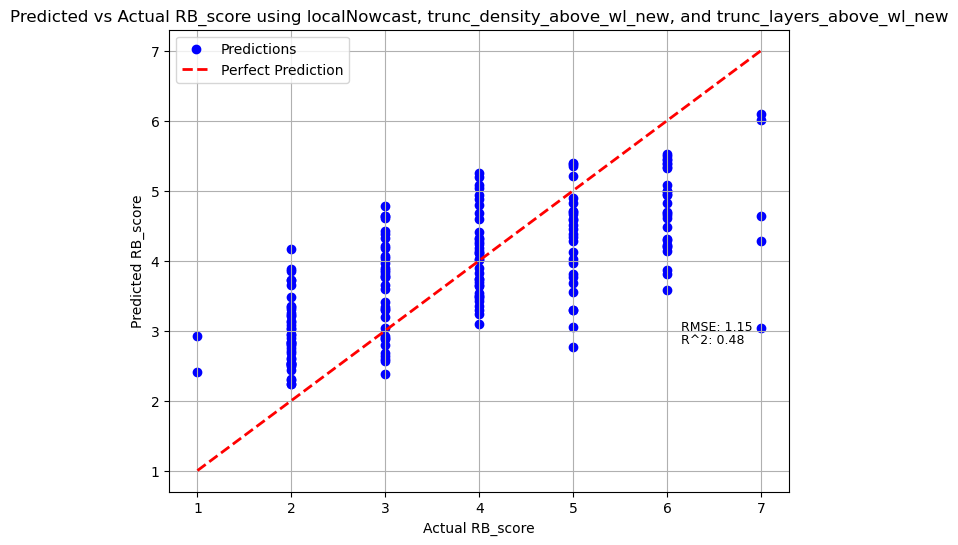

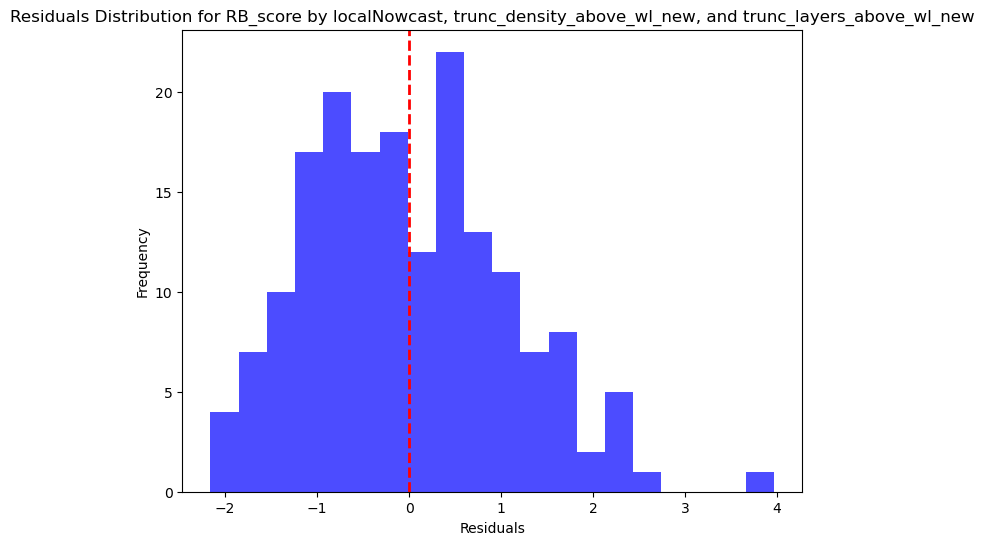

In [128]:
# Define predictor and target variables
predictor_var_localNowcast = "localNowcast"
predictor_var_trunc_density_new = "trunc_density_above_wl_new"
predictor_var_trunc_layers_new = "trunc_layers_above_wl_new"  # Additional predictor for the three-input model
target_var_rb_score = "RB_score"

# Determine maximum length for padding for trunc_density_above_wl_new and trunc_layers_above_wl_new
max_length_trunc_density_new = max(len(lst) for lst in df_weak_layers_exist[predictor_var_trunc_density_new])
max_length_trunc_layers_new = max(len(lst) for lst in df_weak_layers_exist[predictor_var_trunc_layers_new])
max_length = max(max_length_trunc_density_new, max_length_trunc_layers_new)  # Use the longest length for consistent padding

# Prepare the data for the two-input model (localNowcast and trunc_density_above_wl_new with padding)
X_localNowcast = df_weak_layers_exist[predictor_var_localNowcast].values.reshape(-1, 1)
X_trunc_density_new = np.array([lst + [0] * (max_length - len(lst)) for lst in df_weak_layers_exist[predictor_var_trunc_density_new]])
y_rb_score = df_weak_layers_exist[target_var_rb_score].values

# Combine predictors for the two-input model
X_combined_two = np.hstack((X_localNowcast, X_trunc_density_new))

# Train-test split for the two-input model
X_train_two, X_test_two, y_train, y_test = train_test_split(X_combined_two, y_rb_score, test_size=0.3, random_state=36)

# Fit the two-input model (localNowcast and trunc_density_above_wl_new)
model_two = LinearRegression().fit(X_train_two, y_train)
y_pred_two = model_two.predict(X_test_two)
rss_two = np.sum((y_test - y_pred_two) ** 2)

# Cross-validated RMSE for the two-input model
cv_rmse_two = np.mean(np.sqrt(-cross_val_score(model_two, X_combined_two, y_rb_score, scoring='neg_mean_squared_error', cv=10)))
print(f'Cross-validated RMSE for model with {predictor_var_localNowcast} and {predictor_var_trunc_density_new}: {cv_rmse_two}')

# Prepare the data for the three-input model (localNowcast, trunc_density_above_wl_new, and trunc_layers_above_wl_new with padding)
X_trunc_layers_new = np.array([lst + [0] * (max_length - len(lst)) for lst in df_weak_layers_exist[predictor_var_trunc_layers_new]])
X_combined_three = np.hstack((X_localNowcast, X_trunc_density_new, X_trunc_layers_new))  # Combine all three predictors

# Train-test split for the three-input model
X_train_three, X_test_three, y_train, y_test = train_test_split(X_combined_three, y_rb_score, test_size=0.3, random_state=36)

# Fit the three-input model (localNowcast, trunc_density_above_wl_new, and trunc_layers_above_wl_new)
model_three = LinearRegression().fit(X_train_three, y_train)
y_pred_three = model_three.predict(X_test_three)
rss_three = np.sum((y_test - y_pred_three) ** 2)

# Calculate F-statistic to compare the two-input and three-input models
p = X_combined_three.shape[1] - X_combined_two.shape[1]  # Number of additional predictors (1 in this case)
n = len(y_test)                                         # Number of observations
k = X_combined_three.shape[1]                           # Total number of predictors in the three-input model

f_stat = ((rss_two - rss_three) / p) / (rss_three / (n - k))
p_value = 1 - f.cdf(f_stat, p, n - k)
print(f'F-statistic: {f_stat}, p-value: {p_value}')

# Cross-validated RMSE for the three-input model
cv_rmse_three = np.mean(np.sqrt(-cross_val_score(model_three, X_combined_three, y_rb_score, scoring='neg_mean_squared_error', cv=10)))
print(f'Cross-validated RMSE for model with {predictor_var_localNowcast}, {predictor_var_trunc_density_new}, and {predictor_var_trunc_layers_new}: {cv_rmse_three}')

# Plot Predicted vs Actual Values for the three-input model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_three, c='blue', marker='o', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title(f'Predicted vs Actual {target_var_rb_score} using {predictor_var_localNowcast}, {predictor_var_trunc_density_new}, and {predictor_var_trunc_layers_new}')
plt.xlabel(f'Actual {target_var_rb_score}')
plt.ylabel(f'Predicted {target_var_rb_score}')
plt.legend()
plt.grid(True)

# Annotate RMSE and R^2 on the plot for three-input model
x_pos = y_test.min() + (6 / 7) * (y_test.max() - y_test.min())
y_pos = y_pred_three.min() + (1 / 5) * (y_pred_three.max() - y_pred_three.min())
plt.text(x_pos, y_pos, f'RMSE: {cv_rmse_three:.2f}', fontsize=9, color='black')
plt.text(x_pos, y_pos - (y_pred_three.max() - y_pred_three.min()) * 0.05, f'R^2: {r2_score(y_test, y_pred_three):.2f}', fontsize=9, color='black')

# Save and show the plot for three-input model
plt.savefig(os.path.join(output_dir_6, f"predicted_vs_actual_{target_var_rb_score}_by_{predictor_var_localNowcast}_{predictor_var_trunc_density_new}_{predictor_var_trunc_layers_new}.png"))
plt.show()

# Plot Residuals Distribution for three-input model
residuals_three = y_test - y_pred_three
plt.figure(figsize=(8, 6))
plt.hist(residuals_three, bins=20, alpha=0.7, color='blue')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title(f'Residuals Distribution for {target_var_rb_score} by {predictor_var_localNowcast}, {predictor_var_trunc_density_new}, and {predictor_var_trunc_layers_new}')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

# Save and show the residuals plot for three-input model
plt.savefig(os.path.join(output_dir_6, f"residuals_distribution_{target_var_rb_score}_by_{predictor_var_localNowcast}_{predictor_var_trunc_density_new}_{predictor_var_trunc_layers_new}.png"))
plt.show()

In [ ]:
# Also an imporvement, now try adding slopeangle

Cross-validated RMSE for model with localNowcast, trunc_density_above_wl_new, and trunc_layers_above_wl_new: 1.1452078816789366
F-statistic: -0.7821698598510805, p-value: 1.0
Cross-validated RMSE for model with localNowcast, trunc_density_above_wl_new, trunc_layers_above_wl_new, and slopeangle: 1.1447349119275614


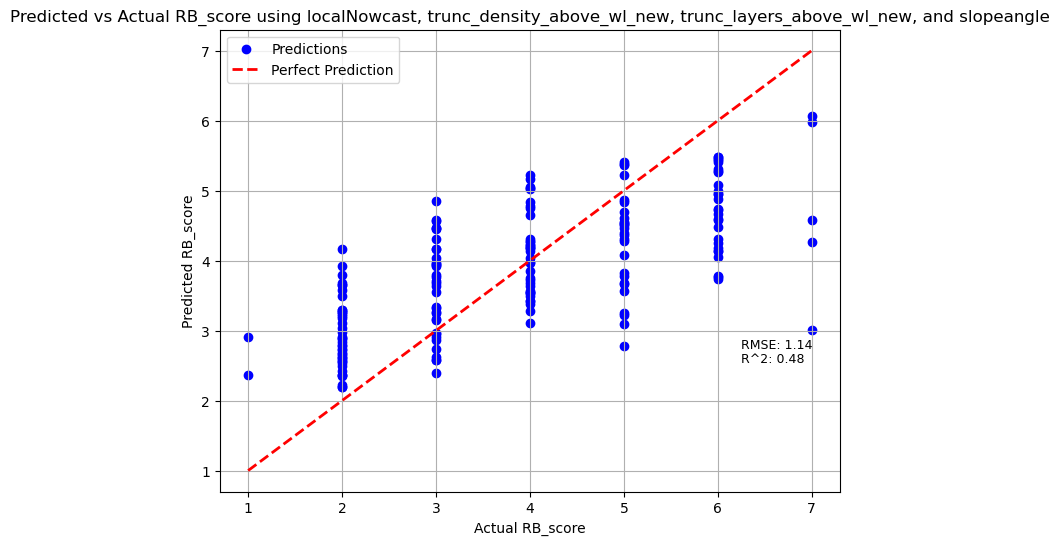

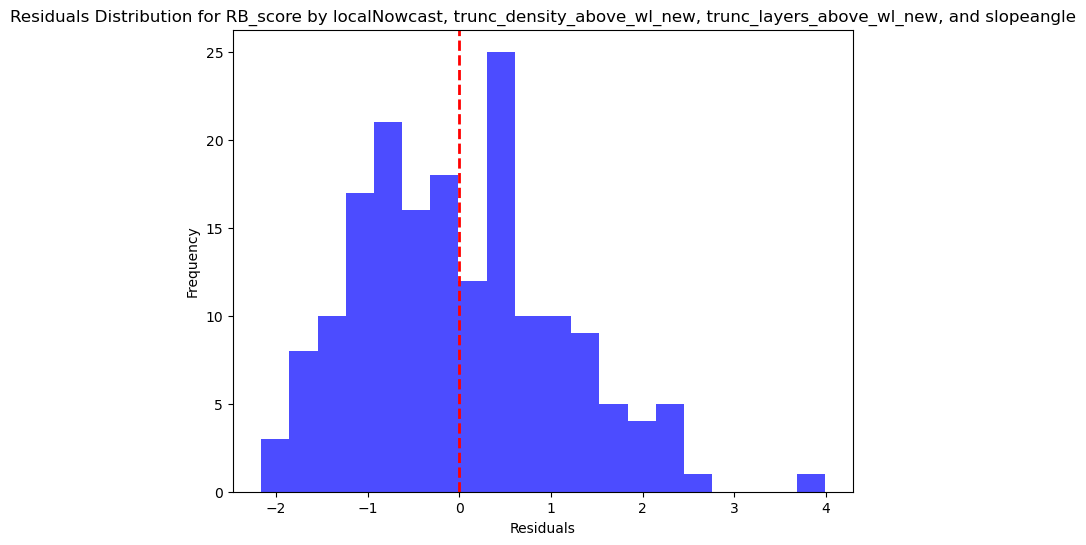

In [132]:
# Define predictor and target variables
predictor_var_localNowcast = "localNowcast"
predictor_var_trunc_density_new = "trunc_density_above_wl_new"
predictor_var_trunc_layers_new = "trunc_layers_above_wl_new"
predictor_var_slope = "slopeangle"  # Additional predictor for the four-input model
target_var_rb_score = "RB_score"

# Determine maximum length for padding for trunc_density_above_wl_new and trunc_layers_above_wl_new
max_length_trunc_density_new = max(len(lst) for lst in df_weak_layers_exist[predictor_var_trunc_density_new])
max_length_trunc_layers_new = max(len(lst) for lst in df_weak_layers_exist[predictor_var_trunc_layers_new])
max_length = max(max_length_trunc_density_new, max_length_trunc_layers_new)  # Use the longest length for consistent padding

# Prepare the data for the three-input model (localNowcast, trunc_density_above_wl_new, and trunc_layers_above_wl_new with padding)
X_localNowcast = df_weak_layers_exist[predictor_var_localNowcast].values.reshape(-1, 1)
X_trunc_density_new = np.array([lst + [0] * (max_length - len(lst)) for lst in df_weak_layers_exist[predictor_var_trunc_density_new]])
X_trunc_layers_new = np.array([lst + [0] * (max_length - len(lst)) for lst in df_weak_layers_exist[predictor_var_trunc_layers_new]])
y_rb_score = df_weak_layers_exist[target_var_rb_score].values

# Combine predictors for the three-input model
X_combined_three = np.hstack((X_localNowcast, X_trunc_density_new, X_trunc_layers_new))

# Train-test split for the three-input model
X_train_three, X_test_three, y_train, y_test = train_test_split(X_combined_three, y_rb_score, test_size=0.3, random_state=36)

# Fit the three-input model (localNowcast, trunc_density_above_wl_new, and trunc_layers_above_wl_new)
model_three = LinearRegression().fit(X_train_three, y_train)
y_pred_three = model_three.predict(X_test_three)
rss_three = np.sum((y_test - y_pred_three) ** 2)

# Cross-validated RMSE for the three-input model
cv_rmse_three = np.mean(np.sqrt(-cross_val_score(model_three, X_combined_three, y_rb_score, scoring='neg_mean_squared_error', cv=10)))
print(f'Cross-validated RMSE for model with {predictor_var_localNowcast}, {predictor_var_trunc_density_new}, and {predictor_var_trunc_layers_new}: {cv_rmse_three}')

# Prepare the data for the four-input model (localNowcast, trunc_density_above_wl_new, trunc_layers_above_wl_new, and slopeangle)
X_slope = df_weak_layers_exist[predictor_var_slope].values.reshape(-1, 1)  # slopeangle as a single column
X_combined_four = np.hstack((X_localNowcast, X_trunc_density_new, X_trunc_layers_new, X_slope))  # Combine all four predictors

# Train-test split for the four-input model
X_train_four, X_test_four, y_train, y_test = train_test_split(X_combined_four, y_rb_score, test_size=0.3, random_state=36)

# Fit the four-input model (localNowcast, trunc_density_above_wl_new, trunc_layers_above_wl_new, and slopeangle)
model_four = LinearRegression().fit(X_train_four, y_train)
y_pred_four = model_four.predict(X_test_four)
rss_four = np.sum((y_test - y_pred_four) ** 2)

# Calculate F-statistic to compare the three-input and four-input models
p = X_combined_four.shape[1] - X_combined_three.shape[1]  # Number of additional predictors (1 in this case)
n = len(y_test)                                          # Number of observations
k = X_combined_four.shape[1]                             # Total number of predictors in the four-input model

f_stat = ((rss_three - rss_four) / p) / (rss_four / (n - k))
p_value = 1 - f.cdf(f_stat, p, n - k)
print(f'F-statistic: {f_stat}, p-value: {p_value}')

# Cross-validated RMSE for the four-input model
cv_rmse_four = np.mean(np.sqrt(-cross_val_score(model_four, X_combined_four, y_rb_score, scoring='neg_mean_squared_error', cv=10)))
print(f'Cross-validated RMSE for model with {predictor_var_localNowcast}, {predictor_var_trunc_density_new}, {predictor_var_trunc_layers_new}, and {predictor_var_slope}: {cv_rmse_four}')

# Plot Predicted vs Actual Values for the four-input model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_four, c='blue', marker='o', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title(f'Predicted vs Actual {target_var_rb_score} using {predictor_var_localNowcast}, {predictor_var_trunc_density_new}, {predictor_var_trunc_layers_new}, and {predictor_var_slope}')
plt.xlabel(f'Actual {target_var_rb_score}')
plt.ylabel(f'Predicted {target_var_rb_score}')
plt.legend()
plt.grid(True)

# Annotate RMSE and R^2 on the plot for four-input model
x_pos = y_test.min() + (7 / 8) * (y_test.max() - y_test.min())
y_pos = y_pred_four.min() + (1 / 7) * (y_pred_four.max() - y_pred_four.min())
plt.text(x_pos, y_pos, f'RMSE: {cv_rmse_four:.2f}', fontsize=9, color='black')
plt.text(x_pos, y_pos - (y_pred_four.max() - y_pred_four.min()) * 0.05, f'R^2: {r2_score(y_test, y_pred_four):.2f}', fontsize=9, color='black')

# Save and show the plot for four-input model
plt.savefig(os.path.join(output_dir_6, f"predicted_vs_actual_{target_var_rb_score}_by_{predictor_var_localNowcast}_{predictor_var_trunc_density_new}_{predictor_var_trunc_layers_new}_{predictor_var_slope}.png"))
plt.show()

# Plot Residuals Distribution for four-input model
residuals_four = y_test - y_pred_four
plt.figure(figsize=(8, 6))
plt.hist(residuals_four, bins=20, alpha=0.7, color='blue')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title(f'Residuals Distribution for {target_var_rb_score} by {predictor_var_localNowcast}, {predictor_var_trunc_density_new}, {predictor_var_trunc_layers_new}, and {predictor_var_slope}')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

# Save and show the residuals plot for four-input model
plt.savefig(os.path.join(output_dir_6, f"residuals_distribution_{target_var_rb_score}_by_{predictor_var_localNowcast}_{predictor_var_trunc_density_new}_{predictor_var_trunc_layers_new}_{predictor_var_slope}.png"))
plt.show()

In [ ]:
# This is not an improvement, and we have found the significant best effort

In [ ]:
# As next step try predicting RB_score_4 using our three best parameters localNowcast + trunc_layers_above_wl_new + trunc_density_above_wl_new

Model Performance:
RMSE: 0.6140585533499471
R^2: 0.4334917263488133
Cross-validated RMSE for model with localNowcast, trunc_density_above_wl_new, and trunc_layers_above_wl_new: 0.6575931354251943


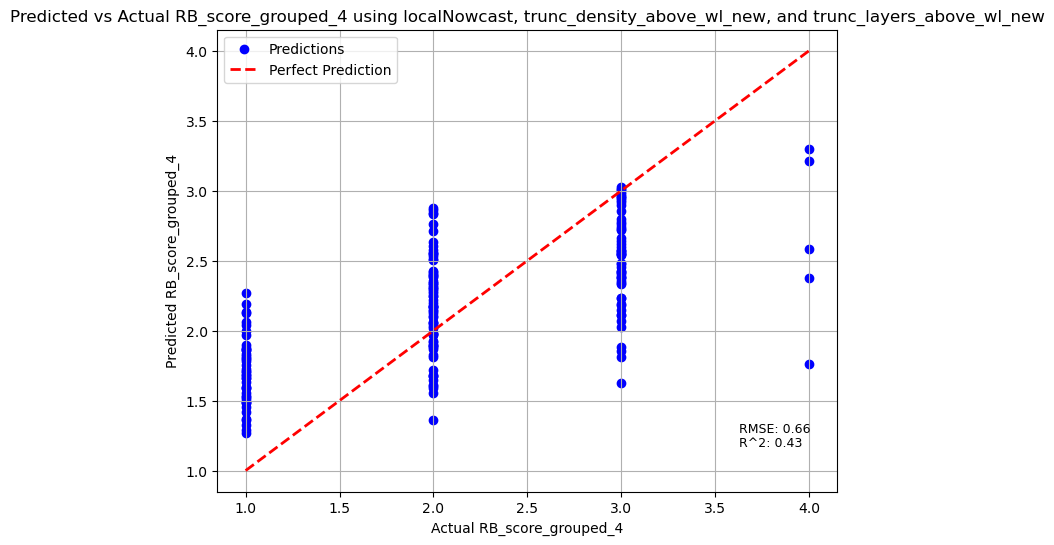

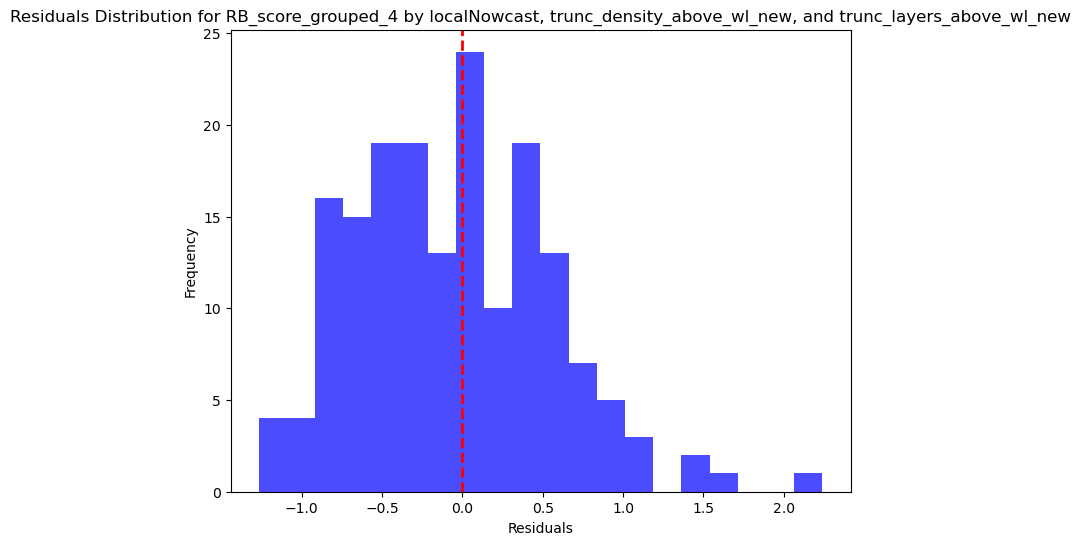

In [135]:
# Define predictor and target variables
predictor_var_localNowcast = "localNowcast"
predictor_var_trunc_density_new = "trunc_density_above_wl_new"
predictor_var_trunc_layers_new = "trunc_layers_above_wl_new"
target_var_rb_score_4 = "RB_score_grouped_4"  # New target variable for this model

# Determine maximum length for padding for trunc_density_above_wl_new and trunc_layers_above_wl_new
max_length_trunc_density_new = max(len(lst) for lst in df_weak_layers_exist[predictor_var_trunc_density_new])
max_length_trunc_layers_new = max(len(lst) for lst in df_weak_layers_exist[predictor_var_trunc_layers_new])
max_length = max(max_length_trunc_density_new, max_length_trunc_layers_new)  # Use the longest length for consistent padding

# Prepare the data for the three-input model (localNowcast, trunc_density_above_wl_new, and trunc_layers_above_wl_new with padding)
X_localNowcast = df_weak_layers_exist[predictor_var_localNowcast].values.reshape(-1, 1)
X_trunc_density_new = np.array([lst + [0] * (max_length - len(lst)) for lst in df_weak_layers_exist[predictor_var_trunc_density_new]])
X_trunc_layers_new = np.array([lst + [0] * (max_length - len(lst)) for lst in df_weak_layers_exist[predictor_var_trunc_layers_new]])
y_rb_score_4 = df_weak_layers_exist[target_var_rb_score_4].values

# Combine predictors into a single array
X_combined = np.hstack((X_localNowcast, X_trunc_density_new, X_trunc_layers_new))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_combined, y_rb_score_4, test_size=0.3, random_state=36)

# Fit the three-input model
model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)

# Calculate performance metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"Model Performance:\nRMSE: {rmse}\nR^2: {r2}")

# Cross-validated RMSE
cv_rmse = np.mean(np.sqrt(-cross_val_score(model, X_combined, y_rb_score_4, scoring='neg_mean_squared_error', cv=10)))
print(f"Cross-validated RMSE for model with {predictor_var_localNowcast}, {predictor_var_trunc_density_new}, and {predictor_var_trunc_layers_new}: {cv_rmse}")

# Plot Predicted vs Actual Values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, c='blue', marker='o', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title(f'Predicted vs Actual {target_var_rb_score_4} using {predictor_var_localNowcast}, {predictor_var_trunc_density_new}, and {predictor_var_trunc_layers_new}')
plt.xlabel(f'Actual {target_var_rb_score_4}')
plt.ylabel(f'Predicted {target_var_rb_score_4}')
plt.legend()
plt.grid(True)

# Annotate RMSE and R^2 on the plot
x_pos = y_test.min() + (7 / 8) * (y_test.max() - y_test.min())
y_pos = y_pred.min() + 0 * (y_pred.max() - y_pred.min())
plt.text(x_pos, y_pos, f'RMSE: {cv_rmse:.2f}', fontsize=9, color='black')
plt.text(x_pos, y_pos - (y_pred.max() - y_pred.min()) * 0.05, f'R^2: {r2:.2f}', fontsize=9, color='black')

# Save and show the plot for the three-input model
plt.savefig(os.path.join(output_dir_6, f"predicted_vs_actual_{target_var_rb_score_4}_by_{predictor_var_localNowcast}_{predictor_var_trunc_density_new}_{predictor_var_trunc_layers_new}.png"))
plt.show()

# Plot Residuals Distribution for three-input model
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=20, alpha=0.7, color='blue')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title(f'Residuals Distribution for {target_var_rb_score_4} by {predictor_var_localNowcast}, {predictor_var_trunc_density_new}, and {predictor_var_trunc_layers_new}')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

# Save and show the residuals plot
plt.savefig(os.path.join(output_dir_6, f"residuals_distribution_{target_var_rb_score_4}_by_{predictor_var_localNowcast}_{predictor_var_trunc_density_new}_{predictor_var_trunc_layers_new}.png"))
plt.show()

In [ ]:
# We have lower RMSE but also lower R2, try removing layers and check if this is an improvement

F-statistic: 3.3036742087422937, p-value: 0.004287485318081652
Cross-validated RMSE for model with localNowcast and trunc_density_above_wl_new: 0.6773410971422318


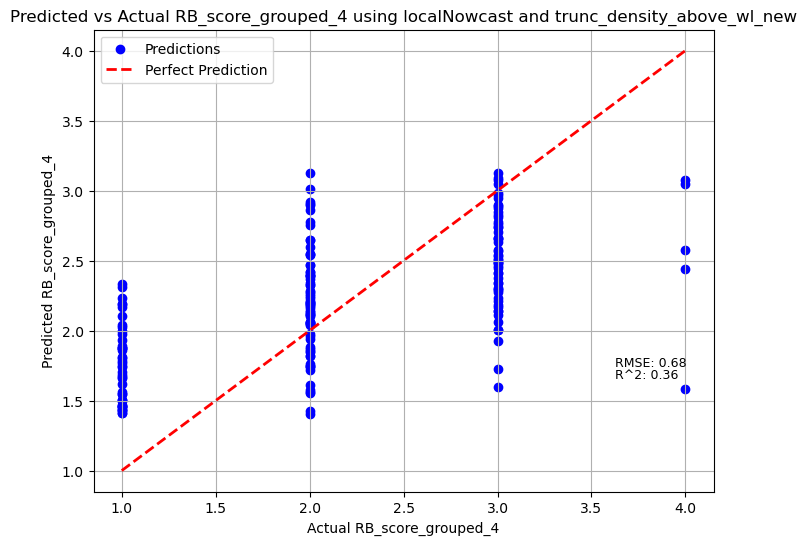

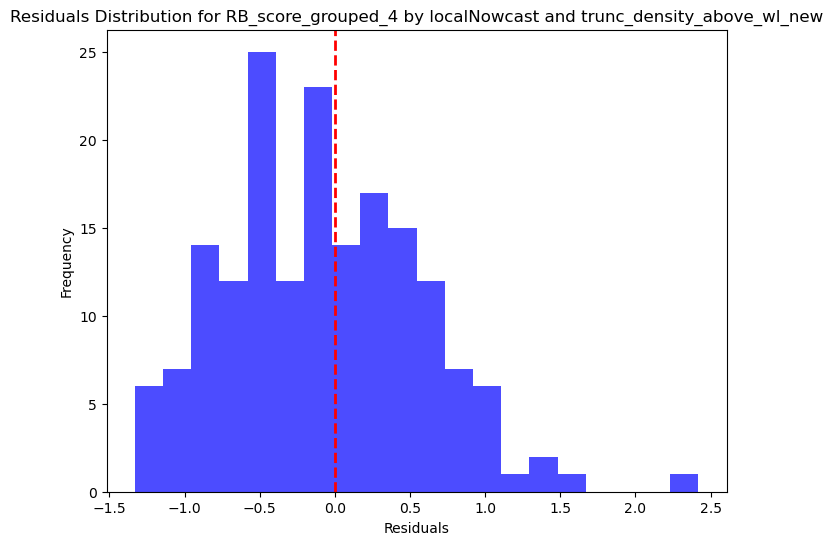

In [139]:
# Define predictor and target variables
predictor_var_localNowcast = "localNowcast"
predictor_var_trunc_density_new = "trunc_density_above_wl_new"
predictor_var_trunc_layers_new = "trunc_layers_above_wl_new"  # For the larger model
target_var_rb_score_4 = "RB_score_grouped_4"

# Determine maximum length for padding for trunc_density_above_wl_new and trunc_layers_above_wl_new
max_length_trunc_density_new = max(len(lst) for lst in df_weak_layers_exist[predictor_var_trunc_density_new])
max_length_trunc_layers_new = max(len(lst) for lst in df_weak_layers_exist[predictor_var_trunc_layers_new])
max_length = max(max_length_trunc_density_new, max_length_trunc_layers_new)

# Prepare data for the larger three-input model
X_localNowcast = df_weak_layers_exist[predictor_var_localNowcast].values.reshape(-1, 1)
X_trunc_density_new = np.array([lst + [0] * (max_length - len(lst)) for lst in df_weak_layers_exist[predictor_var_trunc_density_new]])
X_trunc_layers_new = np.array([lst + [0] * (max_length - len(lst)) for lst in df_weak_layers_exist[predictor_var_trunc_layers_new]])
y_rb_score_4 = df_weak_layers_exist[target_var_rb_score_4].values

# Combine predictors for the larger three-input model
X_combined_three = np.hstack((X_localNowcast, X_trunc_density_new, X_trunc_layers_new))

# Train-test split for the three-input model
X_train_three, X_test_three, y_train, y_test = train_test_split(X_combined_three, y_rb_score_4, test_size=0.3, random_state=36)

# Fit the three-input model (localNowcast, trunc_density_above_wl_new, and trunc_layers_above_wl_new)
model_three = LinearRegression().fit(X_train_three, y_train)
y_pred_three = model_three.predict(X_test_three)
rss_three = np.sum((y_test - y_pred_three) ** 2)

# Prepare data for the smaller two-input model
X_combined_two = np.hstack((X_localNowcast, X_trunc_density_new))

# Train-test split for the two-input model
X_train_two, X_test_two, y_train, y_test = train_test_split(X_combined_two, y_rb_score_4, test_size=0.3, random_state=36)

# Fit the two-input model (localNowcast and trunc_density_above_wl_new)
model_two = LinearRegression().fit(X_train_two, y_train)
y_pred_two = model_two.predict(X_test_two)
rss_two = np.sum((y_test - y_pred_two) ** 2)

# Calculate F-statistic to compare the larger three-input and smaller two-input models
p = X_combined_three.shape[1] - X_combined_two.shape[1]  # Number of additional predictors (1 in this case)
n = len(y_test)                                         # Number of observations
k = X_combined_three.shape[1]                           # Total number of predictors in the larger model

f_stat = ((rss_two - rss_three) / p) / (rss_three / (n - k))
p_value = 1 - f.cdf(f_stat, p, n - k)
print(f'F-statistic: {f_stat}, p-value: {p_value}')

# Cross-validated RMSE for the two-input model
cv_rmse_two = np.mean(np.sqrt(-cross_val_score(model_two, X_combined_two, y_rb_score_4, scoring='neg_mean_squared_error', cv=10)))
print(f"Cross-validated RMSE for model with {predictor_var_localNowcast} and {predictor_var_trunc_density_new}: {cv_rmse_two}")

# Plot Predicted vs Actual Values for the two-input model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_two, c='blue', marker='o', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title(f'Predicted vs Actual {target_var_rb_score_4} using {predictor_var_localNowcast} and {predictor_var_trunc_density_new}')
plt.xlabel(f'Actual {target_var_rb_score_4}')
plt.ylabel(f'Predicted {target_var_rb_score_4}')
plt.legend()
plt.grid(True)

# Annotate RMSE and R^2 on the plot
x_pos = y_test.min() + (7 / 8) * (y_test.max() - y_test.min())
y_pos = y_pred_two.min() + (1 / 5) * (y_pred_two.max() - y_pred_two.min())
plt.text(x_pos, y_pos, f'RMSE: {cv_rmse_two:.2f}', fontsize=9, color='black')
plt.text(x_pos, y_pos - (y_pred_two.max() - y_pred_two.min()) * 0.05, f'R^2: {r2_score(y_test, y_pred_two):.2f}', fontsize=9, color='black')

# Save and show the plot for the two-input model
plt.savefig(os.path.join(output_dir_6, f"predicted_vs_actual_{target_var_rb_score_4}_by_{predictor_var_localNowcast}_{predictor_var_trunc_density_new}.png"))
plt.show()

# Plot Residuals Distribution for two-input model
residuals = y_test - y_pred_two
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=20, alpha=0.7, color='blue')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title(f'Residuals Distribution for {target_var_rb_score_4} by {predictor_var_localNowcast} and {predictor_var_trunc_density_new}')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

# Save and show the residuals plot
plt.savefig(os.path.join(output_dir_6, f"residuals_distribution_{target_var_rb_score_4}_by_{predictor_var_localNowcast}_{predictor_var_trunc_density_new}.png"))
plt.show()


In [ ]:
# We can thus conclude that localNowcast + trunc_layers + trunc_density performs best, but worse than the baseline

Model Performance:
RMSE: 0.6234414416816174
R^2: 0.44573936227950306
Cross-validated RMSE for model with localNowcast, trunc_density_above_wl_new, and trunc_layers_above_wl_new: 0.6425754769305756


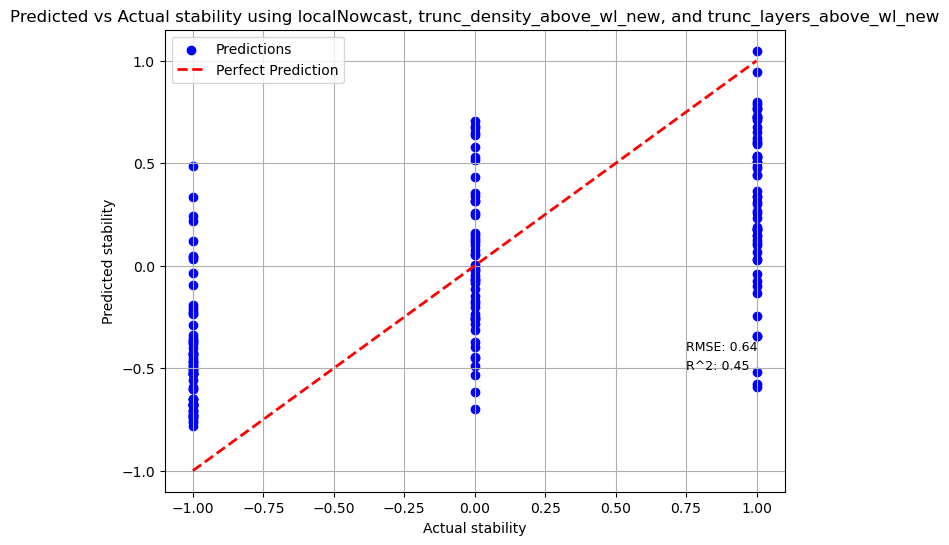

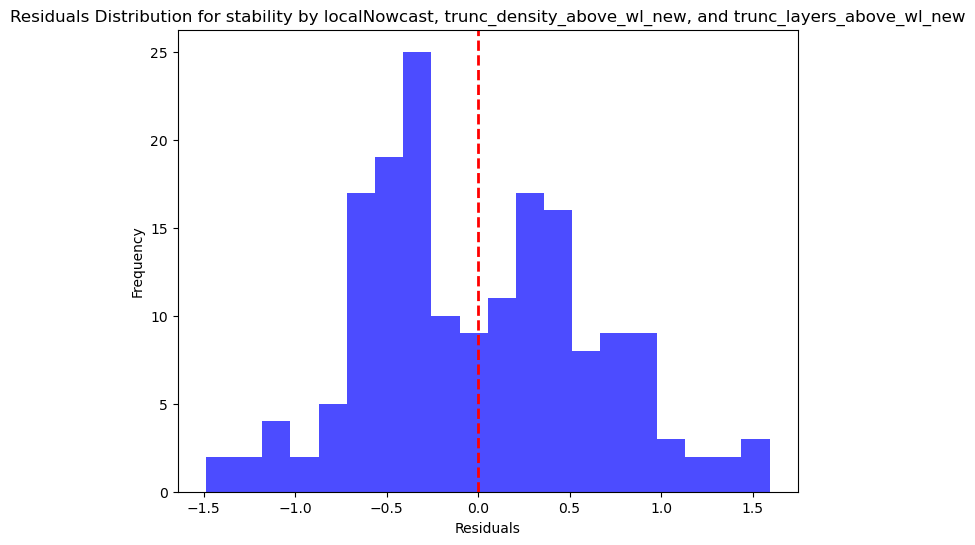

In [140]:
# Define predictor and target variables
predictor_var_localNowcast = "localNowcast"
predictor_var_trunc_density_new = "trunc_density_above_wl_new"
predictor_var_trunc_layers_new = "trunc_layers_above_wl_new"
target_var_stability = "stability"  # New target variable for this model

# Determine maximum length for padding for trunc_density_above_wl_new and trunc_layers_above_wl_new
max_length_trunc_density_new = max(len(lst) for lst in df_weak_layers_exist[predictor_var_trunc_density_new])
max_length_trunc_layers_new = max(len(lst) for lst in df_weak_layers_exist[predictor_var_trunc_layers_new])
max_length = max(max_length_trunc_density_new, max_length_trunc_layers_new)  # Use the longest length for consistent padding

# Prepare the data for the three-input model (localNowcast, trunc_density_above_wl_new, and trunc_layers_above_wl_new with padding)
X_localNowcast = df_weak_layers_exist[predictor_var_localNowcast].values.reshape(-1, 1)
X_trunc_density_new = np.array([lst + [0] * (max_length - len(lst)) for lst in df_weak_layers_exist[predictor_var_trunc_density_new]])
X_trunc_layers_new = np.array([lst + [0] * (max_length - len(lst)) for lst in df_weak_layers_exist[predictor_var_trunc_layers_new]])
y_stability = df_weak_layers_exist[target_var_stability].values

# Combine predictors into a single array
X_combined = np.hstack((X_localNowcast, X_trunc_density_new, X_trunc_layers_new))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_combined, y_stability, test_size=0.3, random_state=36)

# Fit the three-input model
model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)

# Calculate performance metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"Model Performance:\nRMSE: {rmse}\nR^2: {r2}")

# Cross-validated RMSE
cv_rmse = np.mean(np.sqrt(-cross_val_score(model, X_combined, y_stability, scoring='neg_mean_squared_error', cv=10)))
print(f"Cross-validated RMSE for model with {predictor_var_localNowcast}, {predictor_var_trunc_density_new}, and {predictor_var_trunc_layers_new}: {cv_rmse}")

# Plot Predicted vs Actual Values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, c='blue', marker='o', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title(f'Predicted vs Actual {target_var_stability} using {predictor_var_localNowcast}, {predictor_var_trunc_density_new}, and {predictor_var_trunc_layers_new}')
plt.xlabel(f'Actual {target_var_stability}')
plt.ylabel(f'Predicted {target_var_stability}')
plt.legend()
plt.grid(True)

# Annotate RMSE and R^2 on the plot
x_pos = y_test.min() + (7 / 8) * (y_test.max() - y_test.min())
y_pos = y_pred.min() + (1 / 5) * (y_pred.max() - y_pred.min())
plt.text(x_pos, y_pos, f'RMSE: {cv_rmse:.2f}', fontsize=9, color='black')
plt.text(x_pos, y_pos - (y_pred.max() - y_pred.min()) * 0.05, f'R^2: {r2:.2f}', fontsize=9, color='black')

# Save and show the plot for the three-input model
plt.savefig(os.path.join(output_dir_6, f"predicted_vs_actual_{target_var_stability}_by_{predictor_var_localNowcast}_{predictor_var_trunc_density_new}_{predictor_var_trunc_layers_new}.png"))
plt.show()

# Plot Residuals Distribution for three-input model
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=20, alpha=0.7, color='blue')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title(f'Residuals Distribution for {target_var_stability} by {predictor_var_localNowcast}, {predictor_var_trunc_density_new}, and {predictor_var_trunc_layers_new}')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

# Save and show the residuals plot
plt.savefig(os.path.join(output_dir_6, f"residuals_distribution_{target_var_stability}_by_{predictor_var_localNowcast}_{predictor_var_trunc_density_new}_{predictor_var_trunc_layers_new}.png"))
plt.show()

In [ ]:
# By this, we conclude this part of the modelling with the conclusion that using simply localNowcast + trunc_layers + trunc_density as our best model

In [ ]:
# The issue is that this is only slightly better than a naive-predictor, and i would like to compare and see if it is better than a predictor which just draws a random value from 1-7

In [141]:
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from scipy.stats import ttest_rel
import numpy as np

# Define the predictors and target for the best model
X_best_model = np.hstack((X_localNowcast, X_trunc_density_new, X_trunc_layers_new))
y_rb_score = df_weak_layers_exist['RB_score'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_best_model, y_rb_score, test_size=0.3, random_state=36)

# Fit the best model (localNowcast + trunc_density_above_wl_new + trunc_layers_above_wl_new)
model_best = LinearRegression().fit(X_train, y_train)
y_pred_best = model_best.predict(X_test)

# Calculate RMSE for the best model
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
print(f"RMSE of Best Model: {rmse_best}")

# Generate random predictions between 1 and 7 for the test set
np.random.seed(36)  # Ensure reproducibility
y_pred_random = np.random.randint(1, 8, size=len(y_test))

# Calculate RMSE for the random predictor
rmse_random = np.sqrt(mean_squared_error(y_test, y_pred_random))
print(f"RMSE of Random Predictor: {rmse_random}")

# Paired t-test to compare squared errors of best model and random predictor
t_stat, p_value = ttest_rel((y_test - y_pred_best)**2, (y_test - y_pred_random)**2)
print(f"T-test: t-statistic = {t_stat}, p-value = {p_value}")

# Compare results
if p_value < 0.05:
    print("The best model's performance is significantly better than the random predictor (p < 0.05).")
else:
    print("The best model's performance is not significantly better than the random predictor.")

RMSE of Best Model: 1.087601499138717
RMSE of Random Predictor: 2.565707922359274
T-test: t-statistic = -9.700513745791108, p-value = 4.676397204795919e-18
The best model's performance is significantly better than the random predictor (p < 0.05).


In [142]:
# Define the predictors and target for the best model
X_best_model = np.hstack((X_localNowcast, X_trunc_density_new, X_trunc_layers_new))
y_rb_score = df_weak_layers_exist['RB_score'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_best_model, y_rb_score, test_size=0.3, random_state=36)

# Fit the best model (localNowcast + trunc_density_above_wl_new + trunc_layers_above_wl_new)
model_best = LinearRegression().fit(X_train, y_train)
y_pred_best = model_best.predict(X_test)

# Calculate RMSE for the best model
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
print(f"RMSE of Best Model: {rmse_best}")

# Generate random predictions between 1 and 7 for the test set
np.random.seed(36)  # Ensure reproducibility
y_pred_random = np.random.randint(1, 8, size=len(y_test))
rmse_random = np.sqrt(mean_squared_error(y_test, y_pred_random))
print(f"RMSE of Random Predictor: {rmse_random}")

# Mean Predictor
y_pred_mean = np.full_like(y_test, fill_value=np.mean(y_train))
rmse_mean = np.sqrt(mean_squared_error(y_test, y_pred_mean))
print(f"RMSE of Mean Predictor: {rmse_mean}")

# Median Predictor
y_pred_median = np.full_like(y_test, fill_value=np.median(y_train))
rmse_median = np.sqrt(mean_squared_error(y_test, y_pred_median))
print(f"RMSE of Median Predictor: {rmse_median}")

# Paired t-tests to compare the best model with each naive predictor
# Best model vs Random predictor
t_stat_random, p_value_random = ttest_rel((y_test - y_pred_best)**2, (y_test - y_pred_random)**2)
print(f"T-test Best Model vs Random Predictor: t-statistic = {t_stat_random}, p-value = {p_value_random}")

# Best model vs Mean predictor
t_stat_mean, p_value_mean = ttest_rel((y_test - y_pred_best)**2, (y_test - y_pred_mean)**2)
print(f"T-test Best Model vs Mean Predictor: t-statistic = {t_stat_mean}, p-value = {p_value_mean}")

# Best model vs Median predictor
t_stat_median, p_value_median = ttest_rel((y_test - y_pred_best)**2, (y_test - y_pred_median)**2)
print(f"T-test Best Model vs Median Predictor: t-statistic = {t_stat_median}, p-value = {p_value_median}")

# Conclusion based on p-values
if p_value_random < 0.05:
    print("The best model's performance is significantly better than the random predictor (p < 0.05).")
if p_value_mean < 0.05:
    print("The best model's performance is significantly better than the mean predictor (p < 0.05).")
if p_value_median < 0.05:
    print("The best model's performance is significantly better than the median predictor (p < 0.05).")
else:
    print("The best model's performance is not significantly better than the naive predictors.")


RMSE of Best Model: 1.087601499138717
RMSE of Random Predictor: 2.565707922359274
RMSE of Mean Predictor: 1.5137052549054697
RMSE of Median Predictor: 1.52127765851133
T-test Best Model vs Random Predictor: t-statistic = -9.700513745791108, p-value = 4.676397204795919e-18
T-test Best Model vs Mean Predictor: t-statistic = -7.371276353691597, p-value = 6.562518687679145e-12
T-test Best Model vs Median Predictor: t-statistic = -7.417612990497741, p-value = 5.033456336686089e-12
The best model's performance is significantly better than the random predictor (p < 0.05).
The best model's performance is significantly better than the mean predictor (p < 0.05).
The best model's performance is significantly better than the median predictor (p < 0.05).


In [143]:
## We now move into the seventh section, trying with a network approach instead
# Step 1: Create a new folder to save network approach results
output_dir_7 = os.path.join(os.getcwd(), "CN_thesis_plots", "7_network_approaches")
os.makedirs(output_dir_7, exist_ok=True)  # Ensure the directory exists

Epoch 1/50


/Users/carlwn/anaconda3/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2820.8748 - rmse: 52.5434 - val_loss: 107.0382 - val_rmse: 10.3459
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 937.7625 - rmse: 30.5877 - val_loss: 43.3888 - val_rmse: 6.5870
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 397.0339 - rmse: 19.9118 - val_loss: 54.9848 - val_rmse: 7.4152
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 295.1044 - rmse: 17.1556 - val_loss: 48.8106 - val_rmse: 6.9865
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 255.4490 - rmse: 15.9749 - val_loss: 28.1591 - val_rmse: 5.3065
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 163.5788 - rmse: 12.7713 - val_loss: 18.2666 - val_rmse: 4.2739
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 99.8902 - rmse: 9.9810 - val_loss: 12.8981 - val_rmse: 3.5914
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 80.8356 - rmse: 8.9748 - val_loss: 12.2287 - val_rmse: 3.4970
Epoch 9/50
11/11 ━━━━━━━━━━━━━━━━━━━

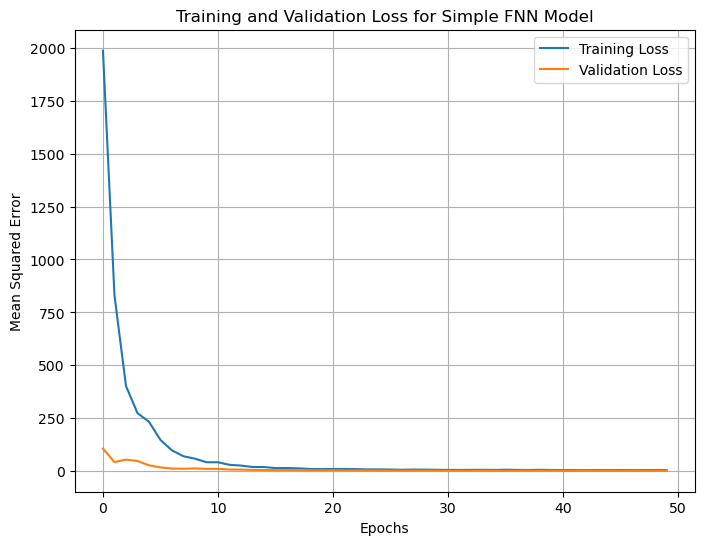

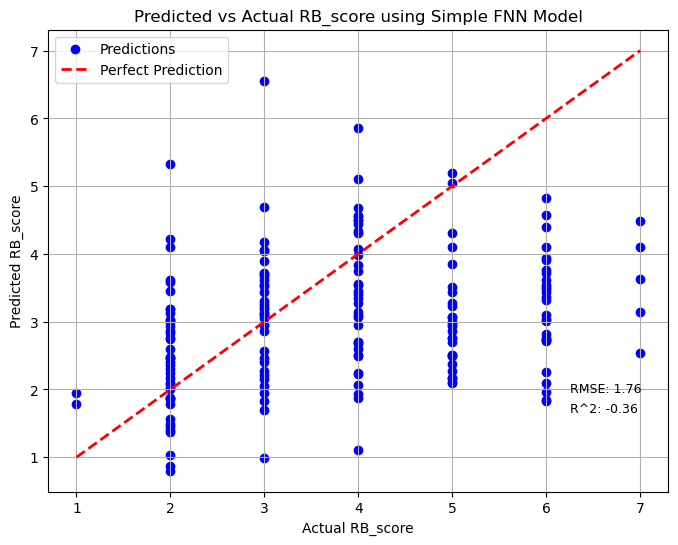

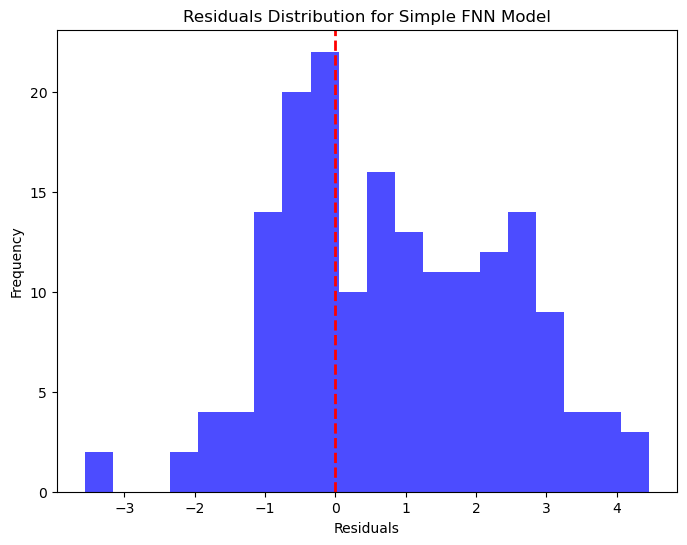

In [150]:
# Step 1: Create a new folder to save network approach results
output_dir_7 = os.path.join(os.getcwd(), "CN_thesis_plots", "7_network_approaches")
os.makedirs(output_dir_7, exist_ok=True)  # Ensure the directory exists

# Step 2: Prepare the data for the Feedforward Neural Network (FNN) model
X_localNowcast = df_weak_layers_exist['localNowcast'].values.reshape(-1, 1)
X_trunc_density = np.array(df_weak_layers_exist['trunc_density_above_wl_new'].tolist())
X_trunc_layers = np.array(df_weak_layers_exist['trunc_layers_above_wl_new'].tolist())

# Determine the maximum sequence length for padding
max_length = max([X_trunc_density.shape[1], X_trunc_layers.shape[1]])

# Pad `trunc_density` and `trunc_layers` to the maximum length
X_trunc_density_padded = pad_sequences(X_trunc_density, maxlen=max_length, padding='post')
X_trunc_layers_padded = pad_sequences(X_trunc_layers, maxlen=max_length, padding='post')

# Flatten `trunc_density` and `trunc_layers` and concatenate with `localNowcast`
X_combined = np.concatenate((X_localNowcast, X_trunc_density_padded, X_trunc_layers_padded), axis=1)
y_rb_score = df_weak_layers_exist['RB_score'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_combined, y_rb_score, test_size=0.3, random_state=36)

# Step 3: Define the simplest Feedforward Neural Network (FNN) model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_combined.shape[1],)),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1)  # Output layer for regression
])

# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=[tf.keras.metrics.RootMeanSquaredError(name='rmse')])

# Step 4: Train the model and save the training history
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

# Step 5: Evaluate the model on the test set
y_pred = model.predict(X_test).flatten()  # Flatten to ensure consistent shape
rmse_fnn = np.sqrt(mean_squared_error(y_test, y_pred))
r2_fnn = r2_score(y_test, y_pred)
print(f"RMSE of Simple Feedforward Neural Network Model: {rmse_fnn}")
print(f"R^2 of Simple Feedforward Neural Network Model: {r2_fnn}")

# Step 6: Plot and save the training and validation loss graph
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss for Simple FNN Model')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)

# Save the loss plot
loss_plot_path = os.path.join(output_dir_7, "training_validation_loss_simple_FNN_model.png")
plt.savefig(loss_plot_path)
plt.show()

# Step 7: Plot and save Predicted vs Actual RB_score values with RMSE and R2 annotations
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, c='blue', marker='o', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title('Predicted vs Actual RB_score using Simple FNN Model')
plt.xlabel('Actual RB_score')
plt.ylabel('Predicted RB_score')
plt.legend()
plt.grid(True)

# Annotate RMSE and R2 on the plot
x_pos = y_test.min() + (7 / 8) * (y_test.max() - y_test.min())
y_pos = y_pred.min() + (1 / 5) * (y_pred.max() - y_pred.min())
plt.text(x_pos, y_pos, f'RMSE: {rmse_fnn:.2f}', fontsize=9, color='black')
plt.text(x_pos, y_pos - (y_pred.max() - y_pred.min()) * 0.05, f'R^2: {r2_fnn:.2f}', fontsize=9, color='black')

# Save the Predicted vs Actual plot
pred_vs_actual_path = os.path.join(output_dir_7, "predicted_vs_actual_RB_score_simple_FNN_model.png")
plt.savefig(pred_vs_actual_path)
plt.show()

# Step 8: Plot and save Residual Distribution
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=20, alpha=0.7, color='blue')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title('Residuals Distribution for Simple FNN Model')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

# Save the residuals distribution plot
residuals_path = os.path.join(output_dir_7, "residuals_distribution_simple_FNN_model.png")
plt.savefig(residuals_path)
plt.show()

In [ ]:
# Poor performance, try with a network which captures interdependence better

X_train_layers shape (should be [samples, max_length, 2]): (406, 6, 2)
X_train_localNowcast shape (should be [samples, 1]): (406, 1)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layers        │ (None, 6, 2)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 6, 64)     │        448 │ input_layers[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 3, 64)     │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 3, 128)    │     16,512 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     49,408 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_localNowcast  │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 65)        │          0 │ lstm[0][0],       │
│ (Concatenate)       │                   │            │ input_localNowca… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      4,224 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 70,657 (276.00 KB)

 Trainable params: 70,657 (276.00 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/50


/Users/carlwn/anaconda3/lib/python3.11/site-packages/keras/src/models/functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['input_layers', 'input_localNowcast']. Received: the structure of inputs={'input_layers': '*', 'input_localNowcast': '*'}
  warnings.warn(


11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 12.3674 - rmse: 3.4900 - val_loss: 1.9571 - val_rmse: 1.3990
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.2174 - rmse: 1.7926 - val_loss: 1.7860 - val_rmse: 1.3364
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.7004 - rmse: 1.6432 - val_loss: 1.6402 - val_rmse: 1.2807
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.7430 - rmse: 1.6547 - val_loss: 1.5753 - val_rmse: 1.2551
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.6461 - rmse: 1.6248 - val_loss: 1.5461 - val_rmse: 1.2434
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.7566 - rmse: 1.6567 - val_loss: 1.5232 - val_rmse: 1.2342
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.3046 - rmse: 1.5168 - val_loss: 1.5283 - val_rmse: 1.2362
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.1834 - rmse: 1.4751 - val_loss: 1.4826 - val_rmse: 1.2176
Epoch 9/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.2186 

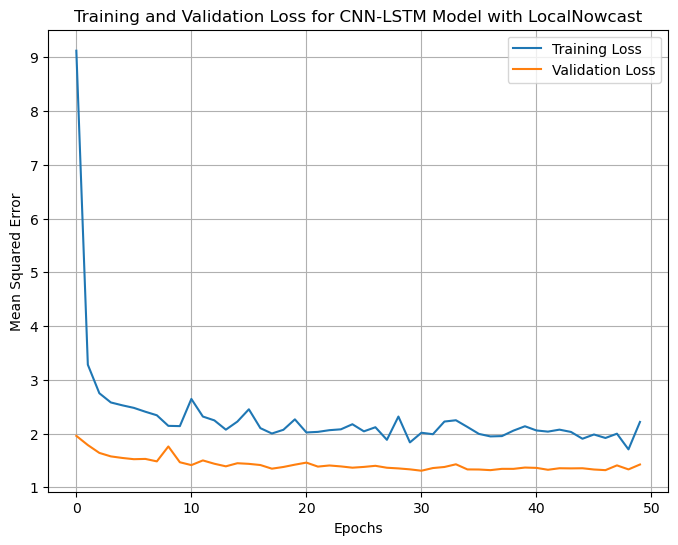

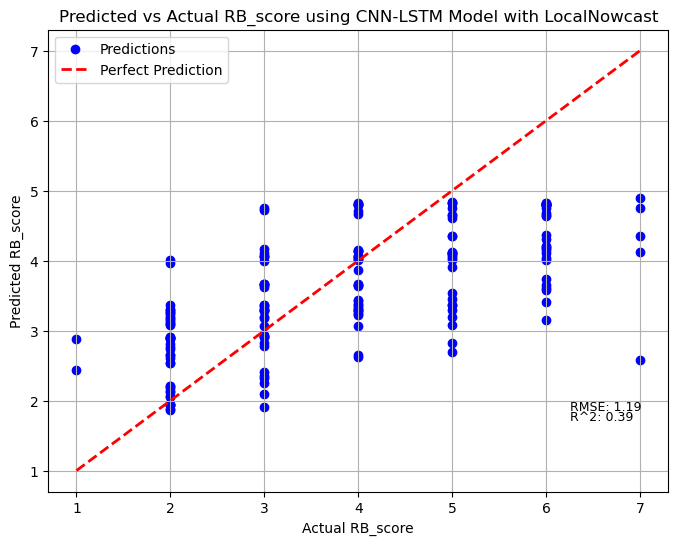

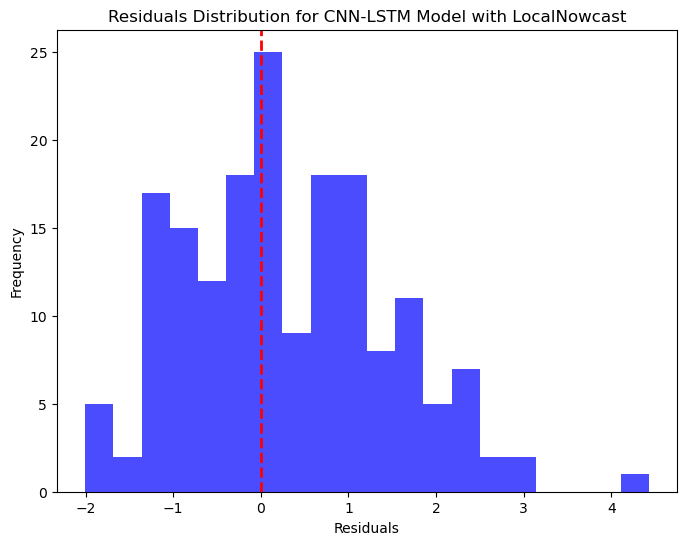

In [166]:
# Import necessary libraries
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Concatenate
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Clear previous models and sessions
tf.keras.backend.clear_session()

# Step 1: Create a new folder to save network approach results
output_dir_7 = os.path.join(os.getcwd(), "CN_thesis_plots", "7_network_approaches")
os.makedirs(output_dir_7, exist_ok=True)  # Ensure the directory exists

# Step 2: Prepare the data
X_localNowcast = df_weak_layers_exist['localNowcast'].values.reshape(-1, 1)
X_trunc_density = np.array(df_weak_layers_exist['trunc_density_above_wl_new'].tolist())
X_trunc_layers = np.array(df_weak_layers_exist['trunc_layers_above_wl_new'].tolist())

# Determine the maximum sequence length for padding
max_length = max([X_trunc_density.shape[1], X_trunc_layers.shape[1]])

# Pad `trunc_density` and `trunc_layers` to the maximum length
X_trunc_density_padded = pad_sequences(X_trunc_density, maxlen=max_length, padding='post')
X_trunc_layers_padded = pad_sequences(X_trunc_layers, maxlen=max_length, padding='post')

# Stack `trunc_density` and `trunc_layers` to create a 2-channel input
X_combined_layers = np.stack((X_trunc_density_padded, X_trunc_layers_padded), axis=-1)
y_rb_score = df_weak_layers_exist['RB_score'].values

# Train-test split
X_train_layers, X_test_layers, X_train_localNowcast, X_test_localNowcast, y_train, y_test = train_test_split(
    X_combined_layers, X_localNowcast, y_rb_score, test_size=0.3, random_state=36
)

# Debugging: Print shapes before passing to model
print("X_train_layers shape (should be [samples, max_length, 2]):", X_train_layers.shape)
print("X_train_localNowcast shape (should be [samples, 1]):", X_train_localNowcast.shape)

# Step 3: Define the CNN-LSTM model with padding and reduced kernel size

# Input for layered data (trunc_density and trunc_layers)
input_layers = Input(shape=(max_length, 2), name="input_layers")

# CNN-LSTM pipeline for structural data
x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(input_layers)
x = MaxPooling1D(pool_size=2)(x)
x = Conv1D(filters=128, kernel_size=2, activation='relu', padding='same')(x)  # Reduced kernel size to 2
x = LSTM(64)(x)

# Input for localNowcast
input_localNowcast = Input(shape=(1,), name="input_localNowcast")
combined = Concatenate()([x, input_localNowcast])

# Fully connected layers for regression
combined = Dense(64, activation='relu')(combined)
combined = Dropout(0.5)(combined)
output = Dense(1)(combined)  # Final output layer for regression

# Define and compile the model
model = Model(inputs=[input_layers, input_localNowcast], outputs=output)
model.compile(optimizer='adam', loss='mse', metrics=[tf.keras.metrics.RootMeanSquaredError(name='rmse')])

# Debugging: Check model summary
print(model.summary())

# Step 4: Train the model and save the training history
# Use dictionary to pass named inputs
history = model.fit({"input_layers": X_train_layers, "input_localNowcast": X_train_localNowcast},
                    y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

# Step 5: Evaluate the model on the test set
y_pred = model.predict({"input_layers": X_test_layers, "input_localNowcast": X_test_localNowcast}).flatten()
rmse_cnn_lstm = np.sqrt(mean_squared_error(y_test, y_pred))
r2_cnn_lstm = r2_score(y_test, y_pred)
print(f"RMSE of CNN-LSTM Model with LocalNowcast: {rmse_cnn_lstm}")
print(f"R^2 of CNN-LSTM Model with LocalNowcast: {r2_cnn_lstm}")

# The rest of the code for plotting and saving results remains unchanged.
# Step 6: Plot and save the training and validation loss graph
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss for CNN-LSTM Model with LocalNowcast')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)

# Save the loss plot
loss_plot_path = os.path.join(output_dir_7, "training_validation_loss_CNN_LSTM_with_localNowcast.png")
plt.savefig(loss_plot_path)
plt.show()

# Step 7: Plot and save Predicted vs Actual RB_score values with RMSE and R^2 annotations
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, c='blue', marker='o', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title('Predicted vs Actual RB_score using CNN-LSTM Model with LocalNowcast')
plt.xlabel('Actual RB_score')
plt.ylabel('Predicted RB_score')
plt.legend()
plt.grid(True)

# Annotate RMSE and R^2 on the plot
x_pos = y_test.min() + (7 / 8) * (y_test.max() - y_test.min())
y_pos = y_pred.min() + 0 * (y_pred.max() - y_pred.min())
plt.text(x_pos, y_pos, f'RMSE: {rmse_cnn_lstm:.2f}', fontsize=9, color='black')
plt.text(x_pos, y_pos - (y_pred.max() - y_pred.min()) * 0.05, f'R^2: {r2_cnn_lstm:.2f}', fontsize=9, color='black')

# Save the Predicted vs Actual plot
pred_vs_actual_path = os.path.join(output_dir_7, "predicted_vs_actual_RB_score_CNN_LSTM_with_localNowcast.png")
plt.savefig(pred_vs_actual_path)
plt.show()

# Step 8: Plot and save Residual Distribution
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=20, alpha=0.7, color='blue')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title('Residuals Distribution for CNN-LSTM Model with LocalNowcast')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

# Save the residuals distribution plot
residuals_path = os.path.join(output_dir_7, "residuals_distribution_CNN_LSTM_with_localNowcast.png")
plt.savefig(residuals_path)
plt.show()


Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 50}
Root Mean Squared Error: 1.142556890736132
R^2 Score: 0.4354083578195853


/Users/carlwn/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:425: FitFailedWarning: 
540 fits failed out of a total of 1620.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
317 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/carlwn/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 732, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/carlwn/anaconda3/lib/python3.11/site-packages/sklearn/base.py", line 1144, in wrapper
    estimator._validate_params()
  File "/Users/carlwn/anaconda3/lib/python3.11/site-packages/sklearn/base.py", line 637, in _validate_params
    validate_parameter_constraints(
  File 

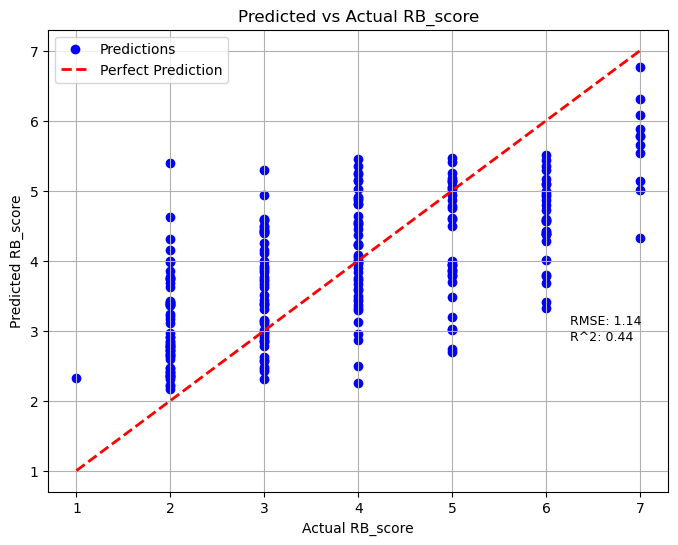

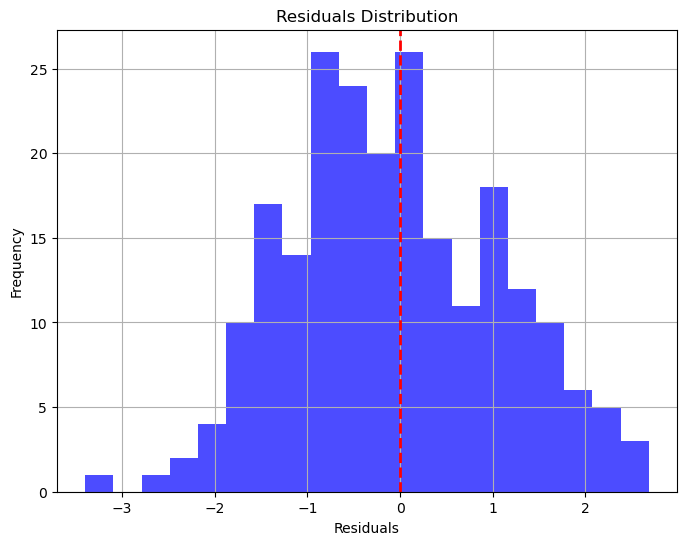

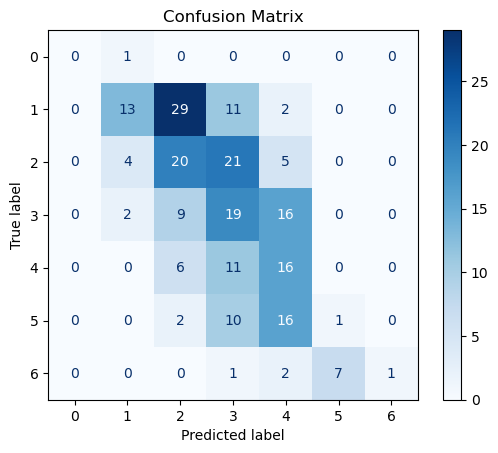

In [179]:
# Prepare the data
# Define the truncate length (adjust based on your data processing)
truncate = 10  # Modify if necessary to match your data's layer length

# Extract features
X_layers = np.array(df_raw['trunc_layers_above_wl'].tolist())
X_density = np.array(df_raw['trunc_density_above_wl'].tolist())
slope_angle = df_raw['slopeangle'].values  # Slope angle for each observation
local_nowcast = df_raw['localNowcast'].values  # Local nowcast data for each observation
y = df_raw['RB_score'].values  # Target variable

# Combine features into one array (stack horizontally)
X = np.column_stack((X_layers, X_density, slope_angle, local_nowcast))  # Each row includes trunc_layers, trunc_density, slope_angle, local_nowcast

# Split data into training and testing sets (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: Hyperparameter Tuning using GridSearchCV
# Define the hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

# Instantiate the model
rf_model = RandomForestRegressor(random_state=42)

# Set up GridSearchCV
grid_search = GridSearchCV(rf_model, param_grid, cv=5, n_jobs=-1, scoring='neg_mean_squared_error')

# Fit GridSearchCV
grid_search.fit(X_train, y_train)

# Get the best model
best_model = grid_search.best_estimator_
print(f'Best Parameters: {grid_search.best_params_}')

# Step 4: Predict on Test Data using the best model
y_pred = best_model.predict(X_test)

# Step 5: Evaluate the Model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f'Root Mean Squared Error: {rmse}')
print(f'R^2 Score: {r2}')

# Step 6: Plot Predicted vs Actual Values with RMSE and R^2 annotations
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, c='blue', marker='o', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')  # Diagonal line for perfect prediction
plt.title('Predicted vs Actual RB_score')
plt.xlabel('Actual RB_score')
plt.ylabel('Predicted RB_score')
plt.legend()
plt.grid(True)

# Annotate RMSE and R^2 on the plot
x_pos = y_test.min() + (7 / 8) * (y_test.max() - y_test.min())
y_pos = y_pred.min() + (1 / 5) * (y_pred.max() - y_pred.min())
plt.text(x_pos, y_pos, f'RMSE: {rmse:.2f}', fontsize=9, color='black')
plt.text(x_pos, y_pos - (y_pred.max() - y_pred.min()) * 0.05, f'R^2: {r2:.2f}', fontsize=9, color='black')

plt.show()

# Step 7: Residual Plot
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=20, alpha=0.7, color='blue')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title('Residuals Distribution')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Step 8: Confusion Matrix (For Binary Classification)
# Convert predictions to nearest integer for a binary classification view
y_pred_binary = np.round(y_pred).astype(int)  # Round predictions to the nearest integer
y_test_binary = np.round(y_test).astype(int)  # Round actual values to the nearest integer

# Calculate the confusion matrix
cm = confusion_matrix(y_test_binary, y_pred_binary)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# This does not work too well, we should try to use gradient booster next

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 50}
Root Mean Squared Error: 1.1248971832618035
R^2 Score: 0.45272647930796106


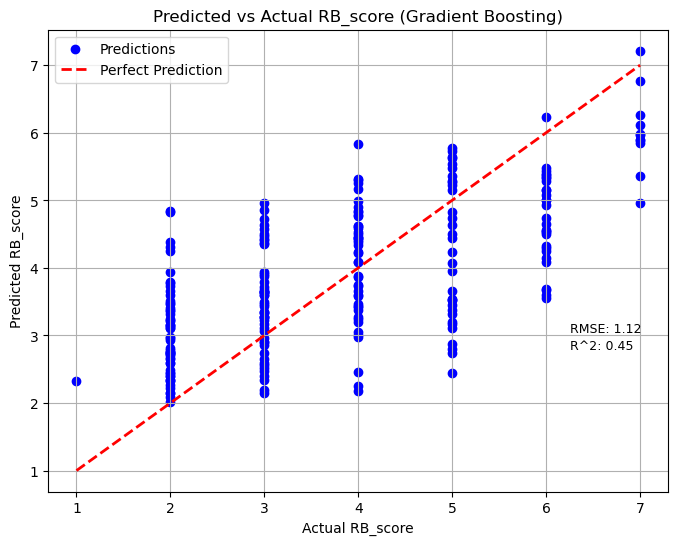

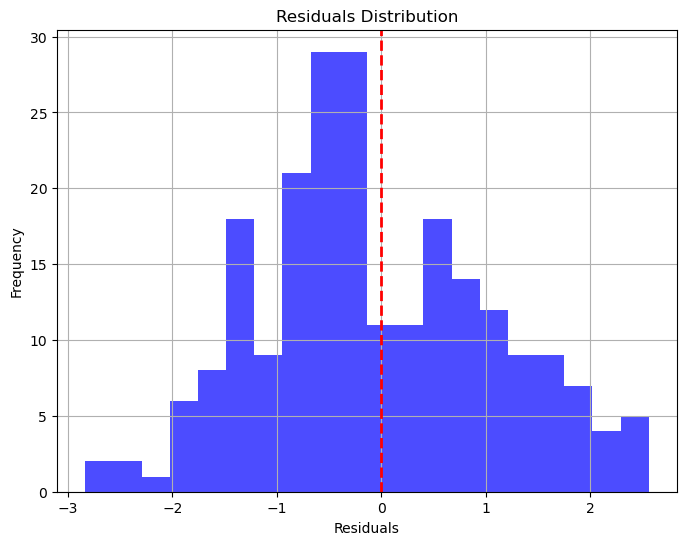

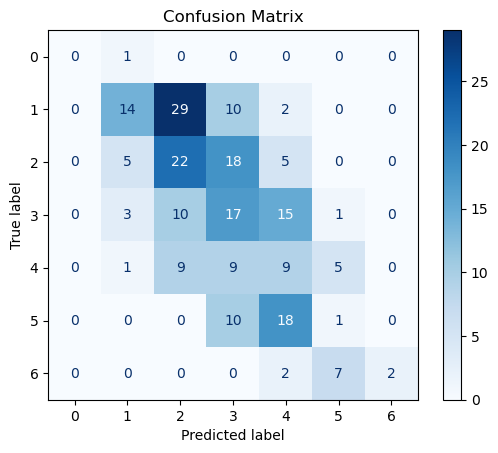

In [181]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Prepare the data
# Define the truncate length (adjust based on your data processing)
truncate = 10  # Modify if necessary to match your data's layer length

# Extract features
X_layers = np.array(df_raw['trunc_layers_above_wl'].tolist())
X_density = np.array(df_raw['trunc_density_above_wl'].tolist())
local_nowcast = df_raw['localNowcast'].values  # Local nowcast data for each observation
y = df_raw['RB_score'].values  # Target variable

# Combine features into one array (stack horizontally)
X = np.column_stack((X_layers, X_density, local_nowcast))  # Each row includes trunc_layers, trunc_density, slope_angle, local_nowcast

# Split data into training and testing sets (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: Hyperparameter Tuning using GridSearchCV for Gradient Boosting
# Define the hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Instantiate the model
gb_model = GradientBoostingRegressor(random_state=42)

# Set up GridSearchCV
grid_search = GridSearchCV(gb_model, param_grid, cv=5, n_jobs=-1, scoring='neg_mean_squared_error')

# Fit GridSearchCV
grid_search.fit(X_train, y_train)

# Get the best model
best_model = grid_search.best_estimator_
print(f'Best Parameters: {grid_search.best_params_}')

# Step 4: Predict on Test Data using the best model
y_pred = best_model.predict(X_test)

# Step 5: Evaluate the Model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f'Root Mean Squared Error: {rmse}')
print(f'R^2 Score: {r2}')

# Step 6: Plot Predicted vs Actual Values with RMSE and R^2 annotations
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, c='blue', marker='o', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')  # Diagonal line for perfect prediction
plt.title('Predicted vs Actual RB_score (Gradient Boosting)')
plt.xlabel('Actual RB_score')
plt.ylabel('Predicted RB_score')
plt.legend()
plt.grid(True)

# Annotate RMSE and R^2 on the plot
x_pos = y_test.min() + (7 / 8) * (y_test.max() - y_test.min())
y_pos = y_pred.min() + (1 / 5) * (y_pred.max() - y_pred.min())
plt.text(x_pos, y_pos, f'RMSE: {rmse:.2f}', fontsize=9, color='black')
plt.text(x_pos, y_pos - (y_pred.max() - y_pred.min()) * 0.05, f'R^2: {r2:.2f}', fontsize=9, color='black')

plt.show()

# Step 7: Residual Plot
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=20, alpha=0.7, color='blue')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title('Residuals Distribution')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Step 8: Confusion Matrix (For Binary Classification)
# Convert predictions to nearest integer for a binary classification view
y_pred_binary = np.round(y_pred).astype(int)  # Round predictions to the nearest integer
y_test_binary = np.round(y_test).astype(int)  # Round actual values to the nearest integer

# Calculate the confusion matrix
cm = confusion_matrix(y_test_binary, y_pred_binary)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()